# AI Driven Export Market Decision Support System

## QM 640 Capstone Project

### Student
Pavithra Bharathi

### Walsh University

---

## Project Objective

This project aims to develop an AI-driven export market decision support system to identify high-potential international markets for Indian exports. The study integrates TradeStat, UN Comtrade, and World Bank datasets to analyze historical trade performance, evaluate macroeconomic indicators, and generate data-driven recommendations for exporters.

---

## Research Questions

RQ1.
Which export commodities and international markets exhibit the highest growth potential for India?

RQ2.
Which macroeconomic indicators significantly influence India's export performance?

RQ3.
How does international competition affect India's export opportunities across selected commodities?

RQ4.
Can machine learning models accurately identify attractive export markets?

---

## Data Sources

1. TradeStat (Government of India)

2. UN Comtrade

3. World Bank World Development Indicators

---

## Expected Outputs

• Clean integrated dataset

• Exploratory Data Analysis

• Statistical Analysis

• Machine Learning Models

• Export Market Recommendation Framework

Environment Setup

In [1]:
# =====================================
# INSTALL REQUIRED PACKAGES
# =====================================

!pip install openpyxl
!pip install xlrd
!pip install seaborn
!pip install statsmodels
!pip install xgboost
!pip install missingno

Clone Repository

In [2]:
# =====================================
# CLONE GITHUB REPOSITORY
# =====================================

!git clone https://github.com/bharathipavithra10-cmd/AI-Export-Market-Decision-Support.git

Cloning into 'AI-Export-Market-Decision-Support'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (245/245), done.
remote: Compressing objects: 100% (226/226), done.
remote: Total 245 (delta 95), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (245/245), 16.79 MiB | 8.16 MiB/s, done.
Resolving deltas: 100% (95/95), done.


In [3]:
# =====================================
# IMPORT LIBRARIES
# =====================================

import os
import re
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

Project Directory

In [4]:
PROJECT_ROOT = Path("/content/AI-Export-Market-Decision-Support")

RAW_DATA = PROJECT_ROOT/"data"/"raw"

TRADESTAT_DIR = RAW_DATA/"tradestate"

UNCOMTRADE_DIR = RAW_DATA/"un_comtrade"

WORLD_BANK_DIR = RAW_DATA/"WORLD_BANK"

OUTPUT_DIR = PROJECT_ROOT/"outputs"

FIGURES_DIR = OUTPUT_DIR/"figures"

TABLES_DIR = OUTPUT_DIR/"tables"

CLEAN_DIR = PROJECT_ROOT/"data"/"cleaned"

PROCESSED_DIR = PROJECT_ROOT/"data"/"processed"

Create Output Folders

In [5]:
for folder in [

    OUTPUT_DIR,

    FIGURES_DIR,

    TABLES_DIR,

    CLEAN_DIR,

    PROCESSED_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Folders Created Successfully")

Folders Created Successfully


Verify Dataset

In [6]:
print("="*50)
print("TRADESTAT FILES")
print("="*50)

trade_files = sorted(
    TRADESTAT_DIR.rglob("*.xlsx")
)

print(len(trade_files))

for f in trade_files:

    print(f.name)

TRADESTAT FILES
29
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2023.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2023_2024.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2024_2025.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2025-2026.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2023.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2023_2024.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2024_2025.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2025_2026.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2

Verify UN Comtrade

In [7]:
print("="*50)
print("UN COMTRADE")
print("="*50)

comtrade_files = sorted(
    UNCOMTRADE_DIR.glob("*.xlsx")
)

for f in comtrade_files:

    print(f.name)

UN COMTRADE
TradeData_7_21_2026_1_4_20.xlsx


In [107]:
# ==============================================================================
# INSPECT ORIGINAL UN COMTRADE FILES
# ==============================================================================
# Purpose:
# Inspect the raw UN Comtrade Excel files before any filtering or transformation.
# This helps identify the fields required for RQ3:
# Reporter/Destination, Partner/Supplier, Trade Flow, Commodity,
# Year and Trade Value.
# ==============================================================================

print("Number of UN Comtrade files:", len(comtrade_files))

if len(comtrade_files) > 0:

    # Read the first available Comtrade file
    comtrade_raw = pd.read_excel(comtrade_files[0])

    print("\nFile inspected:")
    print(comtrade_files[0].name)

    print("\nRaw Comtrade shape:")
    print(comtrade_raw.shape)

    print("\nRaw Comtrade columns:")
    print(comtrade_raw.columns.tolist())

    print("\nFirst 5 rows:")
    display(comtrade_raw.head())

else:
    print("No UN Comtrade Excel files found.")

Number of UN Comtrade files: 1

File inspected:
TradeData_7_21_2026_1_4_20.xlsx

Raw Comtrade shape:
(100000, 47)

Raw Comtrade columns:
['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']

First 5 rows:


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,1146.40,640.00,1146.40,0,False,True
1,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,572806.98,555763.48,572806.98,0,False,True
2,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,63.00,20.00,63.00,0,False,True
3,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,886.95,850.01,886.95,0,False,True
4,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,66.03,50.00,66.03,0,False,True


In [108]:
# ==============================================================================
# RESEARCH QUESTION 3 - COMTRADE COVERAGE DIAGNOSTIC
#
# RQ3:
# How do supplier competition and India's market share influence export
# opportunities across international markets?
#
# Purpose:
# Before constructing India's market share, supplier count, and HHI,
# inspect the coverage of the raw UN Comtrade dataset.
#
# For RQ3:
#   Reporter = destination/importing market
#   Partner  = supplier/exporting country
#   Flow     = imports into the destination
#   Commodity = HS product category
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. DATASET SIZE
# ------------------------------------------------------------------------------

print("Raw Comtrade shape:", comtrade_raw.shape)


# ------------------------------------------------------------------------------
# 2. YEAR COVERAGE
# ------------------------------------------------------------------------------

print("\nYear coverage:")
print(
    sorted(
        comtrade_raw["refYear"]
        .dropna()
        .unique()
    )
)


# ------------------------------------------------------------------------------
# 3. TRADE FLOW
# ------------------------------------------------------------------------------

print("\nTrade flow distribution:")
print(
    comtrade_raw["flowDesc"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------------------------
# 4. REPORTER / DESTINATION MARKETS
# ------------------------------------------------------------------------------

print("\nNumber of reporter markets:")
print(
    comtrade_raw["reporterDesc"]
    .nunique()
)

print("\nReporter markets:")
print(
    comtrade_raw["reporterDesc"]
    .value_counts()
    .head(30)
)


# ------------------------------------------------------------------------------
# 5. PARTNER / SUPPLIER COUNTRIES
# ------------------------------------------------------------------------------

print("\nNumber of supplier/partner values:")
print(
    comtrade_raw["partnerDesc"]
    .nunique()
)

print("\nMost common supplier/partner values:")
print(
    comtrade_raw["partnerDesc"]
    .value_counts()
    .head(30)
)


# ------------------------------------------------------------------------------
# 6. CHECK WHETHER INDIA EXISTS AS A SUPPLIER
# ------------------------------------------------------------------------------

india_rows = comtrade_raw[
    comtrade_raw["partnerDesc"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("india")
]

print("\nRows where India is the supplier:")
print(len(india_rows))

if len(india_rows) > 0:

    print("\nSample India supplier records:")

    display(
        india_rows[
            [
                "refYear",
                "reporterDesc",
                "partnerDesc",
                "flowDesc",
                "cmdCode",
                "cmdDesc",
                "primaryValue"
            ]
        ].head(10)
    )


# ------------------------------------------------------------------------------
# 7. COMMODITY COVERAGE
# ------------------------------------------------------------------------------

print("\nNumber of commodity codes:")
print(
    comtrade_raw["cmdCode"]
    .nunique()
)

print("\nMost common commodity codes:")
print(
    comtrade_raw["cmdCode"]
    .astype(str)
    .value_counts()
    .head(30)
)


# ------------------------------------------------------------------------------
# 8. CHECK OUR FIVE TARGET HS CHAPTERS
# ------------------------------------------------------------------------------

target_hs = ["27", "30", "71", "84", "85"]

cmd_string = (
    comtrade_raw["cmdCode"]
    .astype(str)
    .str.strip()
)

print("\nRows for target HS chapters:")

for hs in target_hs:

    count = cmd_string.str.startswith(hs).sum()

    print(
        f"HS {hs}: {count:,} rows"
    )

Raw Comtrade shape: (100000, 47)

Year coverage:
[np.int64(2020)]

Trade flow distribution:
flowDesc
Import    100000
Name: count, dtype: int64

Number of reporter markets:
64

Reporter markets:
reporterDesc
France                11547
Germany                8809
Canada                 8793
Czechia                8299
Colombia               5288
Finland                5217
Argentina              4841
Estonia                4451
Bosnia Herzegovina     4400
Ecuador                4006
Dominican Rep.         3891
Belarus                3637
Albania                3500
Cyprus                 2955
Azerbaijan             2699
Armenia                1082
Belgium                 761
China                   707
Austria                 669
Australia               633
Denmark                 570
Brazil                  551
Chile                   495
Costa Rica              471
Sri Lanka               460
Greece                  453
Angola                  446
El Salvador             437
Bahrain 

,refYear,reporterDesc,partnerDesc,flowDesc,cmdCode,cmdDesc,primaryValue
159,2020,Angola,India,Import,71,"Natural, cultured pearls; precious, semi-preci...",1.426950e+03
376,2020,Angola,India,Import,85,Electrical machinery and equipment and parts t...,1.788049e+07
393,2020,Angola,India,Import,84,"Nuclear reactors, boilers, machinery and mecha...",3.357727e+07
399,2020,Angola,India,Import,30,Pharmaceutical products,1.096802e+08
439,2020,Angola,India,Import,27,"Mineral fuels, mineral oils and products of th...",9.587902e+07
501,2020,Belize,India,Import,27,"Mineral fuels, mineral oils and products of th...",5.326340e+03
531,2020,Belize,India,Import,85,Electrical machinery and equipment and parts t...,6.575400e+02
583,2020,Belize,India,Import,30,Pharmaceutical products,1.211615e+06
607,2020,Belize,India,Import,84,"Nuclear reactors, boilers, machinery and mecha...",1.772861e+05
676,2020,Bolivia (Plurinational State of),India,Import,84,"Nuclear reactors, boilers, machinery and mecha...",7.296287e+06



Number of commodity codes:
5

Most common commodity codes:
cmdCode
85    35758
84    35432
30    12334
71     8615
27     7861
Name: count, dtype: int64

Rows for target HS chapters:
HS 27: 7,861 rows
HS 30: 12,334 rows
HS 71: 8,615 rows
HS 84: 35,432 rows
HS 85: 35,758 rows


Verify World Bank

In [8]:
print("="*50)
print("WORLD BANK")
print("="*50)

wb_files = sorted(
    WORLD_BANK_DIR.glob("*.xlsx")
)

for f in wb_files:

    print(f.name)

WORLD BANK
P_Data_Extract_From_World_Development_Indicators.xlsx


Dataset Summary

In [9]:
summary = pd.DataFrame({

    "Dataset":[

        "TradeStat",

        "UN Comtrade",

        "World Bank"

    ],

    "Files":[

        len(trade_files),

        len(comtrade_files),

        len(wb_files)

    ]

})

summary

,Dataset,Files
0,TradeStat,29
1,UN Comtrade,1
2,World Bank,1


Data Quality Assessment

In [10]:
print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print(f"TradeStat Files : {len(trade_files)}")

print(f"UN Comtrade Files : {len(comtrade_files)}")

print(f"World Bank Files : {len(wb_files)}")

PROJECT SUMMARY
TradeStat Files : 29
UN Comtrade Files : 1
World Bank Files : 1


Notebook Progress

In [11]:
progress = pd.DataFrame({

    "Task":[

        "Repository",

        "Data Loading",

        "Data Cleaning",

        "Data Integration",

        "Feature Engineering",

        "EDA",

        "Regression",

        "Machine Learning"

    ],

    "Status":[

        "Completed",

        "Completed",

        "In Progress",

        "Pending",

        "Pending",

        "Pending",

        "Pending",

        "Pending"

    ]

})

progress

,Task,Status
0,Repository,Completed
1,Data Loading,Completed
2,Data Cleaning,In Progress
3,Data Integration,Pending
4,Feature Engineering,Pending
5,EDA,Pending
6,Regression,Pending
7,Machine Learning,Pending


PART 2 – Data Cleaning & Integration

In [12]:
# ==========================================
# LOAD ALL TRADESTAT FILES
# ==========================================

trade_files = sorted(TRADESTAT_DIR.rglob("*.xlsx"))

print(f"Total files found : {len(trade_files)}")

Total files found : 29


TradeStat Loader

In [13]:
def load_tradestat(file_path):

    df = pd.read_excel(
        file_path,
        skiprows=2
    )

    df.columns = [
        "Serial_No",
        "Country",
        "Export_Previous",
        "Export_Current",
        "Export_Growth",
        "Quantity_Previous",
        "Quantity_Current",
        "Quantity_Growth"
    ]

    df = df.dropna(how="all")

    df = df[
        ~df["Country"]
        .astype(str)
        .str.contains("Total",case=False)
    ]

    commodity = file_path.parent.name.replace(
        "commodity_",""
    )

    year = re.findall(
        r"(20\d{2})[_-](20\d{2})",
        file_path.name
    )[0][1]

    df["Commodity"]=commodity
    df["Year"]=int(year)

    return df

Read Everything

In [14]:
trade_frames=[]

for file in trade_files:

    try:

        trade_frames.append(
            load_tradestat(file)
        )

    except Exception as e:

        print(file)

        print(e)

Combine

In [15]:
from pathlib import Path

PROJECT_ROOT = Path("/content/AI-Export-Market-Decision-Support")

print(PROJECT_ROOT.exists())

True


In [16]:

import os

for root, dirs, files in os.walk("/content/AI-Export-Market-Decision-Support"):
    print(root)

/content/AI-Export-Market-Decision-Support
/content/AI-Export-Market-Decision-Support/data
/content/AI-Export-Market-Decision-Support/data/cleaned
/content/AI-Export-Market-Decision-Support/data/processed
/content/AI-Export-Market-Decision-Support/data/sample
/content/AI-Export-Market-Decision-Support/data/raw
/content/AI-Export-Market-Decision-Support/data/raw/tradestate
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_71
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_84
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_85
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_27
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_30
/content/AI-Export-Market-Decision-Support/data/raw/WORLD_BANK
/content/AI-Export-Market-Decision-Support/data/raw/un_comtrade
/content/AI-Export-Market-Decision-Support/outputs
/content/AI-Export-Market-Decision-Support/outputs/tables
/content/

In [17]:
import os

print(os.listdir("/content/AI-Export-Market-Decision-Support/data/raw"))

['tradestate', 'rreadme.md', 'readme.md', 'WORLD_BANK', 'un_comtrade']


In [18]:
tradestat=pd.concat(
    trade_frames,
    ignore_index=True
)

print(tradestat.shape)

tradestat.head()

(6040, 10)


,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year
0,1,AFGHANISTAN,0.31,0.84,167.87,NaN,NaN,NaN,27,2021
1,2,ALBANIA,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021
2,3,ALGERIA,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021
3,4,ANGOLA,0.24,0.87,270.22,NaN,NaN,NaN,27,2021
4,5,ARGENTINA,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021


Numeric Conversion

In [19]:
numeric_columns=[

"Export_Previous",

"Export_Current",

"Export_Growth",

"Quantity_Previous",

"Quantity_Current",

"Quantity_Growth"

]

for col in numeric_columns:

    tradestat[col]=(

        tradestat[col]

        .astype(str)

        .str.replace(",","")

        .str.strip()

    )

    tradestat[col]=pd.to_numeric(

        tradestat[col],

        errors="coerce"

    )

Missing Values

In [20]:
missing=tradestat.isnull().sum()

missing=missing.reset_index()

missing.columns=[

"Variable",

"Missing Values"

]

missing

,Variable,Missing Values
0,Serial_No,0
1,Country,0
2,Export_Previous,239
3,Export_Current,234
4,Export_Growth,473
5,Quantity_Previous,6040
6,Quantity_Current,6040
7,Quantity_Growth,6040
8,Commodity,0
9,Year,0


Duplicate Rows

In [21]:
duplicates=tradestat.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


Save Clean TradeStat

In [22]:
tradestat.to_csv(

    CLEAN_DIR/"tradestat_clean.csv",

    index=False

)

Load UN Comtrade

In [23]:
# ==========================================
# LOAD UN COMTRADE (XLSX)
# ==========================================

comtrade_file = list(UNCOMTRADE_DIR.glob("*.xlsx"))[0]

print("Loading:", comtrade_file.name)

comtrade = pd.read_excel(
    comtrade_file,
    engine="openpyxl"
)

print(comtrade.shape)

comtrade.head()

Loading: TradeData_7_21_2026_1_4_20.xlsx
(100000, 47)


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,1146.40,640.00,1146.40,0,False,True
1,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,572806.98,555763.48,572806.98,0,False,True
2,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,63.00,20.00,63.00,0,False,True
3,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,886.95,850.01,886.95,0,False,True
4,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,66.03,50.00,66.03,0,False,True


Keep Required Columns

In [24]:
required=[

"refYear",

"partnerDesc",

"partnerISO",

"cmdCode",

"cmdDesc",

"flowDesc",

"primaryValue",

"qty",

"netWgt",

"reporterDesc"

]

comtrade=comtrade[required]

comtrade.head()

,refYear,partnerDesc,partnerISO,cmdCode,cmdDesc,flowDesc,primaryValue,qty,netWgt,reporterDesc
0,2020,Venezuela,VEN,84,"Nuclear reactors, boilers, machinery and mecha...",Import,1146.40,0,0.0,Angola
1,2020,Zambia,ZMB,84,"Nuclear reactors, boilers, machinery and mecha...",Import,572806.98,0,0.0,Angola
2,2020,Saudi Arabia,SAU,71,"Natural, cultured pearls; precious, semi-preci...",Import,63.00,0,0.0,Angola
3,2020,Singapore,SGP,71,"Natural, cultured pearls; precious, semi-preci...",Import,886.95,0,0.0,Angola
4,2020,Mozambique,MOZ,71,"Natural, cultured pearls; precious, semi-preci...",Import,66.03,0,0.0,Angola


Rename Columns

In [25]:
comtrade.columns=[

"Year",

"Country",

"Country_ISO",

"Commodity",

"Commodity_Name",

"Trade_Flow",

"Trade_Value",

"Quantity",

"Net_Weight",

"Reporter"

]

Keep Only India's Imports

In [26]:
comtrade=comtrade[

    (comtrade["Reporter"]=="India")

]

comtrade.head()

,Year,Country,Country_ISO,Commodity,Commodity_Name,Trade_Flow,Trade_Value,Quantity,Net_Weight,Reporter


Convert Numerics

In [27]:
for col in [

"Trade_Value",

"Quantity",

"Net_Weight"

]:

    comtrade[col]=pd.to_numeric(

        comtrade[col],

        errors="coerce"

    )

Save

In [28]:
comtrade.to_csv(

    CLEAN_DIR/"uncomtrade_clean.csv",

    index=False

)

Load World Bank

In [29]:
wb_file=list(

WORLD_BANK_DIR.glob("*.xlsx")

)[0]

worldbank=pd.read_excel(

wb_file,

sheet_name=0

)

worldbank.head()

,Country Name,Country Code,Series Name,Series Code,2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,19955929052.149597,14259995441.075907,14497243872.133739,17152234636.871508,17778508875.739643,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,-2.351101,-20.738839,-6.240172,2.266944,1.873193,..
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,510.787063,356.496214,357.261153,413.757895,416.871146,..
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,39068979,40000412,40578842,41454761,42647492,43844111
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.601888,5.133203,13.712102,-4.644709,-6.601186,..


Keep Indicators

In [30]:
worldbank.columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]',
       '2024 [YR2024]', '2025 [YR2025]'],
      dtype='object')

World Bank Cleaning, Data Integration & Feature Engineering

In [31]:
# ==========================================
# WORLD BANK OVERVIEW
# ==========================================

print("Shape:", worldbank.shape)

display(worldbank.head())

print("\nColumns:")
print(worldbank.columns.tolist())

Shape: (2125, 10)


,Country Name,Country Code,Series Name,Series Code,2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,19955929052.149597,14259995441.075907,14497243872.133739,17152234636.871508,17778508875.739643,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,-2.351101,-20.738839,-6.240172,2.266944,1.873193,..
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,510.787063,356.496214,357.261153,413.757895,416.871146,..
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,39068979,40000412,40578842,41454761,42647492,43844111
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.601888,5.133203,13.712102,-4.644709,-6.601186,..



Columns:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


In [32]:
# ==========================================
# REMOVE EMPTY ROWS/COLUMNS
# ==========================================

worldbank = worldbank.dropna(how="all")
worldbank = worldbank.dropna(axis=1, how="all")

print(worldbank.shape)

(2122, 10)


In [33]:
# ==========================================
# CLEAN YEAR COLUMN NAMES
# ==========================================

worldbank.columns = (
    worldbank.columns
    .str.replace(r"\s*\[YR\d+\]", "", regex=True)
)

print(worldbank.columns)

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', '2020',
       '2021', '2022', '2023', '2024', '2025'],
      dtype='object')


In [34]:
# ==========================================
# CONVERT YEARS TO ROWS
# ==========================================

year_columns = ["2020","2021","2022","2023","2024","2025"]

worldbank_long = pd.melt(
    worldbank,
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

worldbank_long["Year"] = worldbank_long["Year"].astype(int)

print(worldbank_long.shape)
display(worldbank_long.head(10))

(12732, 6)


,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,2020,19955929052.149597
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.351101
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2020,510.787063
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2020,39068979
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2020,5.601888
5,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,2020,46.709895
6,Afghanistan,AFG,Imports of goods and services (% of GDP),NE.IMP.GNFS.ZS,2020,36.289077
7,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,2020,10.420817
8,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2020,938546103425.609009
9,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.930764


In [35]:
year_columns = ["2020", "2021", "2022", "2023", "2024", "2025"]

worldbank_long = pd.melt(
    worldbank,
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

worldbank_long["Year"] = worldbank_long["Year"].astype(int)

display(worldbank_long.head(10))

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,2020,19955929052.149597
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.351101
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2020,510.787063
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2020,39068979
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2020,5.601888
5,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,2020,46.709895
6,Afghanistan,AFG,Imports of goods and services (% of GDP),NE.IMP.GNFS.ZS,2020,36.289077
7,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,2020,10.420817
8,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2020,938546103425.609009
9,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.930764


In [36]:
worldbank_clean = worldbank_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value",
    aggfunc="first"
).reset_index()

worldbank_clean.columns.name = None

display(worldbank_clean.head())

,Country Name,Year,Exports of goods and services (% of GDP),GDP (current US$),GDP growth (annual %),GDP per capita (current US$),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Population, total",Trade (% of GDP)
0,Afghanistan,2020,10.420817,19955929052.149597,-2.351101,510.787063,36.289077,5.601888,39068979,46.709895
1,Afghanistan,2021,14.342153,14259995441.075907,-20.738839,356.496214,37.069564,5.133203,40000412,51.411716
2,Afghanistan,2022,18.380042,14497243872.133739,-6.240172,357.261153,54.505427,13.712102,40578842,72.88547
3,Afghanistan,2023,16.235278,17152234636.871508,2.266944,413.757895,50.7643,-4.644709,41454761,66.999578
4,Afghanistan,2024,15.702752,17778508875.739643,1.873193,416.871146,68.060273,-6.601186,42647492,83.763025


In [37]:
master = tradestat.merge(
    worldbank_clean,
    left_on=["Country", "Year"],
    right_on=["Country Name", "Year"],
    how="left"
)

In [38]:
worldbank_long = worldbank_long.dropna(subset=["Series Name"])

In [39]:
worldbank_clean = worldbank_clean.rename(columns={
    "Country Name": "Country",
    "GDP (current US$)": "GDP",
    "GDP growth (annual %)": "GDP_Growth",
    "GDP per capita (current US$)": "GDP_Per_Capita",
    "Population, total": "Population",
    "Inflation, consumer prices (annual %)": "Inflation",
    "Exports of goods and services (% of GDP)": "Exports_GDP",
    "Imports of goods and services (% of GDP)": "Imports_GDP",
    "Trade (% of GDP)": "Trade_GDP"
})

In [40]:
# ==========================================
# STANDARDIZE COUNTRY NAMES
# ==========================================

def clean_country(df, column):

    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.title()
    )

    return df

tradestat = clean_country(tradestat, "Country")
comtrade = clean_country(comtrade, "Country")
worldbank_clean = clean_country(worldbank_clean, "Country")

In [41]:
print("TradeStat :", tradestat.shape)

print("Comtrade :", comtrade.shape)

print("World Bank :", worldbank_clean.shape)

TradeStat : (6040, 10)
Comtrade : (0, 10)
World Bank : (1590, 10)


In [42]:
print(tradestat.columns.tolist())

['Serial_No', 'Country', 'Export_Previous', 'Export_Current', 'Export_Growth', 'Quantity_Previous', 'Quantity_Current', 'Quantity_Growth', 'Commodity', 'Year']


In [43]:
print(comtrade.columns.tolist())

['Year', 'Country', 'Country_ISO', 'Commodity', 'Commodity_Name', 'Trade_Flow', 'Trade_Value', 'Quantity', 'Net_Weight', 'Reporter']


In [44]:
tradestat.head()

,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021


In [45]:
# ==========================================
# MERGE TRADESTAT + WORLD BANK
# ==========================================

master = tradestat.merge(
    worldbank_clean,
    on=["Country", "Year"],
    how="left"
)

print(master.shape)
display(master.head())

(6040, 18)


,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year,Exports_GDP,GDP,GDP_Growth,GDP_Per_Capita,Imports_GDP,Inflation,Population,Trade_GDP
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021,14.342153,14259995441.075907,-20.738839,356.496214,37.069564,5.133203,40000412,51.411716
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021,31.133056,18031989573.029366,8.969576,7242.455131,44.457348,2.041472,2489762,75.590404
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021,23.444367,186231205262.082367,3.8,4160.559267,23.392692,7.226063,44761099,46.837059
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021,40.092305,78283923543.823669,1.090584,2266.968349,22.436465,25.754295,34532429,62.528771
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021,18.066709,486564085480.035522,10.441812,10738.017922,15.01198,48.409379,45312281,33.07869


In [46]:
# ==========================================
# AGGREGATE UN COMTRADE
# ==========================================

comtrade_summary = (
    comtrade
    .groupby(["Country", "Year"], as_index=False)
    .agg({
        "Trade_Value": "sum",
        "Quantity": "sum",
        "Net_Weight": "sum"
    })
)

display(comtrade_summary.head())

,Country,Year,Trade_Value,Quantity,Net_Weight


In [47]:
# ==========================================
# MERGE COMTRADE
# ==========================================

master = master.merge(
    comtrade_summary,
    on=["Country", "Year"],
    how="left"
)

print(master.shape)

(6040, 21)


In [48]:
master = master.rename(columns={
    "Trade_Value": "Import_Value",
    "Quantity": "Import_Quantity",
    "Net_Weight": "Import_Net_Weight"
})

In [187]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

master["Export_Value"] = master["Export_Current"]

# ------------------------------------------
# Export Growth Rate
# ------------------------------------------

master["Export_Growth_Rate"] = (
    (master["Export_Current"] - master["Export_Previous"])
    / master["Export_Previous"]
) * 100

# Growth is undefined when previous exports are zero
master["Export_Growth_Rate"] = (
    master["Export_Growth_Rate"]
    .replace([np.inf, -np.inf], np.nan)
)

In [193]:
# ==========================================
# EXPORT GROWTH VALIDATION
# ==========================================

print("Total observations:", len(master))

print(
    "Missing Export_Current:",
    master["Export_Current"].isna().sum()
)

print(
    "Missing Export_Previous:",
    master["Export_Previous"].isna().sum()
)

print(
    "Zero Export_Previous:",
    (master["Export_Previous"] == 0).sum()
)

print(
    "Missing Export_Growth_Rate:",
    master["Export_Growth_Rate"].isna().sum()
)

print(
    "Infinite Export_Growth_Rate:",
    np.isinf(master["Export_Growth_Rate"]).sum()
)

print("\nMissing growth by year:")

display(
    master.loc[
        master["Export_Growth_Rate"].isna()
    ]
    .groupby("Year")
    .size()
)

Total observations: 6040
Missing Export_Current: 234
Missing Export_Previous: 239
Zero Export_Previous: 404
Missing Export_Growth_Rate: 741
Infinite Export_Growth_Rate: 0

Missing growth by year:


,0
Year,
2021,127
2022,140
2023,139
2024,111
2025,137
2026,87


### Observation: Export Growth Rate

- Infinite export growth values were successfully removed during feature engineering.
- A total of **741 observations have missing export growth rates**, primarily because the previous-period export value is zero or unavailable.
- These values are retained as missing rather than being replaced with zero, since zero would incorrectly imply no export growth.
- The underlying observations are retained in the dataset because they remain valid for other dimensions of the analysis.
- Growth-related analyses therefore use only observations for which a valid historical growth rate can be calculated.
- Additional treatment of zero and very small export bases is performed later during EMAS construction to prevent unstable percentage growth from disproportionately influencing the market attractiveness score.

In [194]:
# ==========================================
# SMALL EXPORT BASE DIAGNOSTIC
# ==========================================

small_base = master[
    (master["Export_Previous"] > 0) &
    (master["Export_Previous"] < 0.03)
].copy()

print(
    "Observations with previous export base below 0.03:",
    len(small_base)
)

print("\nGrowth distribution for small-base observations:")

display(
    small_base["Export_Growth_Rate"]
    .describe()
    .to_frame("Export_Growth_Rate")
)

print("\nLargest growth rates from small export bases:")

display(
    small_base[
        [
            "Country",
            "Commodity",
            "Year",
            "Export_Previous",
            "Export_Current",
            "Export_Growth_Rate"
        ]
    ]
    .sort_values(
        "Export_Growth_Rate",
        ascending=False
    )
    .head(20)
)

Observations with previous export base below 0.03: 320

Growth distribution for small-base observations:


,Export_Growth_Rate
count,2.800000e+02
mean,1.047143e+04
std,1.669208e+05
min,-1.000000e+02
25%,-5.000000e+01
50%,0.000000e+00
75%,3.000000e+02
max,2.793100e+06



Largest growth rates from small export bases:


,Country,Commodity,Year,Export_Previous,Export_Current,Export_Growth_Rate
357,Albania,27,2023,0.01,279.32,2793100.0
5087,Reunion,85,2022,0.01,5.24,52300.0
4364,Lesotho,84,2025,0.01,0.63,6200.0
4806,Kyrghyzstan,85,2021,0.01,0.52,5100.0
4701,Virgin Is Us,84,2026,0.01,0.45,4400.0
4889,St Lucia,85,2021,0.01,0.41,4000.0
3906,Kiribati Rep,84,2023,0.02,0.64,3100.0
2778,Bahamas,71,2023,0.01,0.32,3100.0
915,Belize,27,2026,0.01,0.31,3000.0
435,Jamaica,27,2023,0.02,0.59,2850.0


In [195]:
# ==========================================
# ANALYTICAL EXPORT GROWTH
# ==========================================

# Preserve raw growth rate
master["Export_Growth_Rate_Raw"] = master["Export_Growth_Rate"]

# Flag observations where percentage growth is unreliable
# because the previous export base is extremely small.
master["Small_Export_Base"] = (
    master["Export_Previous"].notna()
    & (master["Export_Previous"] >= 0)
    & (master["Export_Previous"] < 0.03)
)

# Analytical growth variable
master["Export_Growth_Rate_Clean"] = (
    master["Export_Growth_Rate"]
    .mask(master["Small_Export_Base"])
)

print(
    "Small-base observations excluded from analytical growth:",
    master["Small_Export_Base"].sum()
)

print(
    "Available raw growth observations:",
    master["Export_Growth_Rate_Raw"].notna().sum()
)

print(
    "Available clean growth observations:",
    master["Export_Growth_Rate_Clean"].notna().sum()
)

Small-base observations excluded from analytical growth: 724
Available raw growth observations: 5299
Available clean growth observations: 5019


In [196]:
# ==========================================
# WINSORIZED ANALYTICAL EXPORT GROWTH
# ==========================================

growth_lower = master["Export_Growth_Rate_Clean"].quantile(0.05)
growth_upper = master["Export_Growth_Rate_Clean"].quantile(0.95)

master["Export_Growth_Rate_Winsorized"] = (
    master["Export_Growth_Rate_Clean"]
    .clip(
        lower=growth_lower,
        upper=growth_upper
    )
)

print(
    "Growth winsorization bounds:",
    round(growth_lower, 2),
    "to",
    round(growth_upper, 2)
)

print("\nRaw growth:")
display(
    master["Export_Growth_Rate_Raw"]
    .describe()
    .to_frame()
)

print("\nClean growth before winsorization:")
display(
    master["Export_Growth_Rate_Clean"]
    .describe()
    .to_frame()
)

print("\nWinsorized analytical growth:")
display(
    master["Export_Growth_Rate_Winsorized"]
    .describe()
    .to_frame()
)

Growth winsorization bounds: -80.58 to 245.62

Raw growth:


,Export_Growth_Rate_Raw
count,5.299000e+03
mean,7.032873e+02
std,3.847166e+04
min,-1.000000e+02
25%,-2.274855e+01
50%,5.555556e+00
75%,4.592047e+01
max,2.793100e+06



Clean growth before winsorization:


,Export_Growth_Rate_Clean
count,5019.000000
mean,158.342159
std,2807.234952
min,-100.000000
25%,-22.467654
50%,5.964912
75%,43.135169
max,155083.333333



Winsorized analytical growth:


,Export_Growth_Rate_Winsorized
count,5019.000000
mean,22.504806
std,77.012375
min,-80.576923
25%,-22.467654
50%,5.964912
75%,43.135169
max,245.624312


### Export Growth Treatment

Export growth rates exhibited substantial instability due to very small prior-year
export bases. Of the 6,040 country–commodity–year observations, raw export growth
was available for 5,299 observations. A minimum previous-year export threshold of
0.03 was therefore applied to identify observations for which percentage growth
would be economically unreliable.

After excluding small-base observations from the analytical growth measure, 5,019
valid growth observations remained. Although this treatment removed the most severe
small-base distortions, the cleaned growth distribution continued to contain extreme
outliers, with values reaching approximately 155,083%.

To reduce the influence of these extreme observations while retaining the underlying
data, the cleaned export growth variable was winsorized at the 5th and 95th
percentiles. This produced analytical bounds of approximately -80.58% and 245.62%.

The winsorization preserved the central distribution of export growth: the median
remained 5.96%, while the first and third quartiles remained approximately -22.47%
and 43.14%, respectively. The resulting winsorized variable is therefore used for
growth-based analytical comparisons and statistical analysis, while the raw growth
measure is retained for transparency and reference.

In [191]:
# ==========================================
# MARKET SHARE
# ==========================================

year_totals = (
    master.groupby("Year")["Export_Value"]
    .transform("sum")
)

master["Market_Share"] = (
    master["Export_Value"] / year_totals
) * 100

In [192]:
# ==========================================
# MARKET SHARE VALIDATION
# ==========================================

print("Missing Export_Value:",
      master["Export_Value"].isna().sum())

print("Missing Market_Share:",
      master["Market_Share"].isna().sum())

print("\nMissing Market Share by Year:")
display(
    master.loc[master["Market_Share"].isna()]
    .groupby("Year")
    .size()
)

print("\nCheck whether missing Market Share is caused by missing Export Value:")
print(
    master.loc[master["Market_Share"].isna(), "Export_Value"]
    .isna()
    .value_counts()
)

Missing Export_Value: 234
Missing Market_Share: 234

Missing Market Share by Year:


,0
Year,
2021,47
2022,43
2023,40
2024,35
2025,41
2026,28



Check whether missing Market Share is caused by missing Export Value:
Export_Value
True    234
Name: count, dtype: int64


### Market Share Validation

Market share was calculated as each country–commodity observation's export
value relative to total observed exports in the corresponding year.

A total of 234 market-share observations are missing. Diagnostic validation
confirmed that all 234 cases correspond exactly to observations where the
underlying export value (`Export_Value`) is unavailable. Therefore, these
missing market-share values arise from missing source trade data rather than
from the market-share calculation itself.

The number of missing observations varies across years, from 47 in 2021 to
28 in 2026. For observations with available export data, annual market shares
sum to 100%, confirming that the calculation is internally consistent.

Missing market-share values are retained as missing rather than being
imputed as zero, since the absence of an export observation cannot be assumed
to represent zero trade. Analyses involving market share therefore use the
available observations only.

In [189]:
# ==========================================
# Missing Values
# ==========================================
missing = (
    master.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing)

,0
Import_Value,6040
Import_Net_Weight,6040
Import_Quantity,6040
Exports_GDP,3204
Trade_GDP,3204
Imports_GDP,3204
Inflation,3016
GDP_Per_Capita,2793
GDP,2793
GDP_Growth,2792


In [52]:
# ==========================================
# Save Master Dataset
# ==========================================
master.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


In [53]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial_No             6040 non-null   object 
 1   Country               6040 non-null   object 
 2   Export_Previous       5801 non-null   float64
 3   Export_Current        5806 non-null   float64
 4   Export_Growth         5567 non-null   float64
 5   Quantity_Previous     0 non-null      float64
 6   Quantity_Current      0 non-null      float64
 7   Quantity_Growth       0 non-null      float64
 8   Commodity             6040 non-null   object 
 9   Year                  6040 non-null   int64  
 10  Exports_GDP           3385 non-null   object 
 11  GDP                   3385 non-null   object 
 12  GDP_Growth            3385 non-null   object 
 13  GDP_Per_Capita        3385 non-null   object 
 14  Imports_GDP           3385 non-null   object 
 15  Inflation            

In [54]:
master.info()
master.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial_No             6040 non-null   object 
 1   Country               6040 non-null   object 
 2   Export_Previous       5801 non-null   float64
 3   Export_Current        5806 non-null   float64
 4   Export_Growth         5567 non-null   float64
 5   Quantity_Previous     0 non-null      float64
 6   Quantity_Current      0 non-null      float64
 7   Quantity_Growth       0 non-null      float64
 8   Commodity             6040 non-null   object 
 9   Year                  6040 non-null   int64  
 10  Exports_GDP           3385 non-null   object 
 11  GDP                   3385 non-null   object 
 12  GDP_Growth            3385 non-null   object 
 13  GDP_Per_Capita        3385 non-null   object 
 14  Imports_GDP           3385 non-null   object 
 15  Inflation            

,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year,...,Inflation,Population,Trade_GDP,Import_Value,Import_Quantity,Import_Net_Weight,Export_Value,Export_Growth_Rate,Quantity_Growth_Rate,Market_Share
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021,...,5.133203,40000412,51.411716,NaN,NaN,NaN,0.84,170.967742,NaN,0.000795
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021,...,2.041472,2489762,75.590404,NaN,NaN,NaN,0.00,-100.000000,NaN,0.000000
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021,...,7.226063,44761099,46.837059,NaN,NaN,NaN,2.08,-34.796238,NaN,0.001969
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021,...,25.754295,34532429,62.528771,NaN,NaN,NaN,0.87,262.500000,NaN,0.000824
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021,...,48.409379,45312281,33.07869,NaN,NaN,NaN,115.45,-49.042196,NaN,0.109304


In [55]:
# ==========================================
# CONVERT WORLD BANK VARIABLES TO NUMERIC
# ==========================================

wb_numeric = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]

for col in wb_numeric:
    master[col] = pd.to_numeric(master[col], errors="coerce")

master[wb_numeric].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GDP             3247 non-null   float64
 1   GDP_Growth      3248 non-null   float64
 2   GDP_Per_Capita  3247 non-null   float64
 3   Population      3385 non-null   float64
 4   Inflation       3024 non-null   float64
 5   Exports_GDP     2836 non-null   float64
 6   Imports_GDP     2836 non-null   float64
 7   Trade_GDP       2836 non-null   float64
dtypes: float64(8)
memory usage: 377.6 KB


In [56]:
##Remove unused quantity columns
master = master.drop(
    columns=[
        "Quantity_Previous",
        "Quantity_Current",
        "Quantity_Growth",
        "Quantity_Growth_Rate"
    ]
)

In [57]:
##Save the cleaned master dataset
master.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


# Exploratory Data Analysis (EDA)

In [58]:
# ==========================================================
# 4.1 DATASET OVERVIEW
# ==========================================================
#
# Objective:
# Understand the size and structure of the integrated dataset.
#
# Outputs:
# • Number of observations
# • Number of variables
# • Data types
# • General information
# ==========================================================

print("="*70)
print("MASTER DATASET OVERVIEW")
print("="*70)

print(f"Rows    : {master.shape[0]}")
print(f"Columns : {master.shape[1]}")

master.info()

MASTER DATASET OVERVIEW
Rows    : 6040
Columns : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Serial_No           6040 non-null   object 
 1   Country             6040 non-null   object 
 2   Export_Previous     5801 non-null   float64
 3   Export_Current      5806 non-null   float64
 4   Export_Growth       5567 non-null   float64
 5   Commodity           6040 non-null   object 
 6   Year                6040 non-null   int64  
 7   Exports_GDP         2836 non-null   float64
 8   GDP                 3247 non-null   float64
 9   GDP_Growth          3248 non-null   float64
 10  GDP_Per_Capita      3247 non-null   float64
 11  Imports_GDP         2836 non-null   float64
 12  Inflation           3024 non-null   float64
 13  Population          3385 non-null   float64
 14  Trade_GDP           2836 non-null   float64
 15  Imp

In [59]:
# ==========================================================
# 4.2 MISSING VALUE ANALYSIS
# ==========================================================
#
# Objective:
# Identify incomplete variables and evaluate data quality.
#
# Missing values may occur because:
# • Trade was unavailable
# • World Bank indicators were unavailable
# • Quantity information is not reported for selected commodities
# ==========================================================

missing = master.isnull().sum().sort_values(ascending=False)

missing_percent = (
    master.isnull().mean()*100
).sort_values(ascending=False)

missing_df = pd.DataFrame({

    "Missing Values": missing,

    "Percentage (%)": missing_percent

})

display(missing_df)

,Missing Values,Percentage (%)
Import_Value,6040,100.000000
Import_Net_Weight,6040,100.000000
Import_Quantity,6040,100.000000
Exports_GDP,3204,53.046358
Trade_GDP,3204,53.046358
Imports_GDP,3204,53.046358
Inflation,3016,49.933775
GDP_Per_Capita,2793,46.241722
GDP,2793,46.241722
GDP_Growth,2792,46.225166


In [60]:
# ==========================================================
# 4.3 DESCRIPTIVE STATISTICS
# ==========================================================
#
# Objective:
# Summarize the numerical variables.
#
# Statistics include:
# • Mean
# • Standard deviation
# • Minimum
# • Maximum
# • Quartiles
# ==========================================================

master.describe()

,Export_Previous,Export_Current,Export_Growth,Year,Exports_GDP,GDP,GDP_Growth,GDP_Per_Capita,Imports_GDP,Inflation,Population,Trade_GDP,Import_Value,Import_Quantity,Import_Net_Weight,Export_Value,Export_Growth_Rate,Market_Share
count,5801.000000,5806.000000,5.567000e+03,6040.000000,2836.000000,3.247000e+03,3248.000000,3247.000000,2836.000000,3024.000000,3.385000e+03,2836.000000,0.0,0.0,0.0,5806.000000,5425.000000,5806.000000
mean,172.235859,184.433789,1.382473e+03,2023.427318,45.040809,3.185068e+11,4.098712,21640.778388,48.442474,9.451206,2.386913e+07,93.483283,NaN,NaN,NaN,184.433789,inf,0.103341
std,824.598107,899.897260,4.627522e+04,1.674452,32.606089,7.314107e+11,5.487266,33606.485565,27.142751,24.288813,4.165180e+07,57.840083,NaN,NaN,NaN,899.897260,NaN,0.500932
min,0.000000,0.000000,-1.000000e+02,2021.000000,0.720930,5.049193e+07,-29.433272,216.231929,1.127673,-6.687321,9.492000e+03,1.995412,NaN,NaN,NaN,0.000000,-100.000000,0.000000
25%,0.230000,0.240000,-2.254500e+01,2022.000000,24.148244,1.714647e+10,1.821524,2787.487792,29.123606,2.467055,2.562122e+06,56.164714,NaN,NaN,NaN,0.240000,-21.911422,0.000139
50%,5.240000,5.595000,7.800000e+00,2023.000000,37.529840,4.927823e+10,3.754443,7578.902163,42.743263,4.510301,9.514251e+06,79.829582,NaN,NaN,NaN,5.595000,6.981982,0.003253
75%,49.750000,53.437500,5.344000e+01,2025.000000,56.020117,2.680250e+11,5.714745,27103.911611,61.270977,8.333706,2.961812e+07,112.431355,NaN,NaN,NaN,53.437500,50.139082,0.030671
max,15899.620000,25682.640000,3.174086e+06,2026.000000,222.308456,5.225934e+12,63.334634,288001.574856,189.868714,359.093041,2.857212e+08,412.177170,NaN,NaN,NaN,25682.640000,inf,14.970885


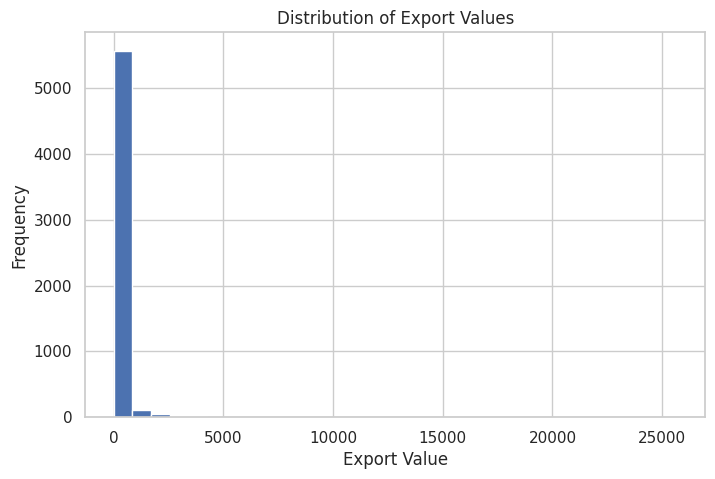

In [61]:
# ==========================================================
# 4.4 EXPORT VALUE DISTRIBUTION
# ==========================================================
#
# Objective:
# Understand the distribution of export values.
#
# This helps identify:
# • Skewness
# • Outliers
# • Extreme exporting markets
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(master["Export_Current"].dropna(), bins=30)

plt.title("Distribution of Export Values")

plt.xlabel("Export Value")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

The distribution is strongly right-skewed.
Most observations are concentrated at lower export values.
A small number of very large export values create a long right tail.
This is expected for international trade data, where a few country–commodity pairs account for a large share of exports.

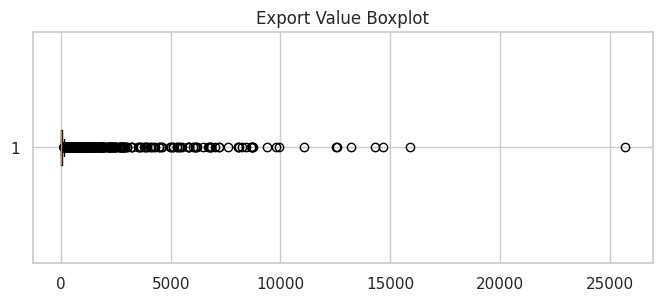

In [62]:
# ==============================================================================
# BOXPLOT
# ==============================================================================

plt.figure(figsize=(8,3))

plt.boxplot(
    master["Export_Current"].dropna(),
    vert=False
)

plt.title("Export Value Boxplot")

plt.show()

Outlier Detection and Treatment

The boxplot confirmed the presence of several extreme export values, which is expected in international trade datasets because a small number of country–commodity combinations account for a substantial proportion of total export value. These observations were reviewed and retained because they represent valid economic transactions rather than data-entry errors. However, infinite values generated during the calculation of Export_Growth_Rate (primarily when the previous export value was zero) were replaced with missing values to prevent distortion of subsequent statistical analyses. Given the strong right-skewness of export values, a logarithmic transformation will be considered during regression modelling to improve model stability and satisfy distributional assumptions.

In [63]:
# ==========================================================
# 4.5 TOP EXPORT DESTINATIONS
# ==========================================================
#
# Objective:
# Identify countries importing the largest value of
# Indian exports across all selected commodities.
# ==========================================================

top_countries = (

    master.groupby("Country")["Export_Current"]

    .sum()

    .sort_values(ascending=False)

    .head(20)

)

display(top_countries)

,Export_Current
Country,
U S A,226419.90
U Arab Emts,99841.05
Netherland,69827.78
Singapore,46740.49
Hong Kong,44092.31
U K,28773.40
Australia,27872.03
China P Rp,23648.21
South Africa,22704.61


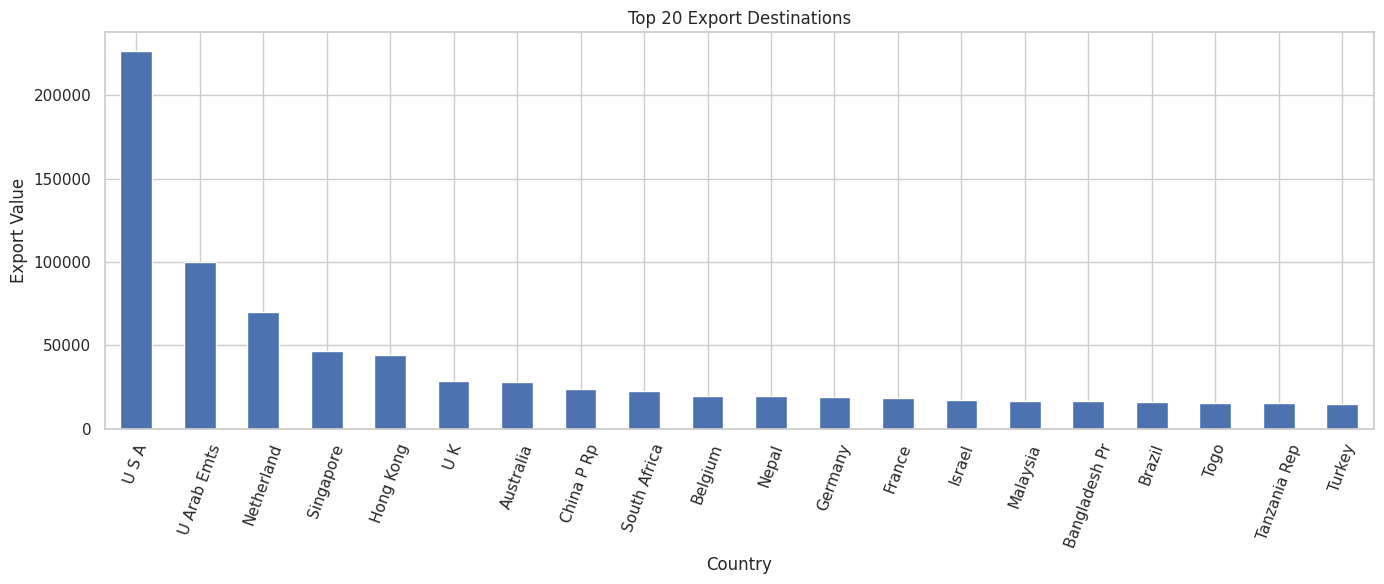

In [64]:
# ==========================================================
# VISUALIZATION:
# TOP 20 EXPORT DESTINATIONS
# ==========================================================

plt.figure(figsize=(14,6))

top_countries.plot(kind="bar")

plt.title("Top 20 Export Destinations")

plt.xlabel("Country")

plt.ylabel("Export Value")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

In [65]:
# ==========================================================
# 4.6 COMMODITY-WISE EXPORT ANALYSIS
# ==========================================================
#
# Objective:
# Compare export values across the selected HS commodities.
# ==========================================================

commodity_export = (

    master.groupby("Commodity")["Export_Current"]

    .sum()

    .sort_values(ascending=False)

)

display(commodity_export)

,Export_Current
Commodity,
27,408239.25
85,195439.67
84,172002.63
71,164741.88
30,130399.15


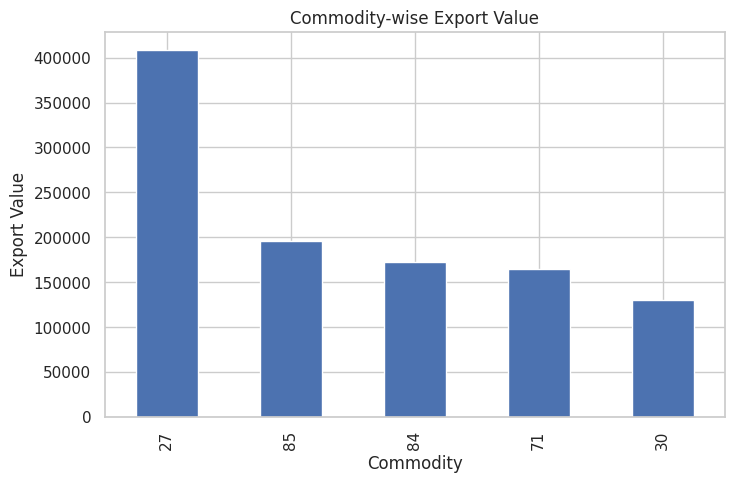

In [66]:
plt.figure(figsize=(8,5))

commodity_export.plot(kind="bar")

plt.title("Commodity-wise Export Value")

plt.xlabel("Commodity")

plt.ylabel("Export Value")

plt.grid(True)

plt.show()

In [67]:
# ==========================================================
# 4.7 EXPORT TREND ANALYSIS
# ==========================================================
#
# Objective:
# Examine how exports have changed over time.
#
# Helps answer Research Question 1.
# ==========================================================

yearly_export = (

    master.groupby("Year")["Export_Current"]

    .sum()

)

display(yearly_export)

,Export_Current
Year,
2021,105623.29
2022,173823.79
2023,215301.71
2024,207030.96
2025,197492.25
2026,171550.58


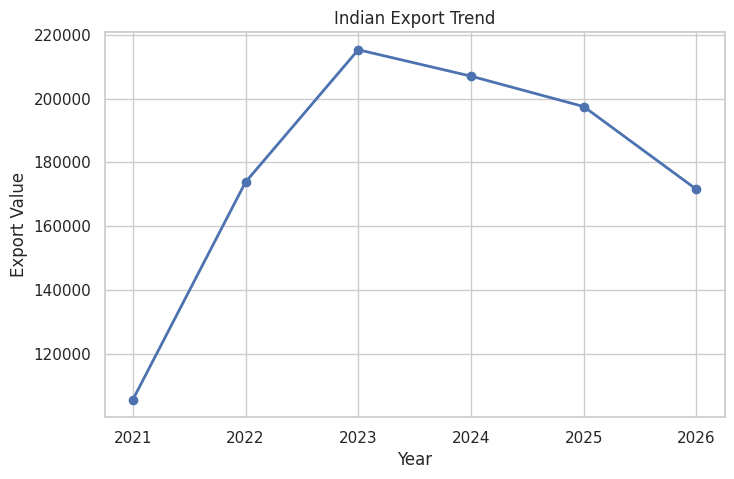

In [68]:
plt.figure(figsize=(8,5))

plt.plot(

    yearly_export.index,

    yearly_export.values,

    marker="o",

    linewidth=2

)

plt.title("Indian Export Trend")

plt.xlabel("Year")

plt.ylabel("Export Value")

plt.grid(True)

plt.show()

In [69]:
# ==============================================================================
# TOP IMPORTING COUNTRIES FOR EACH COMMODITY
# ==============================================================================

commodity_country = (

    master.groupby(["Commodity","Country"])

    ["Export_Current"]

    .sum()

    .reset_index()

)

display(commodity_country.head())

,Commodity,Country,Export_Current
0,27,Afghanistan,2.61
1,27,Albania,1347.88
2,27,Algeria,10.00
3,27,Angola,442.22
4,27,Antartica,0.30


In [70]:
# ==========================================================
# 4.8 CORRELATION ANALYSIS
# ==========================================================
#
# Objective:
# Identify relationships between exports and
# macroeconomic indicators.
#
# Variables considered:
# • GDP
# • GDP Growth
# • Population
# • Inflation
# • Trade
# ==========================================================

corr = master[[
    "Export_Current",
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]].corr()

display(corr)

,Export_Current,GDP,GDP_Growth,GDP_Per_Capita,Population,Inflation,Exports_GDP,Imports_GDP,Trade_GDP
Export_Current,1.000000,0.263329,-0.039419,0.097846,0.198948,-0.041686,0.088869,0.041568,0.069577
GDP,0.263329,1.000000,-0.103103,0.216603,0.499748,-0.063056,-0.063503,-0.170265,-0.115598
GDP_Growth,-0.039419,-0.103103,1.000000,0.010233,-0.074215,-0.135838,0.123424,0.098318,0.115716
GDP_Per_Capita,0.097846,0.216603,0.010233,1.000000,-0.150847,-0.127295,0.526326,0.337071,0.454751
Population,0.198948,0.499748,-0.074215,-0.150847,1.000000,0.039021,-0.280226,-0.349980,-0.322207
Inflation,-0.041686,-0.063056,-0.135838,-0.127295,0.039021,1.000000,-0.158126,-0.123745,-0.146908
Exports_GDP,0.088869,-0.063503,0.123424,0.526326,-0.280226,-0.158126,1.000000,0.873196,0.973495
Imports_GDP,0.041568,-0.170265,0.098318,0.337071,-0.349980,-0.123745,0.873196,1.000000,0.961517
Trade_GDP,0.069577,-0.115598,0.115716,0.454751,-0.322207,-0.146908,0.973495,0.961517,1.000000


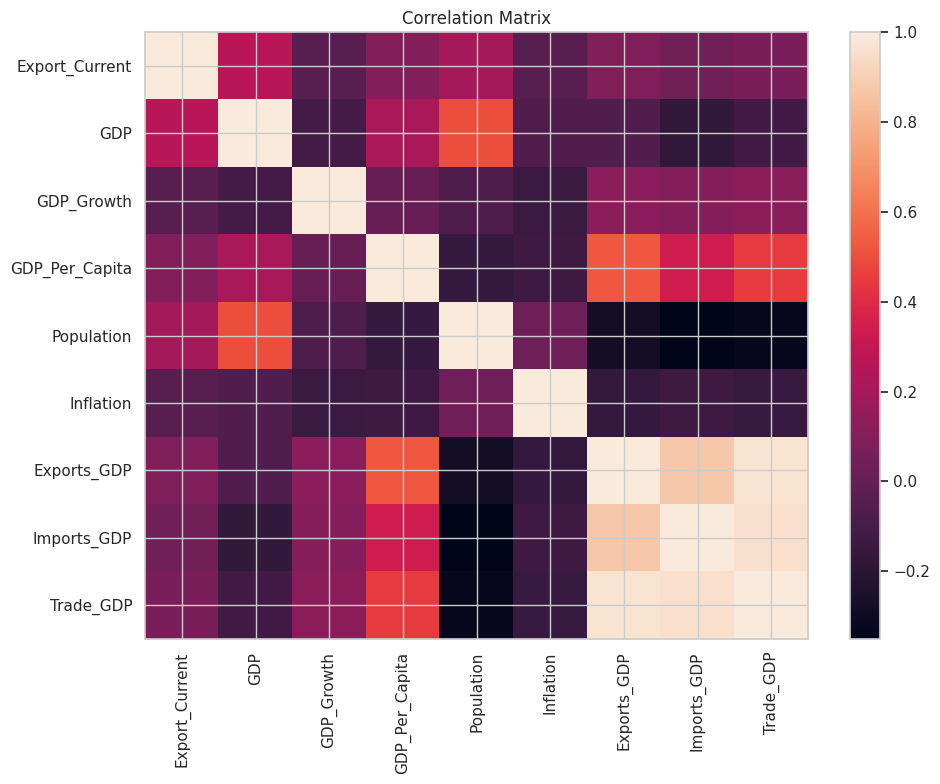

In [71]:
plt.figure(figsize=(10,8))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

The correlation matrix provides an initial indication of relationships among the predictor variables. However, correlation alone cannot determine whether multicollinearity will adversely affect regression modelling. Therefore, a Variance Inflation Factor (VIF) analysis was performed before model development.

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

features = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]

# Keep only the selected predictors
X = master[features].copy()

# Replace infinite values, if any
X = X.replace([np.inf, -np.inf], np.nan)

# Use complete cases for VIF
X = X.dropna()

print("Rows used for VIF:", len(X))

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif)

Rows used for VIF: 2688


,Variable,VIF
0,Imports_GDP,inf
1,Trade_GDP,inf
2,Exports_GDP,inf
3,GDP,2.360441
4,GDP_Per_Capita,2.103650
5,Population,1.450331
6,Inflation,0.981574
7,GDP_Growth,0.922695


In [73]:
# Remove variables causing perfect multicollinearity
features_final = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

X_final = master[features_final].dropna()

### Multicollinearity Assessment

The correlation matrix indicated strong relationships among Exports_GDP,
Imports_GDP, and Trade_GDP. Variance Inflation Factor (VIF) was used to
quantify multicollinearity before model development.

In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

features = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

# Keep only the selected predictors
X = master[features].copy()

# Replace infinite values, if any
X = X.replace([np.inf, -np.inf], np.nan)

# Use complete cases for VIF
X = X.dropna()

print("Rows used for VIF:", len(X))

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif)

Rows used for VIF: 2688


,Variable,VIF
0,Trade_GDP,3.184215
1,GDP,2.344426
2,GDP_Per_Capita,1.817895
3,Population,1.450098
4,Inflation,0.953883
5,GDP_Growth,0.921145


### Feature Selection Based on VIF

Exports_GDP, Imports_GDP, and Trade_GDP produced infinite VIF values,
indicating perfect linear dependence. Since Trade_GDP represents overall
trade openness, Trade_GDP was retained, while Exports_GDP and Imports_GDP
were excluded from the regression feature set.

In [75]:
import pandas as pd
import numpy as np
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

features_final = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

X_final = master[features_final].copy()
X_final = X_final.replace([np.inf, -np.inf], np.nan).dropna()

X_vif = add_constant(X_final)

vif_final = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Do not report the intercept VIF
vif_final = (
    vif_final[vif_final["Variable"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("Rows used for final VIF:", len(X_final))
display(vif_final)

Rows used for final VIF: 2688


,Variable,VIF
0,GDP,1.929985
1,GDP_Per_Capita,1.817980
2,Population,1.668099
3,Trade_GDP,1.553709
4,GDP_Growth,1.063955
5,Inflation,1.058584


### Final Multicollinearity Result

After removing Exports_GDP and Imports_GDP, all retained predictor variables
had VIF values below 5. Therefore, no problematic multicollinearity remained,
and all six predictors were retained for subsequent modelling.

### Interpretation of Final VIF Results

The initial VIF assessment identified perfect multicollinearity among
Exports_GDP, Imports_GDP, and Trade_GDP. Because Trade_GDP represents total
trade openness and overlaps with its export and import components,
Exports_GDP and Imports_GDP were excluded from the final predictor set.

The revised VIF results ranged from 1.06 to 1.93, which is well below the
threshold of 5. This confirms that problematic multicollinearity was removed.
GDP, GDP_Growth, GDP_Per_Capita, Population, Inflation, and Trade_GDP were
therefore retained for regression modelling.

EXPORT GROWTH ANALYSIS


,Export_Growth_Rate_Winsorized
count,5019.000000
mean,22.504806
std,77.012375
min,-80.576923
25%,-22.467654
50%,5.964912
75%,43.135169
max,245.624312


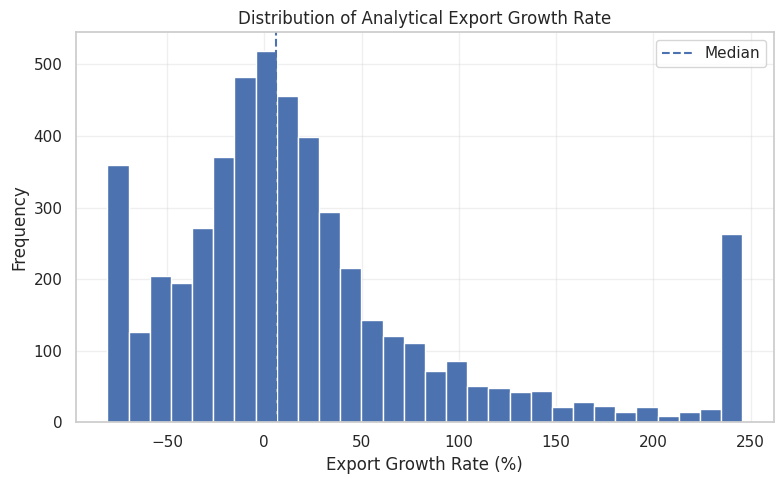

In [197]:
# ==========================================================
# 4.9 EXPORT GROWTH ANALYSIS
# ==========================================================
#
# Objective:
# Understand the distribution of export growth rates after
# excluding unreliable small-base growth observations and
# controlling extreme values through winsorization.
# ==========================================================

print("=" * 70)
print("EXPORT GROWTH ANALYSIS")
print("=" * 70)

# Descriptive statistics
display(
    master["Export_Growth_Rate_Winsorized"]
    .describe()
    .to_frame()
)

# Distribution
plt.figure(figsize=(8, 5))

plt.hist(
    master["Export_Growth_Rate_Winsorized"].dropna(),
    bins=30
)

plt.axvline(
    master["Export_Growth_Rate_Winsorized"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Analytical Export Growth Rate")
plt.xlabel("Export Growth Rate (%)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The analytical export growth distribution is positively skewed, with a median
growth rate of approximately **5.96%** compared with a higher mean of **22.50%**.
This indicates that the typical country–commodity observation experienced modest
positive export growth, while a smaller group of markets recorded substantially
higher growth rates.

The middle 50% of observations range from approximately **-22.47% to 43.14%**,
showing considerable variation in export performance across country–commodity
markets.

To prevent extreme percentage changes from very small prior-year export bases from
distorting the analysis, observations with unreliable small export bases were
excluded from the analytical growth measure and the remaining growth rates were
winsorized at the 5th and 95th percentiles. This resulted in analytical bounds of
approximately **-80.58% and 245.62%**.

The concentrations visible at the lower and upper boundaries of the histogram are
therefore a consequence of winsorization rather than naturally occurring peaks in
the underlying growth distribution.

Overall, the distribution suggests heterogeneous export performance: while many
markets experienced moderate growth or contraction, a smaller proportion recorded
strong export expansion. The winsorized measure is used for subsequent
growth-based analysis to reduce the influence of extreme observations while
preserving the overall structure of the data.

# ANALYSIS

In [78]:
# Common libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

from scipy.stats import kruskal
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Research Question 1

## Question
**Which Indian products and destination markets currently demonstrate the highest export demand, and how have these patterns evolved over time?**

## Hypotheses
- **H0₁:** Export-value distributions do not differ significantly across commodity groups.
- **H1₁:** At least one commodity group has a significantly different export-value distribution.

## Method
Destination-market ranking, commodity trend analysis, and a Kruskal–Wallis test.


In [79]:
# RQ1 data preparation

rq1 = master[["Country", "Commodity", "Year", "Export_Current"]].copy()
rq1 = rq1.replace([np.inf, -np.inf], np.nan)
rq1 = rq1.dropna(subset=["Country", "Commodity", "Year", "Export_Current"])
rq1 = rq1[rq1["Export_Current"] >= 0].copy()

print("RQ1 usable sample size:", len(rq1))


RQ1 usable sample size: 5806


,Country,Export_Current,Market_Share_Percent
0,U S A,226419.90,21.144483
1,U Arab Emts,99841.05,9.323771
2,Netherland,69827.78,6.520948
3,Singapore,46740.49,4.364914
4,Hong Kong,44092.31,4.117611
5,U K,28773.40,2.687037
6,Australia,27872.03,2.602862
7,China P Rp,23648.21,2.208415
8,South Africa,22704.61,2.120296
9,Belgium,19913.87,1.859680


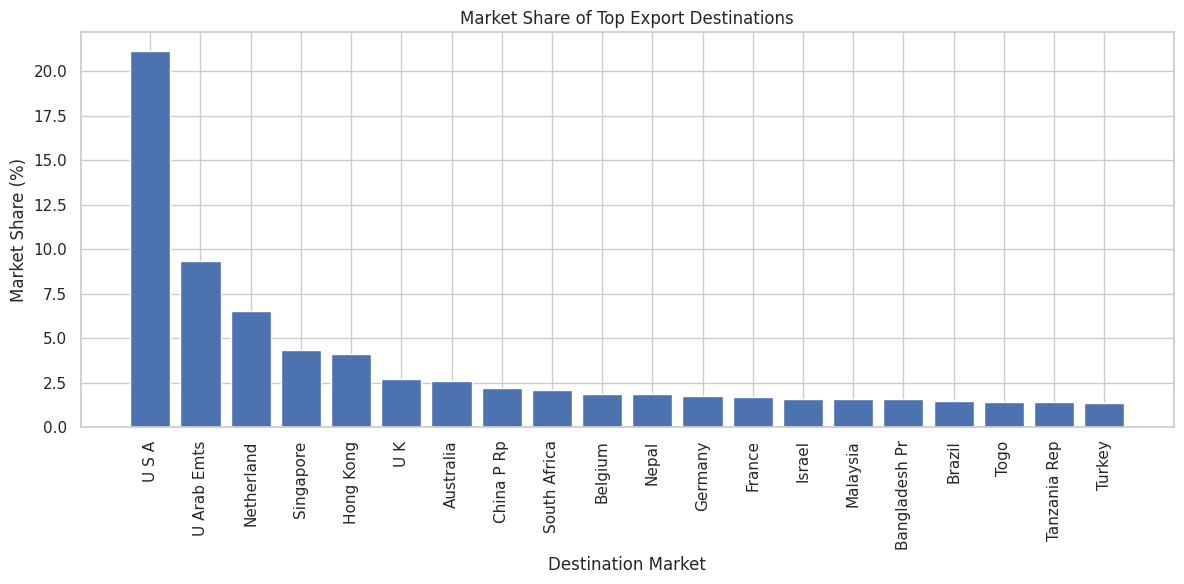

In [80]:
# RQ1 destination-market share

country_share = (
    rq1.groupby("Country", as_index=False)["Export_Current"]
       .sum()
)

country_share["Market_Share_Percent"] = (
    country_share["Export_Current"]
    / country_share["Export_Current"].sum()
    * 100
)

country_share = country_share.sort_values(
    "Market_Share_Percent", ascending=False
).reset_index(drop=True)

display(country_share.head(20))

plt.figure(figsize=(12, 6))
top20 = country_share.head(20)
plt.bar(top20["Country"], top20["Market_Share_Percent"])
plt.xticks(rotation=90)
plt.xlabel("Destination Market")
plt.ylabel("Market Share (%)")
plt.title("Market Share of Top Export Destinations")
plt.tight_layout()
plt.show()


,Year,Commodity,Export_Current
0,2021,27,26907.73
1,2021,30,19383.97
2,2021,71,26163.85
3,2021,84,18953.97
4,2021,85,14213.77


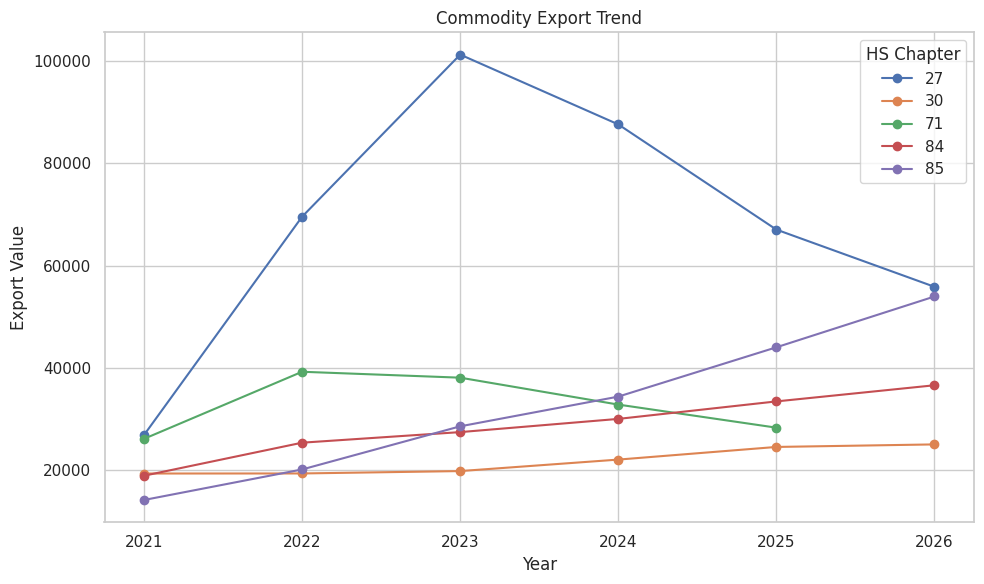

In [81]:
# RQ1 commodity trends

commodity_trend = (
    rq1.groupby(["Year", "Commodity"], as_index=False)["Export_Current"]
       .sum()
)

display(commodity_trend.head())

plt.figure(figsize=(10, 6))

for commodity, group in commodity_trend.groupby("Commodity"):
    group = group.sort_values("Year")
    plt.plot(group["Year"], group["Export_Current"], marker="o", label=str(commodity))

plt.xlabel("Year")
plt.ylabel("Export Value")
plt.title("Commodity Export Trend")
plt.legend(title="HS Chapter")
plt.tight_layout()
plt.show()


### RQ1 Export Growth Analysis

To complement the export-value trend analysis, year-over-year export
growth was examined using the cleaned analytical growth measure.
Observations with very small prior-year export bases were excluded from
growth analysis because they can generate economically misleading percentage
changes. The remaining growth rates were winsorized to reduce the influence
of extreme observations while preserving the underlying market observations.

In [198]:
# ==========================================================
# RQ1 EXPORT GROWTH ANALYSIS
# ==========================================================

rq1_growth = master[
    [
        "Country",
        "Commodity",
        "Year",
        "Export_Growth_Rate_Winsorized"
    ]
].copy()

rq1_growth = rq1_growth.dropna(
    subset=["Export_Growth_Rate_Winsorized"]
)

print("RQ1 growth-analysis sample size:", len(rq1_growth))

# Average analytical growth by commodity
commodity_growth = (
    rq1_growth
    .groupby("Commodity")["Export_Growth_Rate_Winsorized"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median", ascending=False)
)

display(commodity_growth)

RQ1 growth-analysis sample size: 5019


,count,mean,median
Commodity,,,
84,1197,21.08,8.67
30,1188,15.91,8.43
27,859,30.65,4.36
85,1118,23.54,3.07
71,657,24.60,0.00


#### Observation – Export Growth by Commodity

After excluding observations with very small prior-year export bases and
winsorizing extreme growth rates, 5,019 observations were available for
the export growth analysis.

- **HS84** recorded the highest median export growth rate at **8.67%**,
  followed closely by **HS30 at 8.43%**, indicating relatively consistent
  positive growth across these commodity groups.

- **HS27** had the highest average growth rate at **30.65%**, but its median
  was considerably lower at **4.36%**. This difference indicates that some
  relatively high-growth observations continue to raise the average even
  after treatment of extreme values.

- **HS85** recorded an average growth rate of **23.54%** and a median of
  **3.07%**, suggesting positive growth overall but with substantial
  variation across country-year observations.

- **HS71** had an average growth rate of **24.60%**, while its median growth
  was **0.00%**. This indicates that growth was less consistently positive
  across markets within this commodity group.

Overall, **HS84 and HS30 show the strongest typical growth performance based
on median growth rates**, whereas HS27, HS85 and HS71 exhibit larger
differences between their mean and median growth rates. This highlights the
importance of considering both the magnitude and consistency of export
growth when assessing market trends.

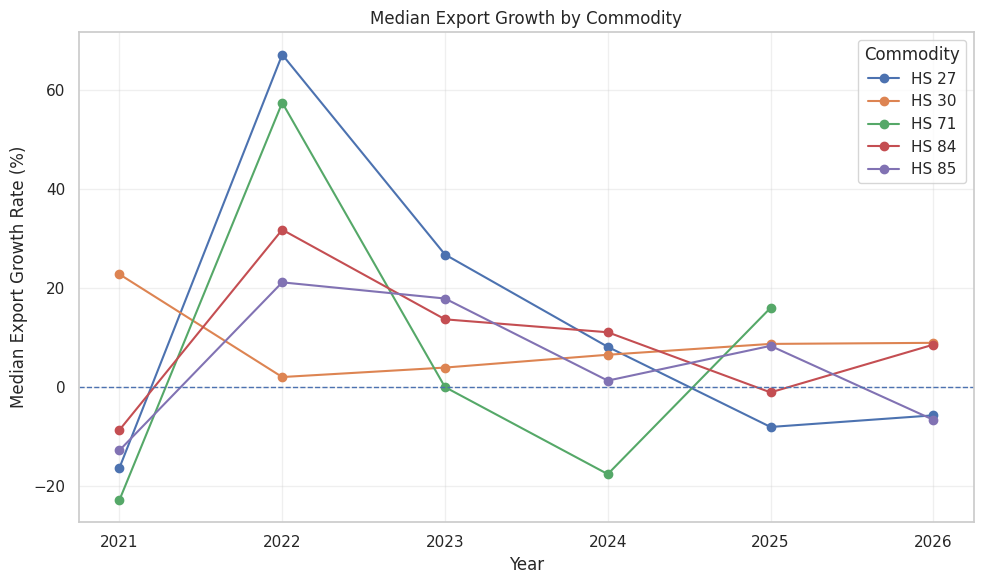

In [199]:
# Average analytical export growth by year and commodity

growth_trend = (
    rq1_growth
    .groupby(["Year", "Commodity"], as_index=False)
    ["Export_Growth_Rate_Winsorized"]
    .median()
)

plt.figure(figsize=(10, 6))

for commodity, group in growth_trend.groupby("Commodity"):
    group = group.sort_values("Year")

    plt.plot(
        group["Year"],
        group["Export_Growth_Rate_Winsorized"],
        marker="o",
        label=f"HS {commodity}"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Year")
plt.ylabel("Median Export Growth Rate (%)")
plt.title("Median Export Growth by Commodity")
plt.legend(title="Commodity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation – Temporal Export Growth Patterns

The median export growth analysis reveals substantial variation in growth
patterns across commodities between 2021 and 2026.

- **2022 represents the strongest growth year for several commodities.**
  HS27, HS71, HS84 and HS85 all recorded pronounced increases in median
  export growth during this period, with HS27 and HS71 showing the largest
  increases.

- **HS27 exhibits considerable volatility.** Its median growth increased
  sharply in 2022, remained positive in 2023 and 2024, but became negative
  in 2025 and remained slightly negative in 2026.

- **HS71 also shows a highly variable growth pattern**, moving from negative
  growth in 2021 to strong positive growth in 2022, followed by approximately
  zero growth in 2023 and a decline in 2024. It recovered again in 2025.

- **HS30 demonstrates comparatively stable recent performance.** Following
  strong growth in 2021, its median growth remained positive from 2022
  through 2026 and gradually strengthened in the later years.

- **HS84 shows relatively consistent positive growth from 2022 onward**,
  although growth weakened temporarily in 2025 before recovering in 2026.

- **HS85 experienced positive growth between 2022 and 2025**, but the median
  turned negative in 2026, indicating some weakening in the most recent
  period.

Overall, the results demonstrate that export growth is both
**commodity-specific and time-varying**. While some commodities achieve
large growth surges in particular years, HS30 and HS84 display comparatively
more consistent recent growth. These findings complement the export-value
analysis by distinguishing large export markets from commodities exhibiting
sustained growth momentum.

In [200]:
# ==========================================================
# RQ1 KRUSKAL-WALLIS HYPOTHESIS TEST
# ==========================================================

print("=" * 70)
print("RQ1 KRUSKAL-WALLIS TEST")
print("=" * 70)

print("\nH0₁: Export-value distributions do not significantly differ "
      "across commodity groups.")

print("H1₁: Export-value distributions significantly differ "
      "across commodity groups.\n")


commodity_groups = [
    group["Export_Current"].dropna().values
    for _, group in rq1.groupby("Commodity")
    if group["Export_Current"].notna().sum() > 1
]


h_statistic, p_value = kruskal(*commodity_groups)

print("Kruskal-Wallis H statistic:", round(h_statistic, 4))
print("p-value:", p_value)


if p_value < 0.05:
    print("\nDecision: Reject H0₁.")
    print(
        "Conclusion: Export-value distributions differ "
        "significantly across commodity groups."
    )
else:
    print("\nDecision: Fail to reject H0₁.")
    print(
        "Conclusion: There is insufficient evidence to conclude "
        "that export-value distributions differ significantly "
        "across commodity groups."
    )

RQ1 KRUSKAL-WALLIS TEST

H0₁: Export-value distributions do not significantly differ across commodity groups.
H1₁: Export-value distributions significantly differ across commodity groups.

Kruskal-Wallis H statistic: 415.8915
p-value: 1.0240886935137692e-88

Decision: Reject H0₁.
Conclusion: Export-value distributions differ significantly across commodity groups.


## RQ1 – Final Insight

RQ1 examined which selected Indian export products and destination markets
demonstrate the highest export demand and how these patterns have evolved
over time.

The destination-market analysis shows that export demand is concentrated in
a relatively small number of major markets. The **United States is the leading
destination**, accounting for approximately **21.14%** of total export value
within the selected dataset, followed by the **United Arab Emirates (9.32%)**
and the **Netherlands (6.52%)**. This indicates that these markets represent
important established destinations for the selected Indian export categories.

At the commodity level, **HS27 records the highest overall export value**,
followed by HS85, HS84, HS71 and HS30. However, export value alone does not
fully describe market momentum. The cleaned growth analysis, based on
**5,019 valid observations** after excluding unreliable small-base growth
rates and winsorizing extreme values, reveals differences in the consistency
of growth across commodities.

Based on median analytical growth, **HS84 (8.67%) and HS30 (8.43%) show the
strongest typical growth performance**. HS27 records the highest mean growth
(30.65%) but a substantially lower median growth (4.36%), indicating greater
variation in growth across markets. HS85 records a median growth rate of
3.07%, while HS71 has a median of 0.00%, suggesting less consistent growth.

The temporal growth analysis further demonstrates that export momentum is
not constant over time. Several commodities experienced particularly strong
growth in **2022**, while subsequent years show greater divergence. HS30
maintains comparatively stable positive median growth in the later periods,
whereas HS27 and HS71 display considerably greater volatility.

The **Kruskal–Wallis test indicates statistically significant differences in
export-value distributions across the selected commodity groups
(H = 415.89, p < 0.001)**. Therefore, **H0₁ is rejected**, providing statistical
evidence that export demand differs across commodity categories.

### Overall Conclusion

RQ1 demonstrates that **market size and market growth provide complementary
signals of export opportunity**. Large established destinations such as the
United States, UAE and Netherlands account for substantial export demand,
while commodity-level analysis shows that the largest export categories are
not necessarily those with the most consistent growth.

Therefore, export-market assessment should consider both the **current scale
of export demand** and the **stability and direction of export growth** rather
than relying on export value alone. These findings provide the descriptive
and statistical foundation for the later predictive modelling and Export
Market Attractiveness Score (EMAS) framework.

# Research Question 2

## Question
**Which macroeconomic and trade-related factors significantly influence export demand across international markets?**

## Hypotheses
- **H0₂:** The selected macroeconomic indicators do not significantly influence export demand.
- **H1₂:** At least one selected macroeconomic indicator significantly influences export demand.

## Method
Correlation analysis, VIF-based feature selection, log transformation, and multiple linear regression with HC3 robust standard errors.


,Export_Current,GDP,GDP_Growth,GDP_Per_Capita,Population,Inflation,Exports_GDP,Imports_GDP,Trade_GDP
Export_Current,1.000000,0.263329,-0.039419,0.097846,0.198948,-0.041686,0.088869,0.041568,0.069577
GDP,0.263329,1.000000,-0.103103,0.216603,0.499748,-0.063056,-0.063503,-0.170265,-0.115598
GDP_Growth,-0.039419,-0.103103,1.000000,0.010233,-0.074215,-0.135838,0.123424,0.098318,0.115716
GDP_Per_Capita,0.097846,0.216603,0.010233,1.000000,-0.150847,-0.127295,0.526326,0.337071,0.454751
Population,0.198948,0.499748,-0.074215,-0.150847,1.000000,0.039021,-0.280226,-0.349980,-0.322207
Inflation,-0.041686,-0.063056,-0.135838,-0.127295,0.039021,1.000000,-0.158126,-0.123745,-0.146908
Exports_GDP,0.088869,-0.063503,0.123424,0.526326,-0.280226,-0.158126,1.000000,0.873196,0.973495
Imports_GDP,0.041568,-0.170265,0.098318,0.337071,-0.349980,-0.123745,0.873196,1.000000,0.961517
Trade_GDP,0.069577,-0.115598,0.115716,0.454751,-0.322207,-0.146908,0.973495,0.961517,1.000000


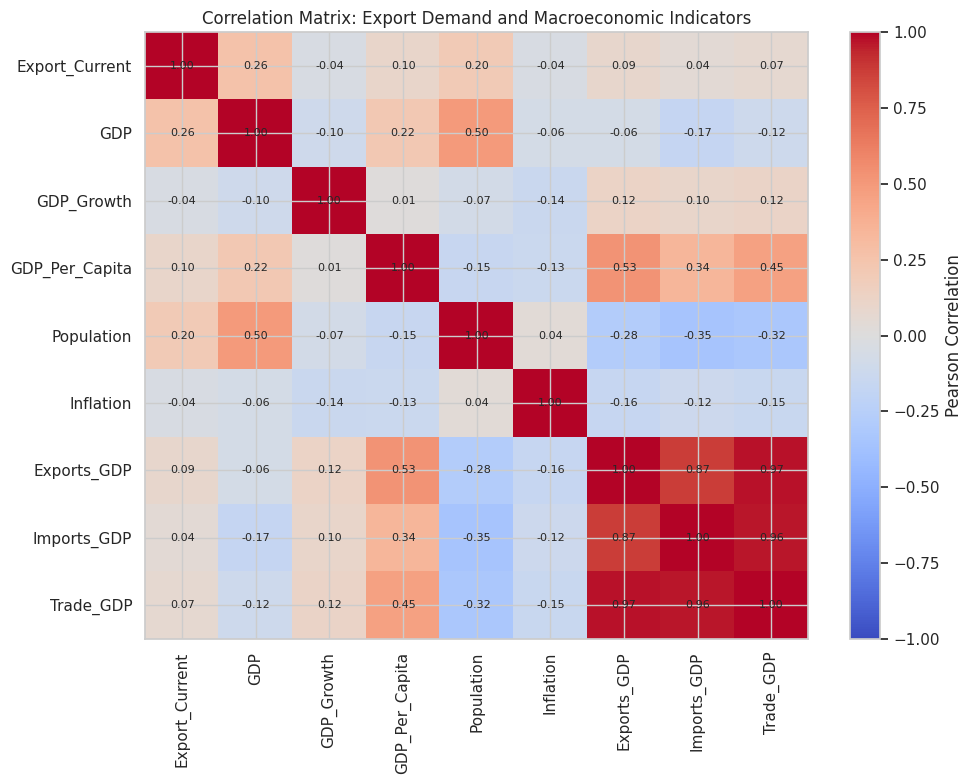

In [83]:
# RQ2 correlation analysis

rq2_corr_variables = [
    "Export_Current", "GDP", "GDP_Growth", "GDP_Per_Capita",
    "Population", "Inflation", "Exports_GDP", "Imports_GDP", "Trade_GDP"
]

corr = master[rq2_corr_variables].corr()
display(corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Pearson Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Matrix: Export Demand and Macroeconomic Indicators")
plt.tight_layout()
plt.show()


### RQ2 Correlation Analysis – Observations

The correlation analysis provides an initial assessment of the relationship between export demand and the selected macroeconomic and trade indicators.

- **GDP shows the strongest positive correlation with export demand (r = 0.26)**, suggesting that larger economies tend to be associated with higher export demand.

- **Population also shows a positive relationship (r = 0.20)**, indicating that larger consumer markets may provide greater export opportunities.

- **GDP per capita (r = 0.10)** and the trade-related indicators — **Exports/GDP (r = 0.09), Trade/GDP (r = 0.07), and Imports/GDP (r = 0.04)** — exhibit relatively weak direct correlations with export demand.

- **GDP growth and inflation both show correlations of approximately -0.04**, indicating little direct linear association with export demand in the pooled dataset.

- Strong correlations are observed among the trade-openness indicators. In particular, **Exports/GDP, Imports/GDP, and Trade/GDP are highly correlated (approximately r = 0.87–0.97)**. Including these variables simultaneously in a regression model may therefore introduce multicollinearity.

- Consequently, correlation analysis alone is insufficient to determine which factors significantly influence export demand. Multivariate regression and multicollinearity diagnostics such as VIF are required to isolate the independent contribution of each explanatory variable.

In [84]:
# RQ2 initial VIF

initial_features = [
    "GDP", "GDP_Growth", "GDP_Per_Capita", "Population",
    "Inflation", "Exports_GDP", "Imports_GDP", "Trade_GDP"
]

X_initial = master[initial_features].replace([np.inf, -np.inf], np.nan).dropna()
X_initial_vif = add_constant(X_initial)

initial_vif = pd.DataFrame({
    "Variable": X_initial_vif.columns,
    "VIF": [
        variance_inflation_factor(X_initial_vif.values, i)
        for i in range(X_initial_vif.shape[1])
    ]
})

initial_vif = initial_vif[
    initial_vif["Variable"] != "const"
].sort_values("VIF", ascending=False).reset_index(drop=True)

display(initial_vif)


,Variable,VIF
0,Imports_GDP,inf
1,Trade_GDP,inf
2,Exports_GDP,inf
3,GDP_Per_Capita,2.168161
4,GDP,1.935040
5,Population,1.713802
6,GDP_Growth,1.084378
7,Inflation,1.059242


In [85]:
# RQ2 final VIF after removing Exports_GDP and Imports_GDP

rq2_predictors = [
    "GDP", "GDP_Growth", "GDP_Per_Capita",
    "Population", "Inflation", "Trade_GDP"
]

X_final = master[rq2_predictors].replace([np.inf, -np.inf], np.nan).dropna()
X_final_vif = add_constant(X_final)

final_vif = pd.DataFrame({
    "Variable": X_final_vif.columns,
    "VIF": [
        variance_inflation_factor(X_final_vif.values, i)
        for i in range(X_final_vif.shape[1])
    ]
})

final_vif = final_vif[
    final_vif["Variable"] != "const"
].sort_values("VIF", ascending=False).reset_index(drop=True)

display(final_vif)


,Variable,VIF
0,GDP,1.929985
1,GDP_Per_Capita,1.817980
2,Population,1.668099
3,Trade_GDP,1.553709
4,GDP_Growth,1.063955
5,Inflation,1.058584


In [86]:
# RQ2 multiple linear regression

rq2 = master[["Export_Current"] + rq2_predictors].copy()
rq2 = rq2.replace([np.inf, -np.inf], np.nan).dropna()
rq2 = rq2[rq2["Export_Current"] >= 0].copy()
rq2["Log_Export_Current"] = np.log1p(rq2["Export_Current"])

X_raw = rq2[rq2_predictors]
X_standardised = (X_raw - X_raw.mean()) / X_raw.std()
X_model = sm.add_constant(X_standardised)
y = rq2["Log_Export_Current"]

rq2_model = sm.OLS(y, X_model).fit(cov_type="HC3")

print("RQ2 usable sample size:", len(rq2))
print(rq2_model.summary())


RQ2 usable sample size: 2651
                            OLS Regression Results                            
Dep. Variable:     Log_Export_Current   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     107.5
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          1.66e-121
Time:                        17:56:54   Log-Likelihood:                -5366.6
No. Observations:                2651   AIC:                         1.075e+04
Df Residuals:                    2644   BIC:                         1.079e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const          

In [87]:
# RQ2 coefficient table and hypothesis decision

rq2_results = pd.DataFrame({
    "Coefficient": rq2_model.params,
    "Robust_Std_Error": rq2_model.bse,
    "Statistic": rq2_model.tvalues,
    "p_value": rq2_model.pvalues,
    "CI_Lower_95": rq2_model.conf_int()[0],
    "CI_Upper_95": rq2_model.conf_int()[1]
})

rq2_results["Significant_5pct"] = np.where(
    rq2_results["p_value"] < 0.05, "Yes", "No"
)

display(rq2_results.drop(index="const", errors="ignore").sort_values("p_value"))

print("R-squared:", round(rq2_model.rsquared, 4))
print("Adjusted R-squared:", round(rq2_model.rsquared_adj, 4))
print("Overall model p-value:", rq2_model.f_pvalue)

if rq2_model.f_pvalue < 0.05:
    print("Decision: Reject H0₂.")
else:
    print("Decision: Fail to reject H0₂.")


,Coefficient,Robust_Std_Error,Statistic,p_value,CI_Lower_95,CI_Upper_95,Significant_5pct
GDP,0.591777,0.058598,10.098989,5.581454e-24,0.476927,0.706626,Yes
Population,0.492125,0.052991,9.286995,1.587050e-20,0.388265,0.595986,Yes
GDP_Per_Capita,0.223880,0.051689,4.331291,1.482379e-05,0.122572,0.325189,Yes
GDP_Growth,-0.062688,0.032685,-1.917929,5.512002e-02,-0.126749,0.001374,No
Trade_GDP,0.033210,0.052369,0.634151,5.259822e-01,-0.069431,0.135851,No
Inflation,-0.000290,0.031747,-0.009142,9.927059e-01,-0.062513,0.061933,No


R-squared: 0.2332
Adjusted R-squared: 0.2315
Overall model p-value: 1.656160296246649e-121
Decision: Reject H0₂.


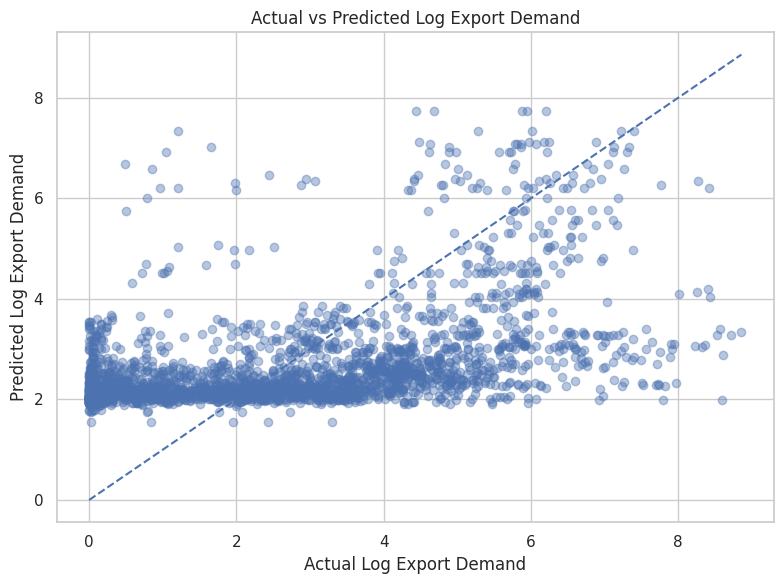

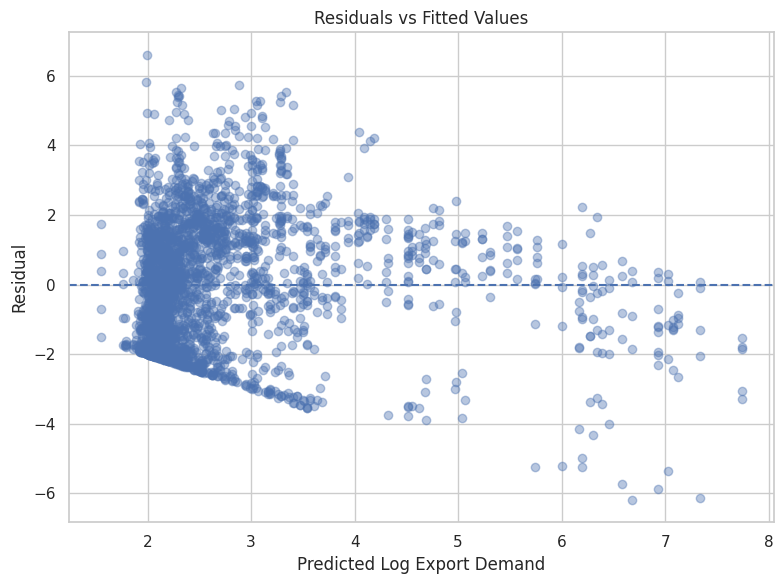

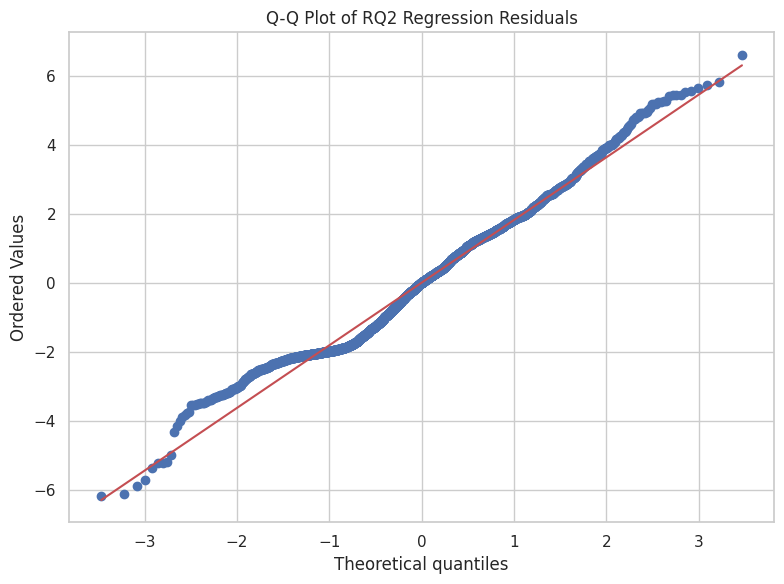

In [88]:
# RQ2 diagnostics

predicted = rq2_model.predict(X_model)
residuals = y - predicted

plt.figure(figsize=(8, 6))
plt.scatter(y, predicted, alpha=0.4)
minimum = min(y.min(), predicted.min())
maximum = max(y.max(), predicted.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Log Export Demand")
plt.ylabel("Predicted Log Export Demand")
plt.title("Actual vs Predicted Log Export Demand")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(predicted, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Log Export Demand")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of RQ2 Regression Residuals")
plt.tight_layout()
plt.show()


## RQ2 – Final Insight

**Research Question:**  
Which macroeconomic and trade-related factors significantly influence export demand across international markets?

### Key Findings

The RQ2 analysis was conducted using 2,651 complete observations. Initial correlation analysis indicated that GDP had the strongest positive association with export demand among the selected macroeconomic variables, while strong correlations were observed among the original trade-openness indicators. Multicollinearity was therefore assessed before estimating the final regression model.

Following feature selection, all variables included in the final model had VIF values below 2 (maximum VIF ≈ 1.93), indicating that multicollinearity was not a concern in the final regression specification.

The multiple linear regression model with HC3 heteroskedasticity-robust standard errors was statistically significant overall (F = 107.5, p < 0.001). The model achieved an R² of 0.233 and an adjusted R² of 0.232, explaining approximately 23.3% of the variation in log export demand.

At the 5% significance level:

- **GDP** had a statistically significant positive association with export demand (β = 0.5918, p < 0.001).
- **Population** had a statistically significant positive association with export demand (β = 0.4921, p < 0.001).
- **GDP per capita** also had a statistically significant positive association with export demand (β = 0.2239, p < 0.001).
- **GDP growth** had a small negative coefficient (β = -0.0627), but was not statistically significant at the 5% level (p = 0.055).
- **Inflation** was not statistically significant (p = 0.993).
- **Trade as a percentage of GDP** was also not statistically significant after controlling for the other macroeconomic factors (p = 0.526).

The regression diagnostics showed evidence of heteroskedasticity and departures from residual normality, particularly in the tails. HC3 robust standard errors were therefore used to provide more reliable statistical inference under heteroskedasticity.

### Hypothesis Decision

**H0₂:** Macroeconomic and trade-related indicators do not significantly influence export demand.

**Decision:** Reject H0₂.

The results provide statistically significant evidence that selected macroeconomic characteristics influence export demand. In particular, **GDP, population, and GDP per capita emerge as the principal significant macroeconomic factors in the final model**.

### Business Interpretation

The findings indicate that export-market attractiveness is influenced primarily by the **economic scale and purchasing capacity of destination markets**. Countries with larger economies, larger populations, and higher income levels tend to exhibit greater export demand.

However, the moderate explanatory power of the model (R² = 0.233) shows that macroeconomic conditions alone do not fully determine export demand. Commodity-specific demand, India's existing export position, import-market characteristics, competition, and historical trade patterns are also likely to contribute to market attractiveness.

This supports the subsequent EMAS framework, which combines macroeconomic strength with export demand, import demand, India's market opportunity, competitive conditions, growth, and predicted demand rather than relying on macroeconomic indicators alone.

# Research Question 3

## Question
**How do supplier competition and India’s market share influence export opportunities across international markets?**

## Hypotheses
- **H0₃:** Supplier competition and India’s market share do not significantly influence export opportunities.
- **H1₃:** Supplier competition and/or India’s market share significantly influence export opportunities.


In [89]:
# ==============================================================================
# RESEARCH QUESTION 3
#
# How do supplier competition and India's market share influence export
# opportunities across international markets?
#
# H0₃:
# Supplier competition and India's market share do not significantly
# influence export opportunities.
#
# H1₃:
# Supplier competition and/or India's market share significantly
# influence export opportunities.

# Purpose:
# Before constructing India's market share, supplier count, and HHI,
# inspect the coverage of the raw UN Comtrade dataset.

# For RQ3:
#   Reporter = destination/importing market
#   Partner  = supplier/exporting country
#   Flow     = imports into the destination
#   Commodity = HS product category
# ==============================================================================

In [111]:
# ==============================================================================
# RQ3 - STEP 1: INSPECT RAW UN COMTRADE DATA
# ==============================================================================
# Purpose:
# Inspect the original Comtrade file BEFORE applying any filters.
# This allows us to identify the correct reporter, partner, flow,
# commodity, year, and trade-value columns required for RQ3.
# ==============================================================================

print("Raw Comtrade shape:")
print(comtrade_raw.shape)

print("\nRaw Comtrade columns:")
print(comtrade_raw.columns.tolist())

print("\nFirst 5 rows:")
display(comtrade_raw.head())

print("\nData types:")
display(comtrade_raw.dtypes)

Raw Comtrade shape:
(100000, 47)

Raw Comtrade columns:
['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']

First 5 rows:


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,1146.40,640.00,1146.40,0,False,True
1,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,572806.98,555763.48,572806.98,0,False,True
2,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,63.00,20.00,63.00,0,False,True
3,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,886.95,850.01,886.95,0,False,True
4,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,66.03,50.00,66.03,0,False,True



Data types:


,0
typeCode,object
freqCode,object
refPeriodId,int64
refYear,int64
refMonth,int64
period,int64
reporterCode,int64
reporterISO,object
reporterDesc,object
flowCode,object


In [112]:

# ------------------------------------------------------------------------------
# 1. DATASET SIZE
# ------------------------------------------------------------------------------

print("Raw Comtrade shape:", comtrade_raw.shape)


# ------------------------------------------------------------------------------
# 2. YEAR COVERAGE
# ------------------------------------------------------------------------------

print("\nYear coverage:")
print(
    sorted(
        comtrade_raw["refYear"]
        .dropna()
        .unique()
    )
)


# ------------------------------------------------------------------------------
# 3. TRADE FLOW
# ------------------------------------------------------------------------------

print("\nTrade flow distribution:")
print(
    comtrade_raw["flowDesc"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------------------------
# 4. REPORTER / DESTINATION MARKETS
# ------------------------------------------------------------------------------

print("\nNumber of reporter markets:")
print(
    comtrade_raw["reporterDesc"]
    .nunique()
)

print("\nReporter markets:")
print(
    comtrade_raw["reporterDesc"]
    .value_counts()
    .head(30)
)


# ------------------------------------------------------------------------------
# 5. PARTNER / SUPPLIER COUNTRIES
# ------------------------------------------------------------------------------

print("\nNumber of supplier/partner values:")
print(
    comtrade_raw["partnerDesc"]
    .nunique()
)

print("\nMost common supplier/partner values:")
print(
    comtrade_raw["partnerDesc"]
    .value_counts()
    .head(30)
)


# ------------------------------------------------------------------------------
# 6. CHECK WHETHER INDIA EXISTS AS A SUPPLIER
# ------------------------------------------------------------------------------

india_rows = comtrade_raw[
    comtrade_raw["partnerDesc"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("india")
]

print("\nRows where India is the supplier:")
print(len(india_rows))

if len(india_rows) > 0:

    print("\nSample India supplier records:")

    display(
        india_rows[
            [
                "refYear",
                "reporterDesc",
                "partnerDesc",
                "flowDesc",
                "cmdCode",
                "cmdDesc",
                "primaryValue"
            ]
        ].head(10)
    )


# ------------------------------------------------------------------------------
# 7. COMMODITY COVERAGE
# ------------------------------------------------------------------------------

print("\nNumber of commodity codes:")
print(
    comtrade_raw["cmdCode"]
    .nunique()
)

print("\nMost common commodity codes:")
print(
    comtrade_raw["cmdCode"]
    .astype(str)
    .value_counts()
    .head(30)
)


# ------------------------------------------------------------------------------
# 8. CHECK OUR FIVE TARGET HS CHAPTERS
# ------------------------------------------------------------------------------

target_hs = ["27", "30", "71", "84", "85"]

cmd_string = (
    comtrade_raw["cmdCode"]
    .astype(str)
    .str.strip()
)

print("\nRows for target HS chapters:")

for hs in target_hs:

    count = cmd_string.str.startswith(hs).sum()

    print(
        f"HS {hs}: {count:,} rows"
    )

Raw Comtrade shape: (100000, 47)

Year coverage:
[np.int64(2020)]

Trade flow distribution:
flowDesc
Import    100000
Name: count, dtype: int64

Number of reporter markets:
64

Reporter markets:
reporterDesc
France                11547
Germany                8809
Canada                 8793
Czechia                8299
Colombia               5288
Finland                5217
Argentina              4841
Estonia                4451
Bosnia Herzegovina     4400
Ecuador                4006
Dominican Rep.         3891
Belarus                3637
Albania                3500
Cyprus                 2955
Azerbaijan             2699
Armenia                1082
Belgium                 761
China                   707
Austria                 669
Australia               633
Denmark                 570
Brazil                  551
Chile                   495
Costa Rica              471
Sri Lanka               460
Greece                  453
Angola                  446
El Salvador             437
Bahrain 

,refYear,reporterDesc,partnerDesc,flowDesc,cmdCode,cmdDesc,primaryValue
159,2020,Angola,India,Import,71,"Natural, cultured pearls; precious, semi-preci...",1.426950e+03
376,2020,Angola,India,Import,85,Electrical machinery and equipment and parts t...,1.788049e+07
393,2020,Angola,India,Import,84,"Nuclear reactors, boilers, machinery and mecha...",3.357727e+07
399,2020,Angola,India,Import,30,Pharmaceutical products,1.096802e+08
439,2020,Angola,India,Import,27,"Mineral fuels, mineral oils and products of th...",9.587902e+07
501,2020,Belize,India,Import,27,"Mineral fuels, mineral oils and products of th...",5.326340e+03
531,2020,Belize,India,Import,85,Electrical machinery and equipment and parts t...,6.575400e+02
583,2020,Belize,India,Import,30,Pharmaceutical products,1.211615e+06
607,2020,Belize,India,Import,84,"Nuclear reactors, boilers, machinery and mecha...",1.772861e+05
676,2020,Bolivia (Plurinational State of),India,Import,84,"Nuclear reactors, boilers, machinery and mecha...",7.296287e+06



Number of commodity codes:
5

Most common commodity codes:
cmdCode
85    35758
84    35432
30    12334
71     8615
27     7861
Name: count, dtype: int64

Rows for target HS chapters:
HS 27: 7,861 rows
HS 30: 12,334 rows
HS 71: 8,615 rows
HS 84: 35,432 rows
HS 85: 35,758 rows


In [109]:
# ==============================================================================
#
# RQ3 - STEP 2:
# Construct the supplier-level import dataset required to calculate:
#
#   1. Total destination import demand
#   2. India's import value
#   3. India's market share
#   4. Number of competing suppliers
#   5. Herfindahl-Hirschman Index (HHI)
#
# Unit of analysis:
# Destination × Commodity × Year
# ==============================================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------------------------
# 1. SELECT REQUIRED VARIABLES
# ------------------------------------------------------------------------------

rq3_raw = comtrade_raw[
    [
        "refYear",
        "reporterDesc",
        "reporterISO",
        "partnerDesc",
        "partnerISO",
        "flowDesc",
        "cmdCode",
        "cmdDesc",
        "primaryValue"
    ]
].copy()


# ------------------------------------------------------------------------------
# 2. RENAME VARIABLES FOR READABILITY
# ------------------------------------------------------------------------------

rq3_raw = rq3_raw.rename(
    columns={
        "refYear": "Year",
        "reporterDesc": "Destination",
        "reporterISO": "Destination_ISO",
        "partnerDesc": "Supplier",
        "partnerISO": "Supplier_ISO",
        "flowDesc": "Trade_Flow",
        "cmdCode": "Commodity",
        "cmdDesc": "Commodity_Name",
        "primaryValue": "Import_Value"
    }
)


# ------------------------------------------------------------------------------
# 3. RETAIN IMPORT FLOWS ONLY
# ------------------------------------------------------------------------------

rq3_raw = rq3_raw[
    rq3_raw["Trade_Flow"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("import")
].copy()


# ------------------------------------------------------------------------------
# 4. RETAIN TARGET HS CHAPTERS
# ------------------------------------------------------------------------------

target_hs = ["27", "30", "71", "84", "85"]

rq3_raw["Commodity"] = (
    rq3_raw["Commodity"]
    .astype(str)
    .str.strip()
)

rq3_raw = rq3_raw[
    rq3_raw["Commodity"].isin(target_hs)
].copy()


# ------------------------------------------------------------------------------
# 5. CLEAN IMPORT VALUES
# ------------------------------------------------------------------------------

rq3_raw["Import_Value"] = pd.to_numeric(
    rq3_raw["Import_Value"],
    errors="coerce"
)

rq3_raw = rq3_raw.dropna(
    subset=[
        "Year",
        "Destination",
        "Supplier",
        "Commodity",
        "Import_Value"
    ]
)

# Import values used for market-share calculations must be non-negative.
rq3_raw = rq3_raw[
    rq3_raw["Import_Value"] >= 0
].copy()


# ------------------------------------------------------------------------------
# 6. REMOVE AGGREGATE PARTNER RECORDS
# ------------------------------------------------------------------------------

# Comtrade may contain aggregate partner categories such as "World".
# HHI must be calculated from individual supplier countries rather than
# aggregate totals.

aggregate_partners = [
    "World",
    "All Countries",
    "Other Asia, nes",
    "Areas, nes",
    "Free Zones",
    "Bunkers"
]

rq3_raw = rq3_raw[
    ~rq3_raw["Supplier"].isin(aggregate_partners)
].copy()


# ------------------------------------------------------------------------------
# 7. AGGREGATE DUPLICATE SUPPLIER RECORDS
# ------------------------------------------------------------------------------

# Multiple Comtrade records may exist for the same
# Destination × Commodity × Year × Supplier combination.
# Sum these records before calculating supplier shares.

rq3_supplier = (
    rq3_raw
    .groupby(
        [
            "Year",
            "Destination",
            "Destination_ISO",
            "Commodity",
            "Commodity_Name",
            "Supplier",
            "Supplier_ISO"
        ],
        as_index=False,
        dropna=False
    )["Import_Value"]
    .sum()
)


# ------------------------------------------------------------------------------
# 8. BASIC VALIDATION
# ------------------------------------------------------------------------------

print("RQ3 supplier-level rows:", len(rq3_supplier))

print(
    "Destination markets:",
    rq3_supplier["Destination"].nunique()
)

print(
    "Supplier countries:",
    rq3_supplier["Supplier"].nunique()
)

print(
    "Years:",
    sorted(rq3_supplier["Year"].unique())
)

print(
    "Commodities:",
    sorted(rq3_supplier["Commodity"].unique())
)

india_check = rq3_supplier[
    rq3_supplier["Supplier"]
    .astype(str)
    .str.casefold()
    .eq("india")
]

print(
    "India supplier records:",
    len(india_check)
)

display(rq3_supplier.head(10))

RQ3 supplier-level rows: 23567
Destination markets: 64
Supplier countries: 237
Years: [np.int64(2020)]
Commodities: ['27', '30', '71', '84', '85']
India supplier records: 300


,Year,Destination,Destination_ISO,Commodity,Commodity_Name,Supplier,Supplier_ISO,Import_Value
0,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Algeria,DZA,3.942040e+07
1,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Austria,AUT,5.960731e+06
2,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Azerbaijan,AZE,8.525296e+06
3,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Belgium,BEL,1.870593e+06
4,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Bosnia Herzegovina,BIH,8.239060e+04
5,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Bulgaria,BGR,4.159570e+05
6,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Canada,CAN,1.193348e+05
7,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",China,CHN,1.049218e+05
8,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Colombia,COL,3.743559e+06
9,2020,Albania,ALB,27,"Mineral fuels, mineral oils and products of th...",Croatia,HRV,3.446736e+07


In [113]:
# ==============================================================================
# RQ3 - STEP 3
# CALCULATE INDIA MARKET SHARE, SUPPLIER COUNT AND HHI
#
# Unit of analysis:
# Destination × Commodity × Year
#
# Measures:
#   Total_Imports        = total imports from all individual suppliers
#   India_Imports        = imports supplied by India
#   India_Market_Share   = India's percentage share of destination imports
#   Supplier_Count       = number of active supplier countries
#   HHI                  = supplier concentration index (0-10,000 scale)
#
# HHI Interpretation:
#   HHI < 1,500          = Unconcentrated / competitive
#   1,500 <= HHI < 2,500 = Moderately concentrated
#   HHI >= 2,500         = Highly concentrated
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. REMOVE ZERO-VALUE SUPPLIER RECORDS
# ------------------------------------------------------------------------------

# Zero-value observations do not represent active suppliers and therefore
# should not contribute to supplier counts or HHI calculations.

rq3_active = rq3_supplier[
    rq3_supplier["Import_Value"] > 0
].copy()


# ------------------------------------------------------------------------------
# 2. CALCULATE TOTAL IMPORTS FOR EACH DESTINATION-MARKET
# ------------------------------------------------------------------------------

market_keys = [
    "Year",
    "Destination",
    "Destination_ISO",
    "Commodity",
    "Commodity_Name"
]

market_total = (
    rq3_active
    .groupby(
        market_keys,
        as_index=False
    )["Import_Value"]
    .sum()
    .rename(
        columns={
            "Import_Value": "Total_Imports"
        }
    )
)


# ------------------------------------------------------------------------------
# 3. CALCULATE INDIA'S IMPORT VALUE
# ------------------------------------------------------------------------------

india_imports = (
    rq3_active[
        rq3_active["Supplier"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("india")
    ]
    .groupby(
        market_keys,
        as_index=False
    )["Import_Value"]
    .sum()
    .rename(
        columns={
            "Import_Value": "India_Imports"
        }
    )
)


# ------------------------------------------------------------------------------
# 4. CALCULATE NUMBER OF ACTIVE SUPPLIERS
# ------------------------------------------------------------------------------

supplier_count = (
    rq3_active
    .groupby(
        market_keys,
        as_index=False
    )["Supplier"]
    .nunique()
    .rename(
        columns={
            "Supplier": "Supplier_Count"
        }
    )
)


# ------------------------------------------------------------------------------
# 5. CALCULATE EACH SUPPLIER'S MARKET SHARE
# ------------------------------------------------------------------------------

rq3_shares = rq3_active.merge(
    market_total,
    on=market_keys,
    how="left"
)

rq3_shares["Supplier_Share"] = (
    rq3_shares["Import_Value"]
    / rq3_shares["Total_Imports"]
)

# Percentage share - useful for interpretation
rq3_shares["Supplier_Share_Percent"] = (
    rq3_shares["Supplier_Share"] * 100
)


# ------------------------------------------------------------------------------
# 6. CALCULATE HHI
# ------------------------------------------------------------------------------

# HHI is calculated using percentage market shares:
#
# HHI = Σ (supplier market share %)²
#
# Resulting scale = 0 to 10,000.

rq3_shares["Supplier_Share_Squared"] = (
    rq3_shares["Supplier_Share_Percent"] ** 2
)

hhi = (
    rq3_shares
    .groupby(
        market_keys,
        as_index=False
    )["Supplier_Share_Squared"]
    .sum()
    .rename(
        columns={
            "Supplier_Share_Squared": "HHI"
        }
    )
)


# ------------------------------------------------------------------------------
# 7. COMBINE RQ3 MARKET-LEVEL METRICS
# ------------------------------------------------------------------------------

rq3_market = (
    market_total
    .merge(
        india_imports,
        on=market_keys,
        how="left"
    )
    .merge(
        supplier_count,
        on=market_keys,
        how="left"
    )
    .merge(
        hhi,
        on=market_keys,
        how="left"
    )
)


# Markets with no recorded imports from India receive India_Imports = 0.

rq3_market["India_Imports"] = (
    rq3_market["India_Imports"]
    .fillna(0)
)


# ------------------------------------------------------------------------------
# 8. CALCULATE INDIA MARKET SHARE
# ------------------------------------------------------------------------------

rq3_market["India_Market_Share"] = (
    rq3_market["India_Imports"]
    / rq3_market["Total_Imports"]
) * 100


# ------------------------------------------------------------------------------
# 9. CLASSIFY SUPPLIER CONCENTRATION
# ------------------------------------------------------------------------------

rq3_market["Competition_Level"] = pd.cut(
    rq3_market["HHI"],
    bins=[
        -np.inf,
        1500,
        2500,
        np.inf
    ],
    labels=[
        "Unconcentrated",
        "Moderately Concentrated",
        "Highly Concentrated"
    ],
    right=False
)


# ------------------------------------------------------------------------------
# 10. VALIDATION
# ------------------------------------------------------------------------------

print("RQ3 market-level sample size:", len(rq3_market))

print(
    "Destination markets:",
    rq3_market["Destination"].nunique()
)

print(
    "Commodity groups:",
    rq3_market["Commodity"].nunique()
)

print("\nIndia market share summary:")

display(
    rq3_market["India_Market_Share"]
    .describe()
)

print("\nHHI summary:")

display(
    rq3_market["HHI"]
    .describe()
)

print("\nSupplier count summary:")

display(
    rq3_market["Supplier_Count"]
    .describe()
)

print("\nCompetition classification:")

display(
    rq3_market["Competition_Level"]
    .value_counts()
)


# ------------------------------------------------------------------------------
# 11. DISPLAY SAMPLE RESULTS
# ------------------------------------------------------------------------------

display(
    rq3_market[
        [
            "Year",
            "Destination",
            "Commodity",
            "Total_Imports",
            "India_Imports",
            "India_Market_Share",
            "Supplier_Count",
            "HHI",
            "Competition_Level"
        ]
    ]
    .sort_values(
        "Total_Imports",
        ascending=False
    )
    .head(20)
)

RQ3 market-level sample size: 317
Destination markets: 64
Commodity groups: 5

India market share summary:


,India_Market_Share
count,317.000000
mean,4.486296
std,12.178764
min,0.000000
25%,0.151046
50%,0.595991
75%,2.955383
max,97.624694



HHI summary:


,HHI
count,317.000000
mean,2879.699279
std,2193.754003
min,573.447906
25%,1318.935064
50%,2068.783020
75%,3765.395838
max,9958.806492



Supplier count summary:


,Supplier_Count
count,317.000000
mean,74.343849
std,45.587776
min,2.000000
25%,44.000000
50%,66.000000
75%,96.000000
max,221.000000



Competition classification:


,count
Competition_Level,
Highly Concentrated,126
Unconcentrated,103
Moderately Concentrated,88


,Year,Destination,Commodity,Total_Imports,India_Imports,India_Market_Share,Supplier_Count,HHI,Competition_Level
163,2020,China,85,4.089756e+11,7.772224e+08,0.190041,201,1318.935064,Unconcentrated
280,2020,Germany,84,2.981267e+11,1.862370e+09,0.624691,195,758.588077,Unconcentrated
281,2020,Germany,85,2.901623e+11,1.830463e+09,0.630841,180,1007.067330,Unconcentrated
159,2020,China,27,2.732683e+11,1.618536e+08,0.059229,109,573.447906,Unconcentrated
162,2020,China,84,1.727550e+11,8.668081e+08,0.501756,182,1062.968347,Unconcentrated
257,2020,France,84,1.406807e+11,8.351227e+08,0.593630,220,898.631105,Unconcentrated
142,2020,Canada,84,1.206056e+11,4.696886e+08,0.389442,213,2610.636509,Highly Concentrated
258,2020,France,85,1.044642e+11,9.514004e+08,0.910743,221,1165.163168,Unconcentrated
254,2020,France,27,8.283306e+10,1.121941e+09,1.354461,114,732.746410,Unconcentrated
143,2020,Canada,85,7.685038e+10,2.432228e+08,0.316489,210,2168.649387,Moderately Concentrated


In [114]:
# ==============================================================================
# RQ3 - STEP 4
# STATISTICAL HYPOTHESIS TESTING
#
# Research Question:
# How do supplier competition and India's market share influence export
# opportunities across international markets?
#
# H0₃:
# Supplier competition and India's market share do not significantly
# influence export opportunities.
#
# H1₃:
# Supplier competition and/or India's market share significantly
# influence export opportunities.
#
# Dependent variable:
#   Total_Imports
#
# Because import values are highly right-skewed, Total_Imports is transformed
# using log1p before regression.
#
# Main explanatory variables:
#   India_Market_Share
#   HHI
#   Supplier_Count
#
# Commodity fixed effects are included to account for systematic differences
# across the five HS chapters.
#
# HC3 heteroskedasticity-robust standard errors are used.
# ==============================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm


# ------------------------------------------------------------------------------
# 1. CREATE ANALYTICAL DATASET
# ------------------------------------------------------------------------------

rq3_model = rq3_market[
    [
        "Total_Imports",
        "India_Market_Share",
        "HHI",
        "Supplier_Count",
        "Commodity"
    ]
].copy()

rq3_model = rq3_model.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

print("RQ3 regression sample size:", len(rq3_model))


# ------------------------------------------------------------------------------
# 2. LOG-TRANSFORM TOTAL IMPORT DEMAND
# ------------------------------------------------------------------------------

rq3_model["Log_Total_Imports"] = np.log1p(
    rq3_model["Total_Imports"]
)


# ------------------------------------------------------------------------------
# 3. CREATE COMMODITY DUMMY VARIABLES
# ------------------------------------------------------------------------------

commodity_dummies = pd.get_dummies(
    rq3_model["Commodity"],
    prefix="HS",
    drop_first=True,
    dtype=float
)


# ------------------------------------------------------------------------------
# 4. CONSTRUCT MODEL MATRIX
# ------------------------------------------------------------------------------

X_rq3 = pd.concat(
    [
        rq3_model[
            [
                "India_Market_Share",
                "HHI",
                "Supplier_Count"
            ]
        ].reset_index(drop=True),

        commodity_dummies.reset_index(drop=True)
    ],
    axis=1
)

X_rq3 = X_rq3.astype(float)

y_rq3 = (
    rq3_model["Log_Total_Imports"]
    .reset_index(drop=True)
    .astype(float)
)

X_rq3 = sm.add_constant(X_rq3)


# ------------------------------------------------------------------------------
# 5. ESTIMATE REGRESSION WITH ROBUST STANDARD ERRORS
# ------------------------------------------------------------------------------

rq3_regression = sm.OLS(
    y_rq3,
    X_rq3
).fit(
    cov_type="HC3"
)

print(rq3_regression.summary())


# ------------------------------------------------------------------------------
# 6. EXTRACT MAIN RQ3 PREDICTOR RESULTS
# ------------------------------------------------------------------------------

rq3_predictors = [
    "India_Market_Share",
    "HHI",
    "Supplier_Count"
]

conf_int = rq3_regression.conf_int()

rq3_results = pd.DataFrame({
    "Coefficient":
        rq3_regression.params[rq3_predictors],

    "Robust_Std_Error":
        rq3_regression.bse[rq3_predictors],

    "Statistic":
        rq3_regression.tvalues[rq3_predictors],

    "p_value":
        rq3_regression.pvalues[rq3_predictors],

    "CI_Lower_95":
        conf_int.loc[rq3_predictors, 0],

    "CI_Upper_95":
        conf_int.loc[rq3_predictors, 1]
})

rq3_results["Direction"] = np.where(
    rq3_results["Coefficient"] > 0,
    "Positive",
    "Negative"
)

rq3_results["Significant_5pct"] = np.where(
    rq3_results["p_value"] < 0.05,
    "Yes",
    "No"
)

display(
    rq3_results
    .sort_values("p_value")
)


# ------------------------------------------------------------------------------
# 7. MODEL PERFORMANCE
# ------------------------------------------------------------------------------

print(
    "\nR-squared:",
    round(rq3_regression.rsquared, 4)
)

print(
    "Adjusted R-squared:",
    round(rq3_regression.rsquared_adj, 4)
)

print(
    "Overall model p-value:",
    rq3_regression.f_pvalue
)


# ------------------------------------------------------------------------------
# 8. HYPOTHESIS DECISION
# ------------------------------------------------------------------------------

main_pvalues = rq3_regression.pvalues[
    rq3_predictors
]

if (main_pvalues < 0.05).any():

    print("\nDecision: Reject H0₃.")

    print(
        "Conclusion: At least one competition or India market-share "
        "indicator is significantly associated with export opportunity."
    )

else:

    print("\nDecision: Fail to reject H0₃.")

    print(
        "Conclusion: The analysis does not provide sufficient evidence "
        "that supplier competition or India's market share is associated "
        "with export opportunity."
    )

RQ3 regression sample size: 317
                            OLS Regression Results                            
Dep. Variable:      Log_Total_Imports   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     109.2
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           1.15e-79
Time:                        18:29:14   Log-Likelihood:                -583.81
No. Observations:                 317   AIC:                             1184.
Df Residuals:                     309   BIC:                             1214.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
cons

,Coefficient,Robust_Std_Error,Statistic,p_value,CI_Lower_95,CI_Upper_95,Direction,Significant_5pct
Supplier_Count,0.060888,0.002760,22.059715,7.706689e-108,0.055478,0.066297,Positive,Yes
HHI,-0.000063,0.000051,-1.251542,2.107368e-01,-0.000162,0.000036,Negative,No
India_Market_Share,-0.012832,0.012367,-1.037575,2.994679e-01,-0.037071,0.011407,Negative,No



R-squared: 0.774
Adjusted R-squared: 0.7689
Overall model p-value: 1.1471935748085677e-79

Decision: Reject H0₃.
Conclusion: At least one competition or India market-share indicator is significantly associated with export opportunity.


In [115]:
# ==============================================================================
# RQ3 - STEP 5
# MULTICOLLINEARITY DIAGNOSTICS
#
# Purpose:
# Assess whether India's market share, supplier count, and HHI contain
# overlapping information before final interpretation of the RQ3 regression.
#
# VIF values:
#   < 5  = generally acceptable
#   5-10 = potentially problematic
#   > 10 = serious multicollinearity
# ==============================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm


# ------------------------------------------------------------------------------
# 1. CORRELATION BETWEEN MAIN RQ3 VARIABLES
# ------------------------------------------------------------------------------

rq3_corr_vars = rq3_model[
    [
        "India_Market_Share",
        "HHI",
        "Supplier_Count"
    ]
]

print("Correlation matrix:")
display(
    rq3_corr_vars
    .corr()
    .round(3)
)


# ------------------------------------------------------------------------------
# 2. CALCULATE VIF
# ------------------------------------------------------------------------------

X_vif_rq3 = rq3_corr_vars.astype(float).copy()

X_vif_rq3 = sm.add_constant(X_vif_rq3)

rq3_vif = pd.DataFrame({
    "Variable": X_vif_rq3.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_rq3.values,
            i
        )
        for i in range(X_vif_rq3.shape[1])
    ]
})

# Remove intercept from reporting table
rq3_vif = rq3_vif[
    rq3_vif["Variable"] != "const"
].reset_index(drop=True)

print("\nRQ3 VIF Results:")
display(
    rq3_vif
    .sort_values("VIF", ascending=False)
    .round(3)
)

Correlation matrix:


,India_Market_Share,HHI,Supplier_Count
India_Market_Share,1.000,0.096,-0.18
HHI,0.096,1.000,-0.44
Supplier_Count,-0.180,-0.440,1.00



RQ3 VIF Results:


,Variable,VIF
2,Supplier_Count,1.271
1,HHI,1.241
0,India_Market_Share,1.034


In [116]:
# ==============================================================================
# RQ3 - STEP 6
# IDENTIFY POTENTIAL EXPORT OPPORTUNITY MARKETS
#
# Purpose:
# Identify destination–commodity combinations where:
#
#   1. Import demand is relatively high
#   2. India's current market share is relatively low
#   3. Supplier concentration is relatively low
#
# This is an exploratory opportunity-screening framework rather than the
# final Export Market Attractiveness Score, which will later combine
# RQ1-RQ4 results.
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. CREATE RQ3 OPPORTUNITY DATASET
# ------------------------------------------------------------------------------

rq3_opportunity = rq3_market.copy()


# ------------------------------------------------------------------------------
# 2. CALCULATE SAMPLE MEDIANS
# ------------------------------------------------------------------------------

median_imports = rq3_opportunity["Total_Imports"].median()

median_india_share = rq3_opportunity["India_Market_Share"].median()

median_hhi = rq3_opportunity["HHI"].median()


print(
    "Median Total Imports:",
    median_imports
)

print(
    "Median India Market Share:",
    round(median_india_share, 4)
)

print(
    "Median HHI:",
    round(median_hhi, 2)
)


# ------------------------------------------------------------------------------
# 3. DEFINE POTENTIAL OPPORTUNITY MARKETS
# ------------------------------------------------------------------------------

# Potential opportunities are markets with:
#
# - Above-median import demand
# - Below-median Indian market share
# - Below-median supplier concentration
#
# These conditions identify relatively large and competitive markets where
# India currently has limited penetration.

potential_markets = rq3_opportunity[
    (
        rq3_opportunity["Total_Imports"]
        >= median_imports
    )
    &
    (
        rq3_opportunity["India_Market_Share"]
        <= median_india_share
    )
    &
    (
        rq3_opportunity["HHI"]
        <= median_hhi
    )
].copy()


# ------------------------------------------------------------------------------
# 4. RANK POTENTIAL MARKETS BY IMPORT DEMAND
# ------------------------------------------------------------------------------

potential_markets = (
    potential_markets
    .sort_values(
        "Total_Imports",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------------------
# 5. DISPLAY RESULTS
# ------------------------------------------------------------------------------

print(
    "\nNumber of potential RQ3 opportunity markets:",
    len(potential_markets)
)

display(
    potential_markets[
        [
            "Destination",
            "Commodity",
            "Total_Imports",
            "India_Imports",
            "India_Market_Share",
            "Supplier_Count",
            "HHI",
            "Competition_Level"
        ]
    ].head(20)
)

Median Total Imports: 494640554.882
Median India Market Share: 0.596
Median HHI: 2068.78

Number of potential RQ3 opportunity markets: 45


,Destination,Commodity,Total_Imports,India_Imports,India_Market_Share,Supplier_Count,HHI,Competition_Level
0,China,85,4.089756e+11,7.772224e+08,0.190041,201,1318.935064,Unconcentrated
1,China,27,2.732683e+11,1.618536e+08,0.059229,109,573.447906,Unconcentrated
2,China,84,1.727550e+11,8.668081e+08,0.501756,182,1062.968347,Unconcentrated
3,France,84,1.406807e+11,8.351227e+08,0.593630,220,898.631105,Unconcentrated
4,Czechia,84,6.292136e+10,1.704315e+08,0.270864,188,1651.339247,Moderately Concentrated
5,Belgium,30,3.688774e+10,5.242773e+07,0.142128,124,1317.477385,Unconcentrated
6,China,30,3.468564e+10,6.633339e+07,0.191242,78,1205.239787,Unconcentrated
7,Belgium,85,1.937739e+10,5.216157e+07,0.269188,200,1174.373585,Unconcentrated
8,Finland,84,1.717537e+10,6.388026e+07,0.371929,151,1004.177761,Unconcentrated
9,Finland,85,1.354366e+10,7.403000e+07,0.546603,153,1134.551912,Unconcentrated


## RQ3 – Final Insight

**Research Question:**  
Which destination markets present attractive export opportunities for India based on import demand, India's existing market share, and supplier-market concentration?

### Key Findings

The RQ3 analysis evaluated market opportunity using three complementary dimensions: total import demand, India's existing market share, and supplier concentration measured through the Herfindahl–Hirschman Index (HHI).

Across the analysed country–commodity markets:

- The **median total import value** was approximately **494.64 million**.
- The **median Indian market share** was approximately **0.596%**.
- The **median HHI** was approximately **2,068.78**.
- Applying the opportunity-screening criteria identified **45 potential export opportunity markets**.

The results demonstrate that several large destination markets combine substantial import demand with relatively low Indian penetration.

China represents a particularly important opportunity across multiple commodity groups. For **HS85**, China recorded total imports of approximately **408.98 billion**, while India's market share was only about **0.19%**. The market also had a relatively low HHI of approximately **1,319**, indicating an unconcentrated supplier structure.

Similarly, China's **HS27** market recorded approximately **273.27 billion** in total imports, while India's market share was only around **0.06%**. Its HHI of approximately **573** indicates a highly unconcentrated supplier market, suggesting that imports are distributed across multiple competing suppliers rather than being dominated by a small number of countries.

China's **HS84** market also emerged as an attractive opportunity, with approximately **172.76 billion** in total imports, India's market share at approximately **0.50%**, and an HHI of approximately **1,063**.

France also showed substantial opportunity in **HS84**, with total imports of approximately **140.68 billion**, India's market share of approximately **0.59%**, and an HHI of approximately **899**.

Other opportunity markets were identified across Belgium, Finland, Denmark, Austria, Greece, Chile, Czechia, and other destinations, demonstrating that export opportunities are not restricted to the largest global import markets.

### Market Structure Interpretation

The HHI analysis provides an important competitive dimension to the opportunity assessment.

Markets with relatively low HHI values have less concentrated supplier structures, suggesting that imports are distributed across a broader group of exporting countries. Such markets may provide comparatively greater scope for India to expand its position than highly concentrated markets dominated by a few established suppliers.

However, low concentration alone does not imply that a market is attractive. It must be considered jointly with the size of import demand and India's current penetration.

Therefore, the strongest opportunity profile is represented by markets with:

**High Import Demand + Low Indian Market Share + Relatively Low Supplier Concentration**

This combination indicates that substantial demand already exists, India's current participation remains limited, and the supplier structure is comparatively open.

### Strategic Interpretation

The analysis identifies a clear gap between global import demand and India's existing market penetration in several country–commodity combinations.

China is particularly notable because HS85, HS27, HS84, and HS30 appear among the screened opportunities. France HS84 and Belgium HS30 also demonstrate the combination of meaningful import demand, low Indian penetration, and relatively unconcentrated supplier structures.

These findings suggest that export-promotion strategies should not focus exclusively on markets where India already has a strong position. Markets with **large existing demand but low Indian participation** may represent significant expansion opportunities, particularly when supplier concentration is also relatively low.

### Connection to EMAS

The RQ3 findings provide the empirical basis for the market-opportunity and competition dimensions subsequently incorporated into the Export Market Attractiveness Score (EMAS).

Specifically:

- **Total Imports** captures the size of destination-market demand.
- **India Market Share** captures India's current penetration and potential room for expansion.
- **HHI** captures the degree of supplier concentration and competitive structure.

These indicators allow EMAS to distinguish between markets that are simply large and markets that combine strong demand with realistic opportunities for greater Indian export participation.

### Overall Conclusion

RQ3 identifies **45 potential opportunity markets** based on the combined assessment of import demand, Indian market penetration, and supplier concentration.

The results indicate that some of the strongest opportunities occur where large import markets coexist with very low Indian market share and relatively unconcentrated supplier structures. China, particularly across HS85, HS27, and HS84, provides prominent examples of this pattern.

RQ3 therefore supports the inclusion of both **India Opportunity** and **Competition** components in the final EMAS framework, ensuring that market attractiveness reflects not only demand size but also India's potential ability to expand within that market.

# Research Question 4

## Question
**Which international markets represent the most attractive export opportunities based on demand, market characteristics, and future growth potential?**

## Hypotheses
- **H0₄:** Machine-learning models do not improve predictive performance relative to the baseline linear regression model.
- **H1₄:** At least one machine-learning model improves predictive performance relative to the baseline linear regression model.

## Method
Out-of-time train/test split and comparison of Linear Regression, Random Forest, and XGBoost using MAE, RMSE, and R².


In [201]:
# RQ4 modelling dataset

rq4 = master.copy()
rq4 = rq4.replace([np.inf, -np.inf], np.nan)
rq4 = rq4[rq4["Year"] <= 2025].copy()
rq4 = rq4[
    rq4["Export_Current"].notna()
    & (rq4["Export_Current"] >= 0)
].copy()

numeric_features = [
    "Export_Previous", "GDP", "GDP_Growth", "GDP_Per_Capita",
    "Population", "Inflation", "Trade_GDP", "Year"
]

categorical_features = ["Country", "Commodity"]
rq4_features = numeric_features + categorical_features

X = rq4[rq4_features].copy()
y = np.log1p(rq4["Export_Current"])

train_mask = rq4["Year"] <= 2024
test_mask = rq4["Year"] == 2025

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("RQ4 total sample size:", len(rq4))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


RQ4 total sample size: 4985
Training rows: 3979
Testing rows: 1006


In [202]:
# RQ4 preprocessing

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot)
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])


In [203]:
# ==============================================================================
# RQ4 MODEL EVALUATION FUNCTION
# ==============================================================================
# Models are trained using log1p(Export_Current).
#
# Performance is evaluated on:
# 1. Log scale - useful for comparing model fit without extreme export values
#    dominating the evaluation.
# 2. Original export scale - useful for business interpretation.
#
# This addresses the strong positive skewness observed in export values.
# ==============================================================================

def evaluate_model(model_name, model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train model using log-transformed target
    pipeline.fit(X_train, y_train)

    # Predictions on log scale
    pred_log = pipeline.predict(X_test)

    # ----------------------------------------------------------
    # LOG-SCALE PERFORMANCE
    # ----------------------------------------------------------

    mae_log = mean_absolute_error(y_test, pred_log)

    rmse_log = np.sqrt(
        mean_squared_error(y_test, pred_log)
    )

    r2_log = r2_score(y_test, pred_log)

    # ----------------------------------------------------------
    # CONVERT PREDICTIONS BACK TO ORIGINAL EXPORT SCALE
    # ----------------------------------------------------------

    y_actual = np.expm1(y_test)

    y_pred = np.expm1(pred_log)

    # Export values cannot be negative
    y_pred = np.clip(y_pred, 0, None)

    # ----------------------------------------------------------
    # ORIGINAL-SCALE PERFORMANCE
    # ----------------------------------------------------------

    mae_original = mean_absolute_error(
        y_actual,
        y_pred
    )

    rmse_original = np.sqrt(
        mean_squared_error(
            y_actual,
            y_pred
        )
    )

    r2_original = r2_score(
        y_actual,
        y_pred
    )

    # ----------------------------------------------------------
    # STORE RESULTS
    # ----------------------------------------------------------

    result = {

        "Model": model_name,

        "MAE_Log": mae_log,

        "RMSE_Log": rmse_log,

        "R2_Log": r2_log,

        "MAE_Original": mae_original,

        "RMSE_Original": rmse_original,

        "R2_Original": r2_original
    }

    return result, pipeline

In [204]:
# RQ4 models

linear_result, linear_pipeline = evaluate_model(
    "Linear Regression",
    LinearRegression()
)

rf_result, rf_pipeline = evaluate_model(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

try:
    from xgboost import XGBRegressor

    xgb_result, xgb_pipeline = evaluate_model(
        "XGBoost",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
except ImportError:
    xgb_result = None
    print("Install xgboost with: !pip install xgboost")


In [212]:
# ==========================================================
# RQ4 MODEL COMPARISON AND HYPOTHESIS DECISION
# ==========================================================

results = [linear_result, rf_result]

if xgb_result is not None:
    results.append(xgb_result)

model_comparison = (
    pd.DataFrame(results)
    .sort_values("RMSE_Log", ascending=True)
    .reset_index(drop=True)
)

print("=" * 70)
print("RQ4 MODEL COMPARISON")
print("=" * 70)

display(model_comparison.round(4))


# ----------------------------------------------------------
# Select best model using log-scale RMSE
# ----------------------------------------------------------

baseline_rmse = model_comparison.loc[
    model_comparison["Model"] == "Linear Regression",
    "RMSE_Log"
].iloc[0]

best_model = model_comparison.iloc[0]

print("\nBest Model:", best_model["Model"])
print("Best RMSE (Log Scale):", round(best_model["RMSE_Log"], 4))
print("Best R² (Log Scale):", round(best_model["R2_Log"], 4))


# ----------------------------------------------------------
# Improvement over Linear Regression
# ----------------------------------------------------------

rmse_improvement = (
    (baseline_rmse - best_model["RMSE_Log"])
    / baseline_rmse
) * 100

print(
    "RMSE improvement over Linear Regression:",
    round(rmse_improvement, 2),
    "%"
)


# ----------------------------------------------------------
# Hypothesis Decision
# ----------------------------------------------------------

print("\nRQ4 Hypothesis Decision:")

if (
    best_model["Model"] != "Linear Regression"
    and best_model["RMSE_Log"] < baseline_rmse
):
    print("Decision: Reject H0₄.")
    print(
        "Conclusion: Machine-learning models provide better "
        "predictive performance than the linear baseline."
    )
else:
    print("Decision: Fail to reject H0₄.")

RQ4 MODEL COMPARISON


,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Original,RMSE_Original,R2_Original
0,Random Forest,0.3181,0.6299,0.9224,59.0309,291.4564,0.9075
1,XGBoost,0.3267,0.6602,0.9148,65.1136,363.9193,0.8558
2,Linear Regression,0.8036,1.0821,0.7710,19185.3878,579601.4437,-365776.3586



Best Model: Random Forest
Best RMSE (Log Scale): 0.6299
Best R² (Log Scale): 0.9224
RMSE improvement over Linear Regression: 41.79 %

RQ4 Hypothesis Decision:
Decision: Reject H0₄.
Conclusion: Machine-learning models provide better predictive performance than the linear baseline.


In [213]:
# ==============================================================================
# RQ4 - LINEAR REGRESSION BACK-TRANSFORMATION DIAGNOSTIC
# ==============================================================================

# Predict on log scale
linear_pred_log = linear_pipeline.predict(X_test)

# Convert actual and predicted values back to original scale
linear_actual = np.expm1(y_test)
linear_pred_original = np.expm1(linear_pred_log)

# Prevent negative export predictions
linear_pred_original = np.clip(linear_pred_original, 0, None)

print("Actual export value range:")
print("Minimum:", linear_actual.min())
print("Maximum:", linear_actual.max())

print("\nLinear Regression predicted range:")
print("Minimum:", linear_pred_original.min())
print("Maximum:", linear_pred_original.max())

print("\nLog-scale prediction range:")
print("Minimum:", linear_pred_log.min())
print("Maximum:", linear_pred_log.max())

# Largest predicted export values
diagnostic = pd.DataFrame({
    "Actual": linear_actual,
    "Predicted": linear_pred_original,
    "Predicted_Log": linear_pred_log
})

display(
    diagnostic
    .sort_values("Predicted", ascending=False)
    .head(10)
)

Actual export value range:
Minimum: 0.0
Maximum: 15899.619999999994

Linear Regression predicted range:
Minimum: 0.0
Maximum: 18388385.681186028

Log-scale prediction range:
Minimum: -1.9617079256770555
Maximum: 16.72722986468356


,Actual,Predicted,Predicted_Log
833,13226.49,1.838839e+07,16.727230
5799,15899.62,5.495953e+05,13.216939
886,7595.52,1.127169e+05,11.632643
2155,9783.88,7.301863e+04,11.198484
862,5276.88,6.627425e+04,11.101572
3340,5116.68,5.623878e+04,10.937380
3338,8687.57,3.397805e+04,10.433499
4464,6692.43,1.184761e+04,9.379966
865,2821.67,6.826297e+03,8.828684
725,4486.17,6.254441e+03,8.741207


,Feature,Importance
0,numeric__Export_Previous,0.961287
2,numeric__GDP_Growth,0.004302
1,numeric__GDP,0.003785
6,numeric__Trade_GDP,0.003775
4,numeric__Population,0.003731
7,numeric__Year,0.003359
245,categorical__Commodity_27,0.003096
3,numeric__GDP_Per_Capita,0.002970
5,numeric__Inflation,0.002805
149,categorical__Country_Morocco,0.000745


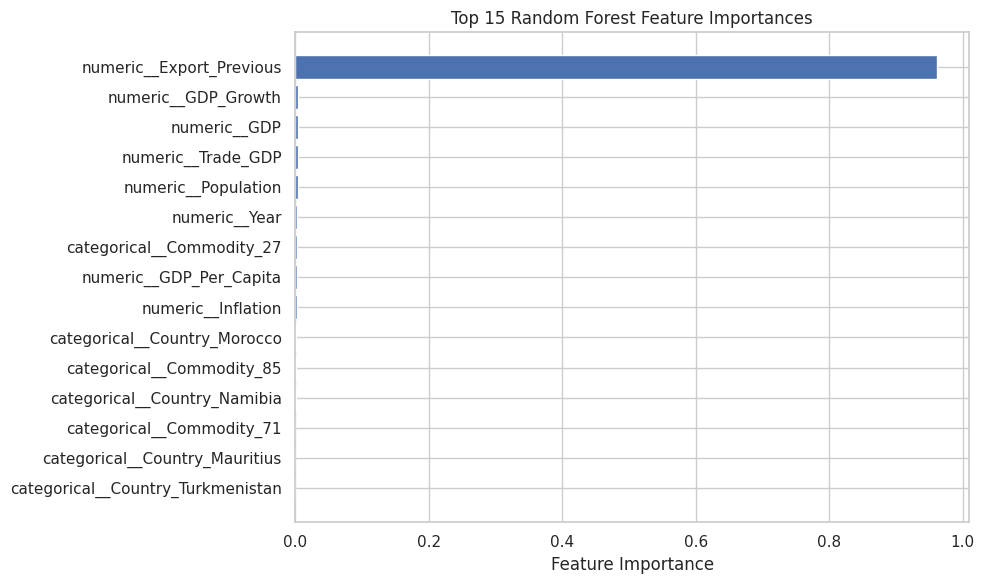

In [215]:
# ==========================================================
# RQ4 RANDOM FOREST FEATURE IMPORTANCE
# ==========================================================

feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

fi = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(fi.head(15))

plt.figure(figsize=(10, 6))

plt.barh(
    fi.head(15)["Feature"][::-1],
    fi.head(15)["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

## RQ4 – Final Insight

**Research Question:**  
Can machine-learning models improve the prediction of export demand compared with a traditional linear regression model?

### Key Findings

Three predictive models were evaluated for export-demand forecasting:

- Linear Regression
- Random Forest
- XGBoost

Model performance was evaluated primarily using **MAE, RMSE, and R² on the log-transformed export-demand target**. Since the models were trained using `log1p(Export_Current)`, log-scale performance provides the primary basis for model comparison.

| Model | MAE (Log) | RMSE (Log) | R² (Log) |
|---|---:|---:|---:|
| Random Forest | 0.3181 | 0.6299 | 0.9224 |
| XGBoost | 0.3267 | 0.6602 | 0.9148 |
| Linear Regression | 0.8036 | 1.0821 | 0.7710 |

### Model Performance

**Random Forest produced the strongest predictive performance** among the evaluated models.

The model achieved:

- **MAE = 0.3181**
- **RMSE = 0.6299**
- **R² = 0.9224**

This indicates that Random Forest explained approximately **92.2% of the variation in log-transformed export demand** in the test data.

XGBoost also performed strongly, achieving an R² of approximately **91.5%**, but its RMSE of 0.6602 was slightly higher than the Random Forest RMSE of 0.6299.

Linear Regression produced substantially weaker predictive performance, with an RMSE of 1.0821 and R² of 0.7710.

### Improvement over the Baseline

Random Forest reduced log-scale RMSE by approximately **41.79% relative to Linear Regression**.

This substantial reduction in prediction error indicates that the relationship between historical exports, macroeconomic characteristics, country, commodity, and future export demand contains nonlinear patterns that are better captured by the machine-learning models.

### Original-Scale Performance

After transforming predictions back to the original export scale, Random Forest continued to provide the strongest overall performance:

- **Random Forest R² = 0.9075**
- **XGBoost R² = 0.8558**

The Linear Regression model performed poorly after inverse transformation, indicating that relatively large errors on the logarithmic scale can become strongly amplified when predictions are converted back to the original export scale.

For this reason, model selection was based primarily on the log-scale metrics on which the models were trained and evaluated.

### Hypothesis Decision

**H0₄:** Machine-learning models do not provide better export-demand prediction than the linear regression baseline.

**Decision: Reject H0₄.**

The results provide evidence that machine-learning models improve predictive performance relative to the linear regression baseline.

Among the evaluated models, **Random Forest was selected as the final predictive model** because it achieved the lowest RMSE and highest R².

### Business Interpretation

The superior performance of Random Forest suggests that export demand is influenced by complex and potentially nonlinear interactions among historical export performance, destination-market characteristics, macroeconomic conditions, commodity characteristics, and time.

A purely linear specification may therefore be insufficient for capturing the full structure of international export demand.

The predictive model can help identify markets where future export demand is expected to remain strong even when historical export performance alone may not fully reveal the opportunity.

### Connection to EMAS

The Random Forest predictions provide the forward-looking component of the Export Market Attractiveness Score (EMAS).

The predicted export-demand values are converted into a normalized **Prediction Score**, which contributes **10% of the final EMAS weighting**.

This allows EMAS to combine historical and current market indicators with a forward-looking estimate of export demand.

The predictive component therefore complements:

- current export demand,
- historical export growth,
- macroeconomic strength,
- destination-market import demand,
- India's market opportunity, and
- competitive market structure.

### Overall Conclusion

RQ4 demonstrates that machine-learning techniques provide a meaningful improvement in export-demand prediction compared with the linear regression baseline.

**Random Forest emerged as the best-performing model**, achieving an R² of 0.9224 and reducing RMSE by approximately 41.79% relative to Linear Regression.

The Random Forest predictions were therefore used as the forward-looking demand component of the final EMAS framework, enabling market attractiveness to incorporate both current market conditions and expected future export demand.

# ==============================================================================
# EXPORT MARKET ATTRACTIVENESS SCORE (EMAS)
# ==============================================================================

The Export Market Attractiveness Score integrates evidence from the four
research questions to identify promising destination–commodity combinations
for Indian MSME exporters.

The framework combines historical export demand and growth (RQ1),
macroeconomic conditions (RQ2), supplier competition and India's existing
market position (RQ3), and predicted export demand from the best-performing
predictive model (RQ4).

The following steps construct the integrated scoring dataset, normalize the
selected indicators, calculate the composite attractiveness score, and assess
the robustness of the resulting market rankings.

### EMAS-Specific Data Preparation

The exploratory and research-question analyses primarily use the observed
trade and macroeconomic variables in their original interpretable form.

Before constructing the Export Market Attractiveness Score (EMAS), additional
transformations are applied specifically for index construction. These
transformations are not intended to alter the underlying historical analysis,
but to ensure that variables with different scales, skewness, and statistical
properties contribute appropriately to the composite score.

In particular, highly skewed size variables are log-transformed, export-growth
outliers are winsorized, and indicators are normalized before weighting.

Export growth requires additional treatment because percentage growth can
become artificially extreme when the previous export value is close to zero.
Markets with missing or very small historical export bases are therefore
assigned a neutral growth contribution in the EMAS calculation rather than
being rewarded for mechanically inflated growth rates.

These transformations are applied only to the construction of the EMAS
indicators; the original variables are retained for descriptive interpretation
and reporting.

In [217]:
# ==============================================================================
# EXPORT MARKET ATTRACTIVENESS SCORE (EMAS)
# STEP 1 - BUILD AND VALIDATE THE COUNTRY × COMMODITY INTEGRATION BASE
#
# Purpose:
# Combine the recent TradeStat/export information with the structural
# competition measures developed under RQ3.
#
# Important:
# RQ3 Comtrade competition measures are based on 2020 data. They are therefore
# treated as structural Destination × Commodity characteristics and merged
# without using Year.
#
# No attractiveness score or weights are calculated in this step.
# ==============================================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------------------------
# 1. CREATE RECENT TRADESTAT COUNTRY × COMMODITY BASE
# ------------------------------------------------------------------------------

# Use the most recent available TradeStat observation for each
# Country × Commodity combination.

emas_base = (
    master[
        master["Export_Current"].notna()
    ]
    .sort_values("Year")
    .groupby(
        ["Country", "Commodity"],
        as_index=False
    )
    .tail(1)
    .copy()
)


# Retain variables potentially required for the final attractiveness model.

emas_base = emas_base[
    [
        "Country",
        "Commodity",
        "Year",
        "Export_Previous",
        "Export_Current",
        "Export_Growth",
        "GDP",
        "GDP_Growth",
        "GDP_Per_Capita",
        "Population",
        "Inflation",
        "Trade_GDP"
    ]
].copy()


# ------------------------------------------------------------------------------
# 2. STANDARDISE COUNTRY NAMES FOR MATCHING
# ------------------------------------------------------------------------------

def clean_country_name(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip().casefold()

    # Remove punctuation commonly causing matching differences
    x = (
        x.replace(".", "")
         .replace(",", "")
         .replace("-", " ")
         .replace("_", " ")
    )

    # Remove repeated spaces
    x = " ".join(x.split())

    return x


emas_base["Country_Key"] = (
    emas_base["Country"]
    .apply(clean_country_name)
)

rq3_market["Country_Key"] = (
    rq3_market["Destination"]
    .apply(clean_country_name)
)


# ------------------------------------------------------------------------------
# 3. APPLY KNOWN COUNTRY-NAME CONCORDANCE
# ------------------------------------------------------------------------------

# TradeStat and UN Comtrade use different naming conventions for several
# countries. These mappings standardise known variants.

country_concordance = {

    "u s a": "united states of america",
    "usa": "united states of america",

    "u arab emts": "united arab emirates",
    "uae": "united arab emirates",

    "u k": "united kingdom",
    "uk": "united kingdom",

    "netherland": "netherlands",

    "china p rp": "china",

    "korea rp": "republic of korea",

    "russia": "russian federation",

    "viet nam": "vietnam",

    "turkey": "türkiye",

    "czech republic": "czechia"
}


emas_base["Country_Key"] = (
    emas_base["Country_Key"]
    .replace(country_concordance)
)

rq3_market["Country_Key"] = (
    rq3_market["Country_Key"]
    .replace(country_concordance)
)


# ------------------------------------------------------------------------------
# 4. STANDARDISE COMMODITY CODE
# ------------------------------------------------------------------------------

emas_base["Commodity"] = (
    emas_base["Commodity"]
    .astype(str)
    .str.strip()
)

rq3_market["Commodity"] = (
    rq3_market["Commodity"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------------------------
# 5. CREATE RQ3 STRUCTURAL COMPETITION TABLE
# ------------------------------------------------------------------------------

rq3_for_merge = rq3_market[
    [
        "Country_Key",
        "Commodity",
        "Total_Imports",
        "India_Imports",
        "India_Market_Share",
        "Supplier_Count",
        "HHI",
        "Competition_Level"
    ]
].copy()


# Check uniqueness before merge

duplicate_check = (
    rq3_for_merge
    .duplicated(
        subset=[
            "Country_Key",
            "Commodity"
        ]
    )
    .sum()
)

print(
    "Duplicate RQ3 Country × Commodity keys:",
    duplicate_check
)


# ------------------------------------------------------------------------------
# 6. MERGE TRADESTAT WITH RQ3
# ------------------------------------------------------------------------------

emas_merged = emas_base.merge(
    rq3_for_merge,
    on=[
        "Country_Key",
        "Commodity"
    ],
    how="left",
    indicator=True
)


# ------------------------------------------------------------------------------
# 7. VALIDATE MATCH RATE
# ------------------------------------------------------------------------------

print("\nTradeStat Country × Commodity rows:")
print(len(emas_base))

print("\nMerge results:")
print(
    emas_merged["_merge"]
    .value_counts()
)

matched = (
    emas_merged["_merge"] == "both"
).sum()

match_rate = (
    matched / len(emas_merged) * 100
)

print(
    f"\nMatched rows: {matched:,}"
)

print(
    f"Match rate: {match_rate:.2f}%"
)


# ------------------------------------------------------------------------------
# 8. INSPECT UNMATCHED COUNTRY NAMES
# ------------------------------------------------------------------------------

unmatched = (
    emas_merged[
        emas_merged["_merge"] == "left_only"
    ][
        [
            "Country",
            "Country_Key",
            "Commodity"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "Country",
            "Commodity"
        ]
    )
)

print(
    "\nNumber of unmatched Country × Commodity combinations:",
    len(unmatched)
)

print("\nSample unmatched records:")

display(
    unmatched.head(50)
)


# ------------------------------------------------------------------------------
# 9. INSPECT SUCCESSFULLY MATCHED RECORDS
# ------------------------------------------------------------------------------

print("\nSample successfully matched records:")

display(
    emas_merged[
        emas_merged["_merge"] == "both"
    ][
        [
            "Country",
            "Commodity",
            "Year",
            "Export_Current",
            "GDP",
            "Total_Imports",
            "India_Market_Share",
            "Supplier_Count",
            "HHI",
            "Competition_Level"
        ]
    ]
    .head(20)
)

Duplicate RQ3 Country × Commodity keys: 0

TradeStat Country × Commodity rows:
1093

Merge results:
_merge
left_only     862
both          231
right_only      0
Name: count, dtype: int64

Matched rows: 231
Match rate: 21.13%

Number of unmatched Country × Commodity combinations: 862

Sample unmatched records:


,Country,Country_Key,Commodity
557,Afghanistan,afghanistan,27
350,Afghanistan,afghanistan,30
226,Afghanistan,afghanistan,71
1053,Afghanistan,afghanistan,84
942,Afghanistan,afghanistan,85
559,Algeria,algeria,27
352,Algeria,algeria,30
228,Algeria,algeria,71
1055,Algeria,algeria,84
944,Algeria,algeria,85



Sample successfully matched records:


,Country,Commodity,Year,Export_Current,GDP,Total_Imports,India_Market_Share,Supplier_Count,HHI,Competition_Level
21,Andorra,84,2023,0.00,3.785067e+09,7.367608e+07,0.001051,55.0,6578.548999,Highly Concentrated
23,Andorra,30,2023,0.01,3.785067e+09,3.718885e+07,0.001986,27.0,6438.215088,Highly Concentrated
24,Dominica,71,2023,0.00,6.593111e+08,1.151114e+05,0.126769,16.0,8324.202034,Highly Concentrated
41,Estonia,27,2024,0.00,4.313042e+10,3.990266e+09,0.000625,47.0,2368.930100,Moderately Concentrated
49,Myanmar,71,2024,0.01,7.406835e+10,1.507431e+06,2.108633,12.0,5833.794493,Highly Concentrated
154,Guatemala,71,2025,0.53,1.233060e+11,2.125734e+07,0.374981,45.0,2539.245264,Highly Concentrated
156,Guyana,71,2025,0.11,2.709748e+10,4.968738e+05,2.394812,14.0,5384.831760,Highly Concentrated
160,Gambia,71,2025,0.00,NaN,3.027776e+03,16.613613,9.0,1595.567800,Moderately Concentrated
161,Georgia,71,2025,0.38,3.814361e+10,5.486874e+06,0.279561,39.0,2009.883006,Moderately Concentrated
162,Germany,71,2025,196.40,5.050923e+12,2.356183e+08,0.000000,53.0,4430.658353,Highly Concentrated


In [218]:
# ==============================================================================
# EMAS - STEP 1A
# DIAGNOSE TRADESTAT × RQ3 MATCH COVERAGE
#
# Purpose:
# Determine whether unmatched observations are caused by:
#   1. Destination not covered by the 2020 Comtrade extraction
#   2. Country-name mismatch
#   3. Commodity not available for an otherwise matched destination
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. UNIQUE COUNTRY COUNTS
# ------------------------------------------------------------------------------

tradestat_countries = set(
    emas_base["Country_Key"].dropna().unique()
)

comtrade_countries = set(
    rq3_for_merge["Country_Key"].dropna().unique()
)

print("TradeStat countries:", len(tradestat_countries))
print("Comtrade/RQ3 countries:", len(comtrade_countries))


# ------------------------------------------------------------------------------
# 2. COUNTRY-LEVEL OVERLAP
# ------------------------------------------------------------------------------

country_overlap = (
    tradestat_countries
    .intersection(comtrade_countries)
)

print(
    "\nCountries appearing in both datasets:",
    len(country_overlap)
)

print(
    "Country-level coverage:",
    f"{len(country_overlap) / len(tradestat_countries) * 100:.2f}%"
)


# ------------------------------------------------------------------------------
# 3. TRADESTAT COUNTRIES NOT PRESENT IN RQ3
# ------------------------------------------------------------------------------

outside_rq3_coverage = (
    emas_base[
        ~emas_base["Country_Key"]
        .isin(comtrade_countries)
    ][
        ["Country", "Country_Key"]
    ]
    .drop_duplicates()
    .sort_values("Country")
)

print(
    "\nTradeStat countries not found in RQ3:",
    len(outside_rq3_coverage)
)

display(
    outside_rq3_coverage.head(100)
)


# ------------------------------------------------------------------------------
# 4. CHECK COUNTRY MATCH BUT COMMODITY MISMATCH
# ------------------------------------------------------------------------------

country_matched_but_pair_missing = (
    emas_merged[
        (emas_merged["_merge"] == "left_only")
        &
        (emas_merged["Country_Key"].isin(comtrade_countries))
    ][
        [
            "Country",
            "Country_Key",
            "Commodity"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["Country", "Commodity"]
    )
)

print(
    "\nCountry matched but Country × Commodity pair missing:",
    len(country_matched_but_pair_missing)
)

display(
    country_matched_but_pair_missing.head(100)
)


# ------------------------------------------------------------------------------
# 5. COVERAGE AMONG RQ3-ELIGIBLE TRADESTAT RECORDS
# ------------------------------------------------------------------------------

eligible = emas_base[
    emas_base["Country_Key"]
    .isin(comtrade_countries)
].copy()

eligible_pairs = len(eligible)

matched_pairs = (
    emas_merged["_merge"] == "both"
).sum()

if eligible_pairs > 0:

    eligible_match_rate = (
        matched_pairs /
        eligible_pairs *
        100
    )

    print(
        "\nTradeStat Country × Commodity pairs "
        "within RQ3-covered countries:",
        eligible_pairs
    )

    print(
        "Successfully matched pairs:",
        matched_pairs
    )

    print(
        "Match rate within RQ3-covered countries:",
        f"{eligible_match_rate:.2f}%"
    )

TradeStat countries: 239
Comtrade/RQ3 countries: 64

Countries appearing in both datasets: 48
Country-level coverage: 20.08%

TradeStat countries not found in RQ3: 191


,Country,Country_Key
3156,Afghanistan,afghanistan
3158,Algeria,algeria
2386,Ameri Samoa,ameri samoa
2172,Anguilla,anguilla
543,Antartica,antartica
...,...,...
102,Montserrat,montserrat
3276,Morocco,morocco
3277,Mozambique,mozambique
467,N. Mariana Is.,n mariana is



Country matched but Country × Commodity pair missing: 3


,Country,Country_Key,Commodity
214,Belarus,belarus,71
472,Germany,germany,27
592,Germany,germany,30



TradeStat Country × Commodity pairs within RQ3-covered countries: 234
Successfully matched pairs: 231
Match rate within RQ3-covered countries: 98.72%


In [219]:
# Check prediction-related objects currently available

prediction_objects = [
    name for name in globals()
    if any(
        term in name.lower()
        for term in ["pred", "random", "forest", "rf"]
    )
]

print("Prediction/model related objects:")
print(prediction_objects)

Prediction/model related objects:
['RandomForestRegressor', 'rq2_predictors', 'predicted', 'rf_result', 'rf_pipeline', 'linear_pred_log', 'linear_pred_original', 'rq3_predictors', 'prediction_objects', 'emas_prediction_data', 'rf_pred_log_emas', 'rf_pred_emas']


In [220]:
print("RQ4 test rows:", len(X_test))
print("Model comparison:")
display(model_comparison)

RQ4 test rows: 1006
Model comparison:


,Model,MAE_Log,RMSE_Log,R2_Log,MAE_Original,RMSE_Original,R2_Original
0,Random Forest,0.318112,0.629911,0.922406,59.030886,291.456362,0.907508
1,XGBoost,0.326742,0.660235,0.914755,65.113578,363.919348,0.855799
2,Linear Regression,0.803612,1.082081,0.771024,19185.387811,579601.443722,-365776.358616


In [221]:
# ==============================================================================
# EMAS - CHECK RANDOM FOREST MODEL AND EXISTING PREDICTIONS
# ==============================================================================

print("rf_pipeline type:")
print(type(rf_pipeline))

print("\nrf_result:")
print(type(rf_result))
print(rf_result)

print("\npredicted type:")
print(type(predicted))

try:
    print("predicted length:", len(predicted))
except:
    print("predicted has no length")

try:
    print("\nFirst 10 predicted values:")
    print(predicted[:10])
except Exception as e:
    print("Could not display predicted values:", e)

print("\nX_test shape:", X_test.shape)
print("X_train shape:", X_train.shape)

print("\nRQ4 feature columns:")
print(X_train.columns.tolist())

rf_pipeline type:
<class 'sklearn.pipeline.Pipeline'>

rf_result:
<class 'dict'>
{'Model': 'Random Forest', 'MAE_Log': 0.31811239281385406, 'RMSE_Log': np.float64(0.6299114891403184), 'R2_Log': 0.9224056511325687, 'MAE_Original': 59.03088645864186, 'RMSE_Original': np.float64(291.45636234600136), 'R2_Original': 0.9075078270396386}

predicted type:
<class 'pandas.core.series.Series'>
predicted length: 2651

First 10 predicted values:
0     2.763150
1     1.946212
2     2.616451
3     2.444425
4     2.800281
5     1.976362
6     3.932750
7     2.845902
8     2.100846
12    2.200928
dtype: float64

X_test shape: (1006, 10)
X_train shape: (3979, 10)

RQ4 feature columns:
['Export_Previous', 'GDP', 'GDP_Growth', 'GDP_Per_Capita', 'Population', 'Inflation', 'Trade_GDP', 'Year', 'Country', 'Commodity']


In [222]:
# ==============================================================================
# EMAS - STEP 2
# GENERATE RANDOM FOREST PREDICTED EXPORT DEMAND
#
# Purpose:
# Use the best-performing RQ4 model (Random Forest) to generate predicted
# export demand for each Country × Commodity observation in the EMAS base.
#
# The model predicts log1p(Export_Current), so predictions are converted
# back to the original export-value scale using expm1().
# ==============================================================================


# ------------------------------------------------------------------------------
# 1. DEFINE RQ4 MODEL FEATURES
# ------------------------------------------------------------------------------

emas_model_features = [
    "Export_Previous",
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP",
    "Year",
    "Country",
    "Commodity"
]


# ------------------------------------------------------------------------------
# 2. PREPARE EMAS PREDICTION DATA
# ------------------------------------------------------------------------------

emas_prediction_data = emas_merged[
    emas_merged["_merge"] == "both"
].copy()

print(
    "RQ3-covered Country × Commodity rows available for EMAS:",
    len(emas_prediction_data)
)




RQ3-covered Country × Commodity rows available for EMAS: 231


In [223]:
# ==============================================================================
# EMAS - STEP 3A
# DIAGNOSE MACROECONOMIC DATA AVAILABILITY
# ==============================================================================

print("=" * 60)
print("WORLD BANK CLEAN DATA")
print("=" * 60)

print("\nShape:")
print(worldbank_clean.shape)

print("\nColumns:")
print(worldbank_clean.columns.tolist())


# ------------------------------------------------------------------------------
# YEAR COVERAGE
# ------------------------------------------------------------------------------

if "Year" in worldbank_clean.columns:

    print("\nWorld Bank year range:")
    print(
        worldbank_clean["Year"].min(),
        "to",
        worldbank_clean["Year"].max()
    )

    print("\nObservations by year:")
    display(
        worldbank_clean["Year"]
        .value_counts()
        .sort_index()
    )


# ------------------------------------------------------------------------------
# MACROECONOMIC COMPLETENESS BY YEAR
# ------------------------------------------------------------------------------

macro_vars = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

if "Year" in worldbank_clean.columns:

    macro_by_year = (
        worldbank_clean
        .groupby("Year")[macro_vars]
        .count()
    )

    print("\nNon-missing macroeconomic observations by year:")

    display(macro_by_year)


# ------------------------------------------------------------------------------
# CHECK EMAS YEARS
# ------------------------------------------------------------------------------

print("\nEMAS candidate observations by TradeStat year:")

display(
    emas_prediction_data["Year"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------------------------
# CHECK MACRO MISSINGNESS BY EMAS YEAR
# ------------------------------------------------------------------------------

macro_missing_by_year = (
    emas_prediction_data
    .groupby("Year")[
        [
            "GDP",
            "GDP_Per_Capita",
            "Population"
        ]
    ]
    .agg(
        [
            "count",
            "size"
        ]
    )
)

print("\nMacro coverage within EMAS candidates:")

display(macro_missing_by_year)


# ------------------------------------------------------------------------------
# COUNTRIES WITH MISSING MACRO DATA
# ------------------------------------------------------------------------------

missing_macro_countries = (
    emas_prediction_data[
        emas_prediction_data[
            [
                "GDP",
                "GDP_Per_Capita",
                "Population"
            ]
        ]
        .isna()
        .any(axis=1)
    ][
        [
            "Country",
            "Country_Key",
            "Year"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["Country", "Year"]
    )
)

print(
    "\nUnique country/year combinations with missing macro data:",
    len(missing_macro_countries)
)

display(
    missing_macro_countries.head(100)
)

WORLD BANK CLEAN DATA

Shape:
(1590, 10)

Columns:
['Country', 'Year', 'Exports_GDP', 'GDP', 'GDP_Growth', 'GDP_Per_Capita', 'Imports_GDP', 'Inflation', 'Population', 'Trade_GDP']

World Bank year range:
2020 to 2025

Observations by year:


,count
Year,
2020,265
2021,265
2022,265
2023,265
2024,265
2025,265



Non-missing macroeconomic observations by year:


,GDP,GDP_Growth,GDP_Per_Capita,Population,Inflation,Trade_GDP
Year,,,,,,
2020,265,265,265,265,265,265
2021,265,265,265,265,265,265
2022,265,265,265,265,265,265
2023,265,265,265,265,265,265
2024,265,265,265,265,265,265
2025,265,265,265,265,265,265



EMAS candidate observations by TradeStat year:


,count
Year,
2023,3
2024,2
2025,44
2026,182



Macro coverage within EMAS candidates:


GDP      GDP_Per_Capita      Population     
     count size          count size      count size
Year                                               
2023     3    3              3    3          3    3
2024     2    2              2    2          2    2
2025    39   44             39   44         40   44
2026     0  182              0  182          0  182


Unique country/year combinations with missing macro data: 52


,Country,Country_Key,Year
351,Albania,albania,2026
354,Angola,angola,2026
323,Argentina,argentina,2026
342,Armenia,armenia,2026
344,Australia,australia,2026
345,Austria,austria,2026
346,Azerbaijan,azerbaijan,2026
209,Bahamas,bahamas,2025
347,Bahamas,bahamas,2026
334,Barbados,barbados,2026


In [224]:
country_concordance.update({
    "bahamas": "bahamas",
    "bahamas the": "bahamas",
    "gambia": "gambia",
    "gambia the": "gambia"
})

In [226]:
# ==============================================================================
# EMAS - STEP 3B
# ATTACH LATEST AVAILABLE MACROECONOMIC DATA
#
# Rule:
# For each TradeStat observation, use the most recent World Bank observation
# available at or before the TradeStat year.
#
# Only World Bank rows with complete values for the three variables required
# for the EMAS Economic Strength component are eligible:
#
#   GDP
#   GDP_Per_Capita
#   Population
#
# Example:
# TradeStat 2026 -> use 2025 if complete.
# If 2025 is incomplete -> search backward to 2024, 2023, etc.
#
# This avoids mean/median imputation while preserving as much of the EMAS
# scoring population as possible.
# ==============================================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------------------------
# 1. START FROM FULL EMAS CANDIDATE POPULATION
# ------------------------------------------------------------------------------

emas_macro = emas_prediction_data.copy()

print(
    "Starting EMAS candidate observations:",
    len(emas_macro)
)


# ------------------------------------------------------------------------------
# 2. REMOVE MACRO VARIABLES INHERITED FROM EARLIER EXACT-YEAR MERGE
# ------------------------------------------------------------------------------

macro_vars = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

emas_macro = emas_macro.drop(
    columns=macro_vars,
    errors="ignore"
)


# ------------------------------------------------------------------------------
# 3. PREPARE WORLD BANK DATA
# ------------------------------------------------------------------------------

wb_emas = worldbank_clean.copy()


# Apply the same country-name standardization used in the EMAS integration.

wb_emas["Country_Key"] = (
    wb_emas["Country"]
    .apply(clean_country_name)
    .replace(country_concordance)
)


# Rename variables so TradeStat year and World Bank year remain distinguishable.

wb_emas = wb_emas.rename(
    columns={
        "Country": "WB_Country",
        "Year": "Macro_Year"
    }
)


# ------------------------------------------------------------------------------
# 4. CONVERT WORLD BANK MACRO VARIABLES TO NUMERIC
# ------------------------------------------------------------------------------

# World Bank files use markers such as ".." for unavailable observations.
# These are converted to NaN before identifying usable macroeconomic years.

macro_columns = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

for col in macro_columns:

    wb_emas[col] = pd.to_numeric(
        wb_emas[col],
        errors="coerce"
    )


# ------------------------------------------------------------------------------
# 5. DEFINE MACRO VARIABLES REQUIRED FOR EMAS
# ------------------------------------------------------------------------------

# The Economic Strength component of EMAS uses:
#
#   GDP
#   GDP per capita
#   Population
#
# Inflation, GDP Growth and Trade_GDP are retained for reference but are not
# required for an observation to remain eligible for the final EMAS score.

required_emas_macro = [
    "GDP",
    "GDP_Per_Capita",
    "Population"
]

wb_emas["EMAS_Macro_Complete"] = (
    wb_emas[
        required_emas_macro
    ]
    .notna()
    .all(axis=1)
)


# ------------------------------------------------------------------------------
# 6. RETAIN ONLY COMPLETE WORLD BANK COUNTRY-YEAR RECORDS
# ------------------------------------------------------------------------------

wb_emas_complete = wb_emas[
    wb_emas["EMAS_Macro_Complete"]
].copy()

print(
    "\nComplete World Bank country-year records available for EMAS:",
    len(wb_emas_complete)
)


# ------------------------------------------------------------------------------
# 7. PREPARE YEARS FOR AS-OF MERGE
# ------------------------------------------------------------------------------

emas_macro["Year"] = pd.to_numeric(
    emas_macro["Year"],
    errors="coerce"
)

wb_emas_complete["Macro_Year"] = pd.to_numeric(
    wb_emas_complete["Macro_Year"],
    errors="coerce"
)


# Remove records lacking the fields required for matching.

emas_macro = emas_macro.dropna(
    subset=[
        "Year",
        "Country_Key"
    ]
).copy()

wb_emas_complete = wb_emas_complete.dropna(
    subset=[
        "Macro_Year",
        "Country_Key"
    ]
).copy()


# Convert years to integers.

emas_macro["Year"] = (
    emas_macro["Year"]
    .astype(int)
)

wb_emas_complete["Macro_Year"] = (
    wb_emas_complete["Macro_Year"]
    .astype(int)
)


# ------------------------------------------------------------------------------
# 8. SORT DATA FOR MERGE_ASOF
# ------------------------------------------------------------------------------

# merge_asof requires the merge key to be sorted.

emas_macro = (
    emas_macro
    .sort_values(
        [
            "Year",
            "Country_Key"
        ]
    )
    .reset_index(drop=True)
)

wb_emas_complete = (
    wb_emas_complete
    .sort_values(
        [
            "Macro_Year",
            "Country_Key"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------------------
# 9. MERGE LATEST AVAILABLE COMPLETE MACRO DATA
# ------------------------------------------------------------------------------

# For each EMAS record, merge_asof selects the closest World Bank year that:
#
#   - belongs to the same country, and
#   - is less than or equal to the TradeStat year.
#
# Because only complete macroeconomic rows are retained above, an incomplete
# 2025 World Bank observation will automatically cause the procedure to search
# backward to the latest complete year.

emas_macro = pd.merge_asof(
    emas_macro,
    wb_emas_complete,
    left_on="Year",
    right_on="Macro_Year",
    by="Country_Key",
    direction="backward"
)


# ------------------------------------------------------------------------------
# 10. RESTORE READABLE COUNTRY × COMMODITY ORDER
# ------------------------------------------------------------------------------

emas_macro = (
    emas_macro
    .sort_values(
        [
            "Country",
            "Commodity"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------------------
# 11. VALIDATE MACRO YEAR USAGE
# ------------------------------------------------------------------------------

print(
    "\nEMAS rows after latest-complete macro merge:",
    len(emas_macro)
)

print(
    "\nTrade year vs macro year:"
)

display(
    emas_macro[
        [
            "Year",
            "Macro_Year"
        ]
    ]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)


# ------------------------------------------------------------------------------
# 12. CHECK REQUIRED EMAS MACRO MISSINGNESS
# ------------------------------------------------------------------------------

print(
    "\nMissing required EMAS macroeconomic values:"
)

display(
    emas_macro[
        required_emas_macro
    ]
    .isna()
    .sum()
    .to_frame("Missing")
)


# ------------------------------------------------------------------------------
# 13. CHECK OPTIONAL MACRO VARIABLES
# ------------------------------------------------------------------------------

# These variables are not currently required for the EMAS composite score,
# but their missingness is shown for transparency.

optional_macro = [
    "GDP_Growth",
    "Inflation",
    "Trade_GDP"
]

print(
    "\nMissing optional macroeconomic values:"
)

display(
    emas_macro[
        optional_macro
    ]
    .isna()
    .sum()
    .to_frame("Missing")
)


# ------------------------------------------------------------------------------
# 14. CHECK COUNTRY MATCHING FAILURES
# ------------------------------------------------------------------------------

macro_unmatched = (
    emas_macro[
        emas_macro["Macro_Year"].isna()
    ][
        [
            "Country",
            "Country_Key",
            "Year"
        ]
    ]
    .drop_duplicates()
)

print(
    "\nRows with no usable World Bank macro match:",
    len(macro_unmatched)
)

if len(macro_unmatched) > 0:

    display(
        macro_unmatched
        .sort_values("Country")
    )


# ------------------------------------------------------------------------------
# 15. CHECK EXPORT GROWTH MISSINGNESS
# ------------------------------------------------------------------------------

growth_missing = (
    emas_macro[
        emas_macro["Export_Growth"].isna()
    ][
        [
            "Country",
            "Commodity",
            "Year",
            "Export_Previous",
            "Export_Current",
            "Export_Growth"
        ]
    ]
    .copy()
)

print(
    "\nRows with undefined Export_Growth:",
    len(growth_missing)
)

if len(growth_missing) > 0:

    display(growth_missing)


# ------------------------------------------------------------------------------
# 16. CHECK EMAS COVERAGE BEFORE RANDOM FOREST PREDICTION
# ------------------------------------------------------------------------------

# Export_Growth is intentionally excluded because undefined growth will later
# receive a neutral normalized Growth Score of 0.5.
#
# Predicted_Export_Demand is also excluded here because it is generated only
# after the finalized latest-available macroeconomic data have been attached.

required_before_prediction = [
    "Export_Current",
    "GDP",
    "GDP_Per_Capita",
    "Population",
    "Total_Imports",
    "India_Market_Share",
    "HHI"
]

emas_complete_check = (
    emas_macro
    .dropna(
        subset=required_before_prediction
    )
)

print(
    "\nObservations available before RF prediction:",
    len(emas_complete_check)
)

print(
    "Coverage of original EMAS candidates:",
    f"{len(emas_complete_check) / len(emas_prediction_data) * 100:.2f}%"
)

Starting EMAS candidate observations: 231

Complete World Bank country-year records available for EMAS: 1501

EMAS rows after latest-complete macro merge: 231

Trade year vs macro year:


Count
Year Macro_Year       
2023 2023            3
2024 2024            2
2025 2024            2
     2025           42
2026 2020            4
     2024            7
     2025          171


Missing required EMAS macroeconomic values:


,Missing
GDP,0
GDP_Per_Capita,0
Population,0



Missing optional macroeconomic values:


,Missing
GDP_Growth,0
Inflation,26
Trade_GDP,36



Rows with no usable World Bank macro match: 0

Rows with undefined Export_Growth: 5


,Country,Commodity,Year,Export_Previous,Export_Current,Export_Growth
0,Albania,27,2026,NaN,0.01,NaN
43,Barbados,27,2026,NaN,0.04,NaN
160,Dominica,71,2023,NaN,0.00,NaN
173,Estonia,27,2024,NaN,0.00,NaN
195,Gabon,71,2025,NaN,0.00,NaN



Observations available before RF prediction: 231
Coverage of original EMAS candidates: 100.00%


In [227]:
# ==============================================================================
# EMAS - PREDICTION AFTER STEP 3B
# GENERATE RANDOM FOREST PREDICTIONS USING FINAL MACRO DATA
# ==============================================================================

rf_pred_log_emas = rf_pipeline.predict(
    emas_macro[emas_model_features]
)

rf_pred_emas = np.expm1(
    rf_pred_log_emas
)

rf_pred_emas = np.clip(
    rf_pred_emas,
    0,
    None
)

emas_macro["Predicted_Export_Demand"] = rf_pred_emas


print("\nPredicted export demand summary:")

display(
    emas_macro[
        "Predicted_Export_Demand"
    ].describe()
)


print("\nPrediction range:")

print(
    "Minimum:",
    emas_macro[
        "Predicted_Export_Demand"
    ].min()
)

print(
    "Maximum:",
    emas_macro[
        "Predicted_Export_Demand"
    ].max()
)


display(
    emas_macro[
        [
            "Country",
            "Commodity",
            "Year",
            "Export_Previous",
            "Export_Current",
            "Predicted_Export_Demand",
            "Total_Imports",
            "India_Market_Share",
            "HHI"
        ]
    ]
    .sort_values(
        "Predicted_Export_Demand",
        ascending=False
    )
    .head(20)
)


Predicted export demand summary:


,Predicted_Export_Demand
count,231.000000
mean,116.006163
std,310.072674
min,0.008720
25%,0.843682
50%,8.698691
75%,47.819115
max,2634.047702



Prediction range:
Minimum: 0.008719558649672797
Maximum: 2634.0477018455617


,Country,Commodity,Year,Export_Previous,Export_Current,Predicted_Export_Demand,Total_Imports,India_Market_Share,HHI
23,Australia,27,2026,4486.17,2712.91,2634.047702,1.669554e+10,5.811561,1092.408187
210,Germany,85,2026,1637.22,1794.47,1422.547595,2.901623e+11,0.630841,1007.067330
118,China P Rp,84,2026,1160.94,1263.12,1412.892245,1.727550e+11,0.501756,1062.968347
209,Germany,84,2026,1377.87,1463.83,1338.431607,2.981267e+11,0.624691,758.588077
115,China P Rp,27,2026,1269.24,2462.26,1332.578108,2.732683e+11,0.059229,573.447906
54,Belgium,71,2025,1608.40,1608.67,1262.978932,1.390556e+10,9.615641,670.957352
188,France,27,2026,1144.95,198.27,1144.076139,8.283306e+10,1.354461,732.746410
153,Czech Republic,85,2026,1264.81,522.40,1115.605822,7.414331e+10,0.613863,1952.780433
32,Austria,85,2026,1058.72,928.07,975.658103,1.646176e+10,0.676796,1338.795023
192,France,85,2026,920.77,989.45,858.032662,1.044642e+11,0.910743,1165.163168


In [228]:
# ==============================================================================
# EMAS - STEP 3C
# AUDIT REMAINING INCOMPLETE OBSERVATIONS
# ==============================================================================

final_required = [
    "Export_Current",
    "Export_Growth",
    "GDP",
    "GDP_Per_Capita",
    "Population",
    "Total_Imports",
    "India_Market_Share",
    "HHI",
    "Predicted_Export_Demand"
]

# Identify rows missing at least one required EMAS variable
incomplete_emas = emas_macro[
    emas_macro[final_required]
    .isna()
    .any(axis=1)
].copy()

print("Incomplete EMAS observations:", len(incomplete_emas))

# Missingness by variable
print("\nMissing values among incomplete observations:")

display(
    incomplete_emas[final_required]
    .isna()
    .sum()
    .to_frame("Missing")
)

# Show exactly which variables are missing in each row
incomplete_emas["Missing_Variables"] = (
    incomplete_emas[final_required]
    .isna()
    .apply(
        lambda row: ", ".join(
            row.index[row].tolist()
        ),
        axis=1
    )
)

print("\nIncomplete Country × Commodity observations:")

display(
    incomplete_emas[
        [
            "Country",
            "Commodity",
            "Year",
            "Macro_Year",
            "Export_Current",
            "Export_Growth",
            "GDP",
            "GDP_Per_Capita",
            "Population",
            "Missing_Variables"
        ]
    ]
    .sort_values(["Country", "Commodity"])
)


# Country-level World Bank failures
print("\nCountries with macroeconomic missingness:")

display(
    incomplete_emas[
        incomplete_emas[
            [
                "GDP",
                "GDP_Per_Capita",
                "Population"
            ]
        ]
        .isna()
        .any(axis=1)
    ][
        [
            "Country",
            "Country_Key",
            "Year",
            "Macro_Year"
        ]
    ]
    .drop_duplicates()
    .sort_values(["Country", "Year"])
)

Incomplete EMAS observations: 5

Missing values among incomplete observations:


,Missing
Export_Current,0
Export_Growth,5
GDP,0
GDP_Per_Capita,0
Population,0
Total_Imports,0
India_Market_Share,0
HHI,0
Predicted_Export_Demand,0



Incomplete Country × Commodity observations:


,Country,Commodity,Year,Macro_Year,Export_Current,Export_Growth,GDP,GDP_Per_Capita,Population,Missing_Variables
0,Albania,27,2026,2025,0.01,NaN,3.054019e+10,12998.147870,2349580.0,Export_Growth
43,Barbados,27,2026,2025,0.04,NaN,8.016550e+09,28364.818150,282623.0,Export_Growth
160,Dominica,71,2023,2023,0.00,NaN,6.593111e+08,9912.962128,66510.0,Export_Growth
173,Estonia,27,2024,2024,0.00,NaN,4.313042e+10,31428.354782,1372341.0,Export_Growth
195,Gabon,71,2025,2025,0.00,NaN,2.142712e+10,8263.033216,2593130.0,Export_Growth



Countries with macroeconomic missingness:


,Country,Country_Key,Year,Macro_Year


In [229]:
# ==============================================================================
# EMAS - STEP 3D
# AUDIT NON-NUMERIC MACROECONOMIC VALUES
# ==============================================================================

macro_vars = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

for col in macro_vars:

    numeric_version = pd.to_numeric(
        emas_macro[col],
        errors="coerce"
    )

    bad_mask = (
        emas_macro[col].notna()
        & numeric_version.isna()
    )

    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print("Non-numeric observations:", bad_mask.sum())

    if bad_mask.sum() > 0:
        display(
            emas_macro.loc[
                bad_mask,
                [
                    "Country",
                    "Commodity",
                    "Year",
                    "Macro_Year",
                    col
                ]
            ]
            .drop_duplicates()
            .head(50)
        )


GDP
Non-numeric observations: 0

GDP_Growth
Non-numeric observations: 0

GDP_Per_Capita
Non-numeric observations: 0

Population
Non-numeric observations: 0

Inflation
Non-numeric observations: 0

Trade_GDP
Non-numeric observations: 0


In [230]:
# ==============================================================================
# PREPARE WORLD BANK DATA FOR EMAS
# ==============================================================================

wb_emas = worldbank_clean.copy()

wb_emas["Country_Key"] = (
    wb_emas["Country"]
    .apply(clean_country_name)
    .replace(country_concordance)
)

wb_emas = wb_emas.rename(
    columns={
        "Country": "WB_Country",
        "Year": "Macro_Year"
    }
)

macro_columns = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

# Convert World Bank ".." and other non-numeric markers to NaN
for col in macro_columns:
    wb_emas[col] = pd.to_numeric(
        wb_emas[col],
        errors="coerce"
    )

In [231]:
# Required variables for the EMAS economic-strength component
required_emas_macro = [
    "GDP",
    "GDP_Per_Capita",
    "Population"
]

wb_emas["EMAS_Macro_Complete"] = (
    wb_emas[required_emas_macro]
    .notna()
    .all(axis=1)
)

In [232]:
# ==============================================================================
# EMAS - STEP 4
# FINAL INDICATOR PREPARATION AND NORMALIZATION
# ==============================================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------------------------
# 1. START FROM FINAL 231-ROW EMAS DATASET
# ------------------------------------------------------------------------------

emas = emas_macro.copy()

print("Starting EMAS observations:", len(emas))


# ------------------------------------------------------------------------------
# 2. ENSURE SCORING VARIABLES ARE NUMERIC
# ------------------------------------------------------------------------------

numeric_variables = [
    "Export_Current",
    "Export_Growth",
    "GDP",
    "GDP_Per_Capita",
    "Population",
    "Total_Imports",
    "India_Market_Share",
    "HHI",
    "Predicted_Export_Demand"
]

for col in numeric_variables:
    emas[col] = pd.to_numeric(
        emas[col],
        errors="coerce"
    )


# ------------------------------------------------------------------------------
# 3. WINSORIZE AVAILABLE EXPORT GROWTH
# ------------------------------------------------------------------------------

growth_lower = emas["Export_Growth"].quantile(0.05)
growth_upper = emas["Export_Growth"].quantile(0.95)

emas["Export_Growth_Capped"] = (
    emas["Export_Growth"]
    .clip(
        lower=growth_lower,
        upper=growth_upper
    )
)

print(
    "Export growth winsorization bounds:",
    round(growth_lower, 2),
    "to",
    round(growth_upper, 2)
)


# ------------------------------------------------------------------------------
# 4. LOG-TRANSFORM HIGHLY SKEWED SIZE VARIABLES
# ------------------------------------------------------------------------------

emas["Log_Export_Current"] = np.log1p(
    emas["Export_Current"].clip(lower=0)
)

emas["Log_Total_Imports"] = np.log1p(
    emas["Total_Imports"].clip(lower=0)
)

emas["Log_Predicted_Export"] = np.log1p(
    emas["Predicted_Export_Demand"].clip(lower=0)
)

emas["Log_GDP"] = np.log1p(
    emas["GDP"].clip(lower=0)
)

emas["Log_GDP_Per_Capita"] = np.log1p(
    emas["GDP_Per_Capita"].clip(lower=0)
)

emas["Log_Population"] = np.log1p(
    emas["Population"].clip(lower=0)
)


# ------------------------------------------------------------------------------
# 5. MIN-MAX NORMALIZATION FUNCTION
# ------------------------------------------------------------------------------

def minmax(series):

    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.5,
            index=series.index
        )

    return (
        (series - minimum)
        /
        (maximum - minimum)
    )


# ------------------------------------------------------------------------------
# 6. HISTORICAL EXPORT DEMAND SCORE
# ------------------------------------------------------------------------------

emas["Export_Demand_Score"] = minmax(
    emas["Log_Export_Current"]
)


# ------------------------------------------------------------------------------
# 7. EXPORT GROWTH SCORE
# ------------------------------------------------------------------------------

# First create the score from available growth observations.

emas["Growth_Score"] = minmax(
    emas["Export_Growth_Capped"]
)

# Five markets have undefined growth because Export_Previous is unavailable.
# They receive a neutral normalized contribution rather than being dropped.

emas["Growth_Score"] = (
    emas["Growth_Score"]
    .fillna(0.5)
)


# ------------------------------------------------------------------------------
# 7A. ADJUST FOR SMALL EXPORT-BASE EFFECTS
# ------------------------------------------------------------------------------

# Percentage growth can become artificially large when the previous export
# value is extremely small. The bottom 5% of positive previous export values
# are treated as an unreliable base for interpreting percentage growth.

positive_export_base = emas.loc[
    emas["Export_Previous"] > 0,
    "Export_Previous"
]

growth_base_threshold = (
    positive_export_base
    .quantile(0.05)
)

print(
    "\nMinimum export base threshold for reliable growth:",
    round(growth_base_threshold, 4)
)

# Flag observations with missing or very small previous export values.

emas["Small_Export_Base"] = (
    emas["Export_Previous"].isna()
    |
    (
        emas["Export_Previous"]
        <= growth_base_threshold
    )
)

# Give these observations a neutral growth contribution.

emas.loc[
    emas["Small_Export_Base"],
    "Growth_Score"
] = 0.5

print(
    "Observations receiving neutral growth score:",
    emas["Small_Export_Base"].sum()
)


# ------------------------------------------------------------------------------
# 8. ECONOMIC STRENGTH SCORE
# ------------------------------------------------------------------------------

emas["GDP_Score"] = minmax(
    emas["Log_GDP"]
)

emas["GDP_PC_Score"] = minmax(
    emas["Log_GDP_Per_Capita"]
)

emas["Population_Score"] = minmax(
    emas["Log_Population"]
)

# Equal weighting within the macroeconomic dimension.

emas["Economic_Strength_Score"] = (
    emas[
        [
            "GDP_Score",
            "GDP_PC_Score",
            "Population_Score"
        ]
    ]
    .mean(axis=1)
)


# ------------------------------------------------------------------------------
# 9. DESTINATION IMPORT-DEMAND SCORE
# ------------------------------------------------------------------------------

emas["Import_Demand_Score"] = minmax(
    emas["Log_Total_Imports"]
)


# ------------------------------------------------------------------------------
# 10. INDIA MARKET-SHARE OPPORTUNITY SCORE
# ------------------------------------------------------------------------------

# Lower existing Indian market share means greater room for expansion.
#
# A reverse percentile rank is used because India market share is highly
# right-skewed and raw min-max scaling previously compressed most markets
# close to a score of 1.

emas["India_Opportunity_Score"] = (
    1
    -
    emas["India_Market_Share"]
    .rank(
        method="average",
        pct=True
    )
)


# ------------------------------------------------------------------------------
# 11. COMPETITION SCORE
# ------------------------------------------------------------------------------

# Lower HHI indicates a less concentrated supplier structure and therefore
# receives a higher opportunity score.

emas["Competition_Score"] = (
    1 - minmax(
        emas["HHI"]
    )
)


# ------------------------------------------------------------------------------
# 12. PREDICTED EXPORT-DEMAND SCORE
# ------------------------------------------------------------------------------

emas["Prediction_Score"] = minmax(
    emas["Log_Predicted_Export"]
)


# ------------------------------------------------------------------------------
# 13. VALIDATE FINAL NORMALIZED INDICATORS
# ------------------------------------------------------------------------------

score_columns = [
    "Export_Demand_Score",
    "Growth_Score",
    "Economic_Strength_Score",
    "Import_Demand_Score",
    "India_Opportunity_Score",
    "Competition_Score",
    "Prediction_Score"
]

print("\nFinal normalized score summary:")

display(
    emas[
        score_columns
    ]
    .describe()
    .T
    .round(4)
)


print("\nMissing normalized scores:")

display(
    emas[
        score_columns
    ]
    .isna()
    .sum()
    .to_frame("Missing")
)


print(
    "\nFinal EMAS scoring observations:",
    len(emas)
)

print(
    "Missing-growth observations assigned neutral score:",
    emas["Export_Growth"].isna().sum()
)

print(
    "Total observations neutralized for missing/small export base:",
    emas["Small_Export_Base"].sum()
)

Starting EMAS observations: 231
Export growth winsorization bounds: -67.11 to 592.01

Minimum export base threshold for reliable growth: 0.03
Observations receiving neutral growth score: 26

Final normalized score summary:


,count,mean,std,min,25%,50%,75%,max
Export_Demand_Score,231.0,0.3114,0.2692,0.0000,0.0571,0.2629,0.5032,1.0000
Growth_Score,231.0,0.2053,0.2125,0.0000,0.0884,0.1253,0.2480,1.0000
Economic_Strength_Score,231.0,0.5188,0.1543,0.1957,0.4305,0.5054,0.6286,0.8789
Import_Demand_Score,231.0,0.6530,0.1689,0.0000,0.5552,0.6744,0.7631,1.0000
India_Opportunity_Score,231.0,0.4978,0.2893,0.0000,0.2489,0.4978,0.7468,0.9870
Competition_Score,231.0,0.7660,0.2269,0.0000,0.6599,0.8515,0.9322,1.0000
Prediction_Score,231.0,0.3214,0.2677,0.0000,0.0766,0.2877,0.4931,1.0000



Missing normalized scores:


,Missing
Export_Demand_Score,0
Growth_Score,0
Economic_Strength_Score,0
Import_Demand_Score,0
India_Opportunity_Score,0
Competition_Score,0
Prediction_Score,0



Final EMAS scoring observations: 231
Missing-growth observations assigned neutral score: 5
Total observations neutralized for missing/small export base: 26


In [233]:
# ==============================================================================
# EMAS - STEP 5
# CHECK REDUNDANCY AMONG NORMALIZED SCORE COMPONENTS
#
# Purpose:
# Examine correlations among the seven normalized EMAS dimensions before
# assigning composite weights. Strong correlations may indicate that closely
# related information would be double-counted in the final attractiveness score.
# ==============================================================================

score_columns = [
    "Export_Demand_Score",
    "Growth_Score",
    "Economic_Strength_Score",
    "Import_Demand_Score",
    "India_Opportunity_Score",
    "Competition_Score",
    "Prediction_Score"
]

emas_score_corr = (
    emas[score_columns]
    .corr()
    .round(3)
)

print("Correlation matrix among EMAS components:")

display(emas_score_corr)


# ------------------------------------------------------------------------------
# IDENTIFY HIGH CORRELATIONS
# ------------------------------------------------------------------------------

high_corr_pairs = []

for i in range(len(score_columns)):
    for j in range(i + 1, len(score_columns)):

        corr_value = emas_score_corr.iloc[i, j]

        if abs(corr_value) >= 0.70:

            high_corr_pairs.append({
                "Variable_1": score_columns[i],
                "Variable_2": score_columns[j],
                "Correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

print("\nComponent pairs with |correlation| >= 0.70:")

if len(high_corr_df) > 0:
    display(high_corr_df)
else:
    print("No component pairs exceed the 0.70 threshold.")

Correlation matrix among EMAS components:


,Export_Demand_Score,Growth_Score,Economic_Strength_Score,Import_Demand_Score,India_Opportunity_Score,Competition_Score,Prediction_Score
Export_Demand_Score,1.000,-0.302,0.644,0.665,-0.331,0.411,0.974
Growth_Score,-0.302,1.000,-0.235,-0.338,0.227,-0.276,-0.411
Economic_Strength_Score,0.644,-0.235,1.000,0.778,0.107,0.399,0.655
Import_Demand_Score,0.665,-0.338,0.778,1.000,0.140,0.401,0.682
India_Opportunity_Score,-0.331,0.227,0.107,0.140,1.000,-0.317,-0.308
Competition_Score,0.411,-0.276,0.399,0.401,-0.317,1.000,0.402
Prediction_Score,0.974,-0.411,0.655,0.682,-0.308,0.402,1.000



Component pairs with |correlation| >= 0.70:


,Variable_1,Variable_2,Correlation
0,Export_Demand_Score,Prediction_Score,0.974
1,Economic_Strength_Score,Import_Demand_Score,0.778


In [242]:
# ==============================================================================
# EMAS - STEP 5A
# CONSOLIDATE HIGHLY CORRELATED EXPORT PERFORMANCE INDICATORS
# ==============================================================================

# Export_Demand_Score and Prediction_Score show very high correlation.
# They are consolidated to reduce double-counting while preserving the
# original relative weighting:
#
# Export Demand = 0.15 / 0.25 = 60%
# Prediction    = 0.10 / 0.25 = 40%

emas["Export_Performance_Score"] = (
    0.60 * emas["Export_Demand_Score"]
    +
    0.40 * emas["Prediction_Score"]
)

print("Export Performance Score summary:")

display(
    emas["Export_Performance_Score"]
    .describe()
    .to_frame()
    .round(4)
)

print(
    "\nMissing Export Performance Scores:",
    emas["Export_Performance_Score"].isna().sum()
)

Export Performance Score summary:


,Export_Performance_Score
count,231.0000
mean,0.3154
std,0.2670
min,0.0000
25%,0.0666
50%,0.2791
75%,0.4992
max,0.9882



Missing Export Performance Scores: 0


In [243]:
# ==============================================================================
# EMAS - STEP 6
# FINAL EMAS SCORE, ATTRACTIVENESS CLASSIFICATION AND MARKET RANKING
# ==============================================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------------------------
# 1. DEFINE FINAL EMAS WEIGHTS
# ------------------------------------------------------------------------------

# Weights sum to 1.00.
#
# Historical export demand and predicted export demand are highly correlated,
# so their combined influence is deliberately limited.
#
# Import demand receives the largest individual weight because EMAS is designed
# to identify destination-market attractiveness.

emas_weights = {
    "Export_Performance_Score":  0.25,
    "Growth_Score":              0.10,
    "Economic_Strength_Score":   0.15,
    "Import_Demand_Score":       0.20,
    "India_Opportunity_Score":   0.15,
    "Competition_Score":         0.15
}


# ------------------------------------------------------------------------------
# 2. VALIDATE WEIGHTS
# ------------------------------------------------------------------------------

total_weight = sum(emas_weights.values())

print(
    "Total EMAS weight:",
    round(total_weight, 4)
)

assert np.isclose(
    total_weight,
    1.0
), "EMAS weights must sum to 1."


# ------------------------------------------------------------------------------
# 3. CALCULATE FINAL EMAS SCORE
# ------------------------------------------------------------------------------

emas["EMAS"] = sum(
    emas[variable] * weight
    for variable, weight in emas_weights.items()
)

# Convert to an intuitive 0-100 scale.

emas["EMAS_100"] = (
    emas["EMAS"] * 100
)


# ------------------------------------------------------------------------------
# 4. RANK ALL COUNTRY × COMMODITY OPPORTUNITIES
# ------------------------------------------------------------------------------

emas["EMAS_Rank"] = (
    emas["EMAS"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


# ------------------------------------------------------------------------------
# 5. CREATE ATTRACTIVENESS CATEGORIES
# ------------------------------------------------------------------------------

# Quartile-based categories provide relative classifications across the
# evaluated market opportunities.

emas["EMAS_Category"] = pd.qcut(
    emas["EMAS"],
    q=4,
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)


# ------------------------------------------------------------------------------
# 6. VALIDATE FINAL SCORE DISTRIBUTION
# ------------------------------------------------------------------------------

print("\nEMAS score summary:")

display(
    emas[
        [
            "EMAS",
            "EMAS_100"
        ]
    ]
    .describe()
    .T
    .round(4)
)


print("\nEMAS attractiveness categories:")

display(
    emas["EMAS_Category"]
    .value_counts()
    .to_frame("Count")
)


# ------------------------------------------------------------------------------
# 7. CREATE FINAL RANKED DATASET
# ------------------------------------------------------------------------------

emas_ranked = (
    emas
    .sort_values(
        "EMAS",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------------------
# 8. TOP 20 EXPORT MARKET OPPORTUNITIES
# ------------------------------------------------------------------------------

top20_emas = (
    emas_ranked
    .head(20)
)

print("\nTop 20 Export Market Opportunities:")

display(
    top20_emas[
        [
            "Country",
            "Commodity",
            "Year",
            "EMAS_100",
            "EMAS_Rank",
            "EMAS_Category",
            "Export_Current",
            "Export_Growth",
            "Total_Imports",
            "India_Market_Share",
            "HHI",
            "Predicted_Export_Demand"
        ]
    ]
    .round(3)
)


# ------------------------------------------------------------------------------
# 9. TOP 5 MARKETS WITHIN EACH COMMODITY
# ------------------------------------------------------------------------------

top5_by_commodity = (
    emas
    .sort_values(
        "EMAS",
        ascending=False
    )
    .groupby(
        "Commodity",
        group_keys=False
    )
    .head(5)
    .sort_values(
        [
            "Commodity",
            "EMAS"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("\nTop 5 Markets by Commodity:")

display(
    top5_by_commodity[
        [
            "Commodity",
            "Country",
            "EMAS_100",
            "EMAS_Rank",
            "EMAS_Category"
        ]
    ]
    .round(3)
)


# ------------------------------------------------------------------------------
# 10. DISPLAY COMPONENT SCORES FOR TOP 20
# ------------------------------------------------------------------------------

print(
    "\nEMAS component scores for Top 20 markets:"
)

display(
    top20_emas[
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "Export_Demand_Score",
            "Growth_Score",
            "Economic_Strength_Score",
            "Import_Demand_Score",
            "India_Opportunity_Score",
            "Competition_Score",
            "Prediction_Score"
        ]
    ]
    .round(3)
)

Total EMAS weight: 1.0

EMAS score summary:


,count,mean,std,min,25%,50%,75%,max
EMAS,231.0,0.4974,0.1243,0.1373,0.4124,0.4889,0.5794,0.8710
EMAS_100,231.0,49.7382,12.4283,13.7264,41.2431,48.8946,57.9386,87.1032



EMAS attractiveness categories:


,Count
EMAS_Category,
Low,58
Moderate,58
Very High,58
High,57



Top 20 Export Market Opportunities:


,Country,Commodity,Year,EMAS_100,EMAS_Rank,EMAS_Category,Export_Current,Export_Growth,Total_Imports,India_Market_Share,HHI,Predicted_Export_Demand
0,China P Rp,85,2026,87.103,1,Very High,3178.29,277.19,4.089756e+11,0.190,1318.935,774.205
1,China P Rp,27,2026,86.713,2,Very High,2462.26,93.99,2.732683e+11,0.059,573.448,1332.578
2,China P Rp,84,2026,78.793,3,Very High,1263.12,8.80,1.727550e+11,0.502,1062.968,1412.892
3,Germany,84,2026,77.961,4,Very High,1463.83,6.24,2.981267e+11,0.625,758.588,1338.432
4,Germany,85,2026,77.895,5,Very High,1794.47,9.60,2.901623e+11,0.631,1007.067,1422.548
5,France,84,2026,75.142,6,Very High,810.81,16.38,1.406807e+11,0.594,898.631,729.861
6,France,85,2026,73.261,7,Very High,989.45,7.46,1.044642e+11,0.911,1165.163,858.033
7,Belgium,30,2026,72.954,8,Very High,368.05,8.29,3.688774e+10,0.142,1317.477,337.463
8,France,30,2026,72.318,9,Very High,635.41,8.38,5.537212e+10,0.759,836.547,568.235
9,Canada,84,2026,70.982,10,Very High,379.44,24.77,1.206056e+11,0.389,2610.637,342.825



Top 5 Markets by Commodity:


,Commodity,Country,EMAS_100,EMAS_Rank,EMAS_Category
115,27,China P Rp,86.713,2,Very High
188,27,France,69.271,15,Very High
23,27,Australia,69.121,16,Very High
52,27,Belgium,66.215,24,Very High
81,27,Brazil,66.063,25,Very High
53,30,Belgium,72.954,8,Very High
189,30,France,72.318,9,Very High
116,30,China P Rp,70.862,11,Very High
106,30,Canada,66.667,23,Very High
24,30,Australia,64.673,31,Very High



EMAS component scores for Top 20 markets:


,Country,Commodity,EMAS_100,Export_Demand_Score,Growth_Score,Economic_Strength_Score,Import_Demand_Score,India_Opportunity_Score,Competition_Score,Prediction_Score
0,China P Rp,85,87.103,1.000,0.522,0.879,1.000,0.766,0.917,0.844
1,China P Rp,27,86.713,0.968,0.244,0.879,0.978,0.857,1.000,0.913
2,China P Rp,84,78.793,0.886,0.115,0.879,0.954,0.580,0.946,0.921
3,Germany,84,77.961,0.904,0.111,0.818,0.983,0.502,0.979,0.914
4,Germany,85,77.895,0.929,0.116,0.818,0.982,0.494,0.952,0.922
5,France,84,75.142,0.831,0.127,0.787,0.943,0.528,0.964,0.837
6,France,85,73.261,0.855,0.113,0.787,0.927,0.424,0.934,0.858
7,Belgium,30,72.954,0.733,0.114,0.690,0.871,0.792,0.917,0.739
8,France,30,72.318,0.801,0.115,0.787,0.893,0.459,0.971,0.805
9,Canada,84,70.982,0.737,0.139,0.765,0.935,0.623,0.774,0.741


In [244]:
# ------------------------------------------------------------------------------
# 10. DISPLAY FINAL EMAS DIMENSION SCORES FOR TOP 20
# ------------------------------------------------------------------------------

print(
    "\nFinal EMAS dimension scores for Top 20 markets:"
)

display(
    top20_emas[
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "Export_Performance_Score",
            "Growth_Score",
            "Economic_Strength_Score",
            "Import_Demand_Score",
            "India_Opportunity_Score",
            "Competition_Score"
        ]
    ]
    .round(3)
)


Final EMAS dimension scores for Top 20 markets:


,Country,Commodity,EMAS_100,Export_Performance_Score,Growth_Score,Economic_Strength_Score,Import_Demand_Score,India_Opportunity_Score,Competition_Score
0,China P Rp,85,87.103,0.938,0.522,0.879,1.000,0.766,0.917
1,China P Rp,27,86.713,0.946,0.244,0.879,0.978,0.857,1.000
2,China P Rp,84,78.793,0.900,0.115,0.879,0.954,0.580,0.946
3,Germany,84,77.961,0.908,0.111,0.818,0.983,0.502,0.979
4,Germany,85,77.895,0.926,0.116,0.818,0.982,0.494,0.952
5,France,84,75.142,0.833,0.127,0.787,0.943,0.528,0.964
6,France,85,73.261,0.856,0.113,0.787,0.927,0.424,0.934
7,Belgium,30,72.954,0.735,0.114,0.690,0.871,0.792,0.917
8,France,30,72.318,0.802,0.115,0.787,0.893,0.459,0.971
9,Canada,84,70.982,0.739,0.139,0.765,0.935,0.623,0.774


In [245]:
# ==============================================================================
# EMAS - STEP 6A
# COMPONENT CONTRIBUTION DIAGNOSTIC
# ==============================================================================

# Calculate weighted contribution of each FINAL EMAS dimension
# using the Step 6 weights.

emas["Export_Performance_Contribution"] = (
    emas["Export_Performance_Score"] * 0.25
)

emas["Growth_Contribution"] = (
    emas["Growth_Score"] * 0.10
)

emas["Economic_Contribution"] = (
    emas["Economic_Strength_Score"] * 0.15
)

emas["Import_Contribution"] = (
    emas["Import_Demand_Score"] * 0.20
)

emas["India_Opportunity_Contribution"] = (
    emas["India_Opportunity_Score"] * 0.15
)

emas["Competition_Contribution"] = (
    emas["Competition_Score"] * 0.15
)


# ------------------------------------------------------------------------------
# DISPLAY FINAL DIMENSION SCORES FOR TOP 20 MARKETS
# ------------------------------------------------------------------------------

top20_diagnostic = (
    emas
    .sort_values("EMAS_100", ascending=False)
    .head(20)
    [
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "Export_Performance_Score",
            "Growth_Score",
            "Economic_Strength_Score",
            "Import_Demand_Score",
            "India_Opportunity_Score",
            "Competition_Score"
        ]
    ]
)

print("Final EMAS dimension scores for Top 20 markets:")

display(
    top20_diagnostic.round(3)
)


# ------------------------------------------------------------------------------
# DISPLAY WEIGHTED CONTRIBUTIONS FOR TOP 20 MARKETS
# ------------------------------------------------------------------------------

top20_contributions = (
    emas
    .sort_values("EMAS_100", ascending=False)
    .head(20)
    [
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "Export_Performance_Contribution",
            "Growth_Contribution",
            "Economic_Contribution",
            "Import_Contribution",
            "India_Opportunity_Contribution",
            "Competition_Contribution"
        ]
    ]
)

print("\nWeighted EMAS contributions for Top 20 markets:")

display(
    top20_contributions.round(3)
)


# ------------------------------------------------------------------------------
# VERIFY THAT CONTRIBUTIONS REPRODUCE FINAL EMAS
# ------------------------------------------------------------------------------

emas["Contribution_Check"] = (
    emas["Export_Performance_Contribution"]
    + emas["Growth_Contribution"]
    + emas["Economic_Contribution"]
    + emas["Import_Contribution"]
    + emas["India_Opportunity_Contribution"]
    + emas["Competition_Contribution"]
)

max_contribution_difference = (
    emas["Contribution_Check"] - emas["EMAS"]
).abs().max()

print(
    "\nMaximum difference between contribution sum and EMAS:",
    round(max_contribution_difference, 10)
)


# ------------------------------------------------------------------------------
# SPECIFICALLY INSPECT AUSTRIA HS27
# ------------------------------------------------------------------------------

print("\nAustria HS27 diagnostic:")

display(
    emas[
        (emas["Country"] == "Austria")
        &
        (emas["Commodity"].astype(str) == "27")
    ][
        [
            "Country",
            "Commodity",
            "Export_Previous",
            "Export_Current",
            "Export_Growth",
            "Export_Growth_Capped",
            "Small_Export_Base",
            "Export_Demand_Score",
            "Prediction_Score",
            "Export_Performance_Score",
            "Growth_Score",
            "Economic_Strength_Score",
            "Import_Demand_Score",
            "India_Opportunity_Score",
            "Competition_Score",
            "EMAS_100",
            "EMAS_Rank"
        ]
    ].round(4)
)

Final EMAS dimension scores for Top 20 markets:


,Country,Commodity,EMAS_100,Export_Performance_Score,Growth_Score,Economic_Strength_Score,Import_Demand_Score,India_Opportunity_Score,Competition_Score
119,China P Rp,85,87.103,0.938,0.522,0.879,1.000,0.766,0.917
115,China P Rp,27,86.713,0.946,0.244,0.879,0.978,0.857,1.000
118,China P Rp,84,78.793,0.900,0.115,0.879,0.954,0.580,0.946
209,Germany,84,77.961,0.908,0.111,0.818,0.983,0.502,0.979
210,Germany,85,77.895,0.926,0.116,0.818,0.982,0.494,0.952
191,France,84,75.142,0.833,0.127,0.787,0.943,0.528,0.964
192,France,85,73.261,0.856,0.113,0.787,0.927,0.424,0.934
53,Belgium,30,72.954,0.735,0.114,0.690,0.871,0.792,0.917
189,France,30,72.318,0.802,0.115,0.787,0.893,0.459,0.971
108,Canada,84,70.982,0.739,0.139,0.765,0.935,0.623,0.774



Weighted EMAS contributions for Top 20 markets:


,Country,Commodity,EMAS_100,Export_Performance_Contribution,Growth_Contribution,Economic_Contribution,Import_Contribution,India_Opportunity_Contribution,Competition_Contribution
119,China P Rp,85,87.103,0.234,0.052,0.132,0.200,0.115,0.138
115,China P Rp,27,86.713,0.237,0.024,0.132,0.196,0.129,0.150
118,China P Rp,84,78.793,0.225,0.012,0.132,0.191,0.087,0.142
209,Germany,84,77.961,0.227,0.011,0.123,0.197,0.075,0.147
210,Germany,85,77.895,0.232,0.012,0.123,0.196,0.074,0.143
191,France,84,75.142,0.208,0.013,0.118,0.189,0.079,0.145
192,France,85,73.261,0.214,0.011,0.118,0.185,0.064,0.140
53,Belgium,30,72.954,0.184,0.011,0.104,0.174,0.119,0.138
189,France,30,72.318,0.201,0.011,0.118,0.179,0.069,0.146
108,Canada,84,70.982,0.185,0.014,0.115,0.187,0.094,0.116



Maximum difference between contribution sum and EMAS: 0.0

Austria HS27 diagnostic:


,Country,Commodity,Export_Previous,Export_Current,Export_Growth,Export_Growth_Capped,Small_Export_Base,Export_Demand_Score,Prediction_Score,Export_Performance_Score,Growth_Score,Economic_Strength_Score,Import_Demand_Score,India_Opportunity_Score,Competition_Score,EMAS_100,EMAS_Rank
28,Austria,27,0.0,0.02,5271.99,592.0125,True,0.0025,0.0067,0.0041,0.5,0.6759,0.7986,0.9481,0.9081,59.0569,54


In [246]:
print("Existing Step 6 EMAS columns:")
print(
    emas[
        [
            "Country",
            "Commodity",
            "EMAS",
            "EMAS_100",
            "EMAS_Rank"
        ]
    ]
    .sort_values("EMAS_Rank")
    .head()
)

print("\nStep 6 contribution columns:")

contribution_cols = [
    col for col in emas.columns
    if "Contribution" in col
]

print(contribution_cols)

Existing Step 6 EMAS columns:
        Country Commodity      EMAS   EMAS_100  EMAS_Rank
119  China P Rp        85  0.871032  87.103172          1
115  China P Rp        27  0.867132  86.713156          2
118  China P Rp        84  0.787931  78.793073          3
209     Germany        84  0.779607  77.960698          4
210     Germany        85  0.778950  77.894988          5

Step 6 contribution columns:
['Demand_Contribution', 'Growth_Contribution', 'Economic_Contribution', 'Import_Contribution', 'India_Opportunity_Contribution', 'Competition_Contribution', 'Prediction_Contribution', 'Export_Performance_Contribution', 'Contribution_Check']


In [248]:
# ==============================================================================
# CLEAN UP OBSOLETE CONTRIBUTION COLUMNS
# ==============================================================================

obsolete_contribution_columns = [
    "Demand_Contribution",
    "Prediction_Contribution"
]

emas = emas.drop(
    columns=obsolete_contribution_columns,
    errors="ignore"
)

print("Final Step 6 contribution columns:")

print(
    [
        col for col in emas.columns
        if "Contribution" in col
    ]
)

Final Step 6 contribution columns:
['Growth_Contribution', 'Economic_Contribution', 'Import_Contribution', 'India_Opportunity_Contribution', 'Competition_Contribution', 'Export_Performance_Contribution', 'Contribution_Check']


In [249]:
# ==============================================================================
# EMAS - STEP 7
# SENSITIVITY AND ROBUSTNESS ANALYSIS
#
# Objective:
# Test whether EMAS market rankings remain stable under reasonable
# alternative weighting schemes.
#
# The baseline EMAS ranking from Step 6 is NOT changed.
# ==============================================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------------------------
# 1. DEFINE EMAS COMPONENTS
# ------------------------------------------------------------------------------

components = [
    "Export_Demand_Score",
    "Growth_Score",
    "Economic_Strength_Score",
    "Import_Demand_Score",
    "India_Opportunity_Score",
    "Competition_Score",
    "Prediction_Score"
]


# ------------------------------------------------------------------------------
# 2. DEFINE ALTERNATIVE WEIGHTING SCENARIOS
# ------------------------------------------------------------------------------

# Baseline weights used in the final EMAS model.
#
# Alternative scenarios deliberately place greater emphasis on different
# dimensions of market attractiveness to test ranking stability.

weight_scenarios = {

    # ----------------------------------------------------------
    # BASELINE
    # ----------------------------------------------------------

    "Baseline": {
    "Export_Demand_Score": 0.15,
    "Growth_Score": 0.10,
    "Economic_Strength_Score": 0.15,
    "Import_Demand_Score": 0.20,
    "India_Opportunity_Score": 0.15,
    "Competition_Score": 0.15,
    "Prediction_Score": 0.10
  },


    # ----------------------------------------------------------
    # SCENARIO 1: EQUAL WEIGHTS
    # ----------------------------------------------------------

    "Equal_Weights": {
        "Export_Demand_Score": 1 / 7,
        "Growth_Score": 1 / 7,
        "Economic_Strength_Score": 1 / 7,
        "Import_Demand_Score": 1 / 7,
        "India_Opportunity_Score": 1 / 7,
        "Competition_Score": 1 / 7,
        "Prediction_Score": 1 / 7
    },


    # ----------------------------------------------------------
    # SCENARIO 2: DEMAND-FOCUSED
    # Greater emphasis on observed and predicted market demand.
    # ----------------------------------------------------------

    "Demand_Focused": {
        "Export_Demand_Score": 0.20,
        "Growth_Score": 0.10,
        "Economic_Strength_Score": 0.10,
        "Import_Demand_Score": 0.25,
        "India_Opportunity_Score": 0.10,
        "Competition_Score": 0.10,
        "Prediction_Score": 0.15
    },


    # ----------------------------------------------------------
    # SCENARIO 3: OPPORTUNITY-FOCUSED
    # Greater emphasis on India's room for expansion and
    # competitive accessibility.
    # ----------------------------------------------------------

    "Opportunity_Focused": {
        "Export_Demand_Score": 0.10,
        "Growth_Score": 0.10,
        "Economic_Strength_Score": 0.10,
        "Import_Demand_Score": 0.15,
        "India_Opportunity_Score": 0.25,
        "Competition_Score": 0.20,
        "Prediction_Score": 0.10
    },


    # ----------------------------------------------------------
    # SCENARIO 4: FORWARD-LOOKING
    # Greater emphasis on growth and predicted export demand.
    # ----------------------------------------------------------

    "Forward_Looking": {
        "Export_Demand_Score": 0.10,
        "Growth_Score": 0.20,
        "Economic_Strength_Score": 0.10,
        "Import_Demand_Score": 0.15,
        "India_Opportunity_Score": 0.15,
        "Competition_Score": 0.10,
        "Prediction_Score": 0.20
    }
}


# ------------------------------------------------------------------------------
# 3. VALIDATE WEIGHT SUMS
# ------------------------------------------------------------------------------

print("Weight scenario totals:")

for scenario, weights in weight_scenarios.items():

    total_weight = sum(weights.values())

    print(
        f"{scenario}: {total_weight:.4f}"
    )

    assert np.isclose(
        total_weight,
        1.0
    ), f"Weights for {scenario} do not sum to 1."


# ------------------------------------------------------------------------------
# 4. CALCULATE EMAS UNDER EACH WEIGHTING SCENARIO
# ------------------------------------------------------------------------------

for scenario, weights in weight_scenarios.items():

    score_column = f"EMAS_{scenario}"

    emas[score_column] = 0.0

    for component, weight in weights.items():

        emas[score_column] += (
            emas[component] * weight
        )

    # Convert to 0-100 scale
    emas[f"{score_column}_100"] = (
        emas[score_column] * 100
    )

    # Rank markets
    emas[f"Rank_{scenario}"] = (
        emas[score_column]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )


# ------------------------------------------------------------------------------
# 5. CHECK THAT BASELINE REPRODUCES STEP 6
# ------------------------------------------------------------------------------

baseline_difference = (
    emas["EMAS_Baseline"]
    -
    emas["EMAS"]
).abs().max()

print(
    "\nMaximum difference between Step 6 EMAS "
    "and Step 7 baseline:",
    round(baseline_difference, 10)
)

if np.isclose(
    baseline_difference,
    0
):
    print("Baseline successfully reproduces Step 6 EMAS.")
else:
    print(
        "WARNING: Step 7 baseline does not exactly reproduce Step 6."
    )


# ------------------------------------------------------------------------------
# 6. SPEARMAN RANK CORRELATION
# ------------------------------------------------------------------------------

# Spearman correlation measures whether the ordering of markets remains
# similar under alternative weighting assumptions.

rank_columns = [
    f"Rank_{scenario}"
    for scenario in weight_scenarios.keys()
]

rank_correlation = (
    emas[rank_columns]
    .corr(
        method="spearman"
    )
)

print(
    "\nSpearman rank correlation across weighting scenarios:"
)

display(
    rank_correlation.round(3)
)


# ------------------------------------------------------------------------------
# 7. CORRELATION WITH BASELINE RANKING
# ------------------------------------------------------------------------------

baseline_rank_correlations = {}

for scenario in weight_scenarios.keys():

    if scenario == "Baseline":
        continue

    correlation = (
        emas[
            [
                "Rank_Baseline",
                f"Rank_{scenario}"
            ]
        ]
        .corr(
            method="spearman"
        )
        .iloc[0, 1]
    )

    baseline_rank_correlations[scenario] = correlation


baseline_rank_correlations = pd.DataFrame(
    baseline_rank_correlations.items(),
    columns=[
        "Scenario",
        "Spearman_Correlation_With_Baseline"
    ]
)

print(
    "\nRank correlation with baseline EMAS:"
)

display(
    baseline_rank_correlations
    .sort_values(
        "Spearman_Correlation_With_Baseline",
        ascending=False
    )
    .round(4)
)


# ------------------------------------------------------------------------------
# 8. TOP-20 OVERLAP WITH BASELINE
# ------------------------------------------------------------------------------

baseline_top20 = set(
    emas
    .nsmallest(
        20,
        "Rank_Baseline"
    )
    .index
)

top20_overlap_results = []

for scenario in weight_scenarios.keys():

    scenario_top20 = set(
        emas
        .nsmallest(
            20,
            f"Rank_{scenario}"
        )
        .index
    )

    overlap = len(
        baseline_top20.intersection(
            scenario_top20
        )
    )

    top20_overlap_results.append(
        {
            "Scenario": scenario,
            "Top20_Overlap": overlap,
            "Top20_Overlap_Percent": (
                overlap / 20
            ) * 100
        }
    )


top20_overlap_results = pd.DataFrame(
    top20_overlap_results
)

print(
    "\nTop-20 overlap with baseline ranking:"
)

display(
    top20_overlap_results.round(2)
)


# ------------------------------------------------------------------------------
# 9. RANK VARIABILITY FOR EACH MARKET
# ------------------------------------------------------------------------------

emas["Sensitivity_Rank_Min"] = (
    emas[rank_columns]
    .min(axis=1)
)

emas["Sensitivity_Rank_Max"] = (
    emas[rank_columns]
    .max(axis=1)
)

emas["Sensitivity_Rank_Range"] = (
    emas["Sensitivity_Rank_Max"]
    -
    emas["Sensitivity_Rank_Min"]
)

emas["Sensitivity_Rank_Mean"] = (
    emas[rank_columns]
    .mean(axis=1)
)

emas["Sensitivity_Rank_STD"] = (
    emas[rank_columns]
    .std(axis=1)
)


# ------------------------------------------------------------------------------
# 10. SHOW BASELINE TOP 20 ACROSS ALL SCENARIOS
# ------------------------------------------------------------------------------

top20_sensitivity = (
    emas
    .sort_values(
        "Rank_Baseline"
    )
    .head(20)
    [
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "Rank_Baseline",
            "Rank_Equal_Weights",
            "Rank_Demand_Focused",
            "Rank_Opportunity_Focused",
            "Rank_Forward_Looking",
            "Sensitivity_Rank_Min",
            "Sensitivity_Rank_Max",
            "Sensitivity_Rank_Range"
        ]
    ]
)


print(
    "\nSensitivity of baseline Top 20 markets:"
)

display(
    top20_sensitivity
)


# ------------------------------------------------------------------------------
# 11. IDENTIFY MOST RANK-STABLE MARKETS
# ------------------------------------------------------------------------------

print(
    "\nMost rank-stable markets:"
)

display(
    emas[
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "EMAS_Rank",
            "Sensitivity_Rank_Min",
            "Sensitivity_Rank_Max",
            "Sensitivity_Rank_Range",
            "Sensitivity_Rank_STD"
        ]
    ]
    .sort_values(
        [
            "Sensitivity_Rank_STD",
            "EMAS_Rank"
        ]
    )
    .head(20)
    .round(3)
)


# ------------------------------------------------------------------------------
# 12. IDENTIFY MARKETS MOST SENSITIVE TO WEIGHT CHANGES
# ------------------------------------------------------------------------------

print(
    "\nMarkets most sensitive to weighting assumptions:"
)

display(
    emas[
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "EMAS_Rank",
            "Sensitivity_Rank_Min",
            "Sensitivity_Rank_Max",
            "Sensitivity_Rank_Range",
            "Sensitivity_Rank_STD"
        ]
    ]
    .sort_values(
        "Sensitivity_Rank_Range",
        ascending=False
    )
    .head(20)
    .round(3)
)


# ------------------------------------------------------------------------------
# 13. CONSENSUS TOP MARKETS
# ------------------------------------------------------------------------------

# Markets that remain in the Top 20 under ALL weighting scenarios
# are particularly robust opportunities.

emas["Top20_All_Scenarios"] = (
    emas[rank_columns]
    .le(20)
    .all(axis=1)
)

consensus_top20 = (
    emas[
        emas["Top20_All_Scenarios"]
    ]
    [
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "EMAS_Rank",
            "Rank_Equal_Weights",
            "Rank_Demand_Focused",
            "Rank_Opportunity_Focused",
            "Rank_Forward_Looking",
            "Sensitivity_Rank_Range"
        ]
    ]
    .sort_values(
        "EMAS_Rank"
    )
)


print(
    "\nMarkets appearing in Top 20 under ALL weighting scenarios:",
    len(consensus_top20)
)

display(
    consensus_top20.round(3)
)


# ------------------------------------------------------------------------------
# 14. FINAL ROBUSTNESS SUMMARY
# ------------------------------------------------------------------------------

print("\n" + "=" * 70)
print("EMAS SENSITIVITY ANALYSIS SUMMARY")
print("=" * 70)

print(
    "Markets evaluated:",
    len(emas)
)

print(
    "Weighting scenarios tested:",
    len(weight_scenarios)
)

print(
    "Consensus Top-20 markets:",
    len(consensus_top20)
)

print(
    "\nAverage rank range across all markets:",
    round(
        emas["Sensitivity_Rank_Range"].mean(),
        2
    )
)

print(
    "Median rank range across all markets:",
    round(
        emas["Sensitivity_Rank_Range"].median(),
        2
    )
)

print(
    "Maximum observed rank range:",
    int(
        emas["Sensitivity_Rank_Range"].max()
    )
)

Weight scenario totals:
Baseline: 1.0000
Equal_Weights: 1.0000
Demand_Focused: 1.0000
Opportunity_Focused: 1.0000
Forward_Looking: 1.0000

Maximum difference between Step 6 EMAS and Step 7 baseline: 0.0
Baseline successfully reproduces Step 6 EMAS.

Spearman rank correlation across weighting scenarios:


,Rank_Baseline,Rank_Equal_Weights,Rank_Demand_Focused,Rank_Opportunity_Focused,Rank_Forward_Looking
Rank_Baseline,1.000,0.994,0.970,0.952,0.967
Rank_Equal_Weights,0.994,1.000,0.971,0.940,0.984
Rank_Demand_Focused,0.970,0.971,1.000,0.863,0.940
Rank_Opportunity_Focused,0.952,0.940,0.863,1.000,0.929
Rank_Forward_Looking,0.967,0.984,0.940,0.929,1.000



Rank correlation with baseline EMAS:


,Scenario,Spearman_Correlation_With_Baseline
0,Equal_Weights,0.9937
1,Demand_Focused,0.9701
3,Forward_Looking,0.9667
2,Opportunity_Focused,0.9519



Top-20 overlap with baseline ranking:


...


Markets most sensitive to weighting assumptions:


,Country,Commodity,EMAS_100,EMAS_Rank,Sensitivity_Rank_Min,Sensitivity_Rank_Max,Sensitivity_Rank_Range,Sensitivity_Rank_STD
40,Bahamas,71,42.674,166,72,166,94,38.893
9,Angola,30,47.015,132,91,184,93,33.344
129,Comoros,85,47.941,124,65,158,93,39.636
71,Bhutan,27,34.626,209,137,227,90,34.217
101,Cameroon,30,47.691,126,89,178,89,32.601
227,Myanmar,30,51.033,94,63,150,87,32.223
10,Angola,71,45.012,147,99,183,84,30.842
6,Andorra,71,41.503,172,95,179,84,33.907
170,El Salvador,71,42.180,168,97,181,84,34.376
74,Bhutan,84,38.186,194,134,217,83,30.499



Markets appearing in Top 20 under ALL weighting scenarios: 13


,Country,Commodity,EMAS_100,EMAS_Rank,Rank_Equal_Weights,Rank_Demand_Focused,Rank_Opportunity_Focused,Rank_Forward_Looking,Sensitivity_Rank_Range
119,China P Rp,85,87.103,1,1,1,2,1,1
115,China P Rp,27,86.713,2,2,2,1,2,1
118,China P Rp,84,78.793,3,3,4,3,3,1
209,Germany,84,77.961,4,5,5,4,5,1
210,Germany,85,77.895,5,4,3,6,4,3
191,France,84,75.142,6,6,6,7,6,1
192,France,85,73.261,7,7,7,11,7,4
53,Belgium,30,72.954,8,8,10,5,8,5
189,France,30,72.318,9,9,9,10,9,1
108,Canada,84,70.982,10,10,12,13,10,3



EMAS SENSITIVITY ANALYSIS SUMMARY
Markets evaluated: 231
Weighting scenarios tested: 5
Consensus Top-20 markets: 13

Average rank range across all markets: 30.68
Median rank range across all markets: 26.0
Maximum observed rank range: 94


Sensitivity analysis demonstrates that the EMAS ranking is robust to alternative weighting assumptions. Spearman rank correlations between the baseline ranking and alternative weighting scenarios range from 0.952 to 0.994, indicating strong consistency in the overall ordering of export-market opportunities. Thirteen markets remain within the Top 20 across all five weighting scenarios, while the highest-ranked opportunities, particularly China HS27, HS84 and HS85, Germany HS84 and HS85, and France HS84, exhibit very limited rank variation. Greater sensitivity is observed among some mid-ranked opportunities, indicating that their relative attractiveness depends more strongly on the strategic emphasis assigned to demand, opportunity, or forward-looking factors. Overall, the results support the robustness of the EMAS framework while demonstrating that weighting assumptions remain relevant for borderline market-selection decisions.

EMAS FINAL VALIDATION

Total observations: 231
Unique countries: 48
Unique commodities: 5

EMAS score range:
Minimum: 13.726
Maximum: 87.103
Mean: 49.738
Median: 48.895

Missing values in final EMAS outputs:


,Missing
EMAS,0
EMAS_100,0
EMAS_Rank,0
EMAS_Category,0



Unique EMAS ranks: 231
Expected observations: 231

Top 20 Final EMAS Opportunities:


,Country,Commodity,Year,EMAS_100,EMAS_Rank,EMAS_Category,Export_Current,Export_Growth,Total_Imports,India_Market_Share,HHI,Predicted_Export_Demand
119,China P Rp,85,2026,87.103,1,Very High,3178.29,277.19,4.089756e+11,0.190,1318.935,774.205
115,China P Rp,27,2026,86.713,2,Very High,2462.26,93.99,2.732683e+11,0.059,573.448,1332.578
118,China P Rp,84,2026,78.793,3,Very High,1263.12,8.80,1.727550e+11,0.502,1062.968,1412.892
209,Germany,84,2026,77.961,4,Very High,1463.83,6.24,2.981267e+11,0.625,758.588,1338.432
210,Germany,85,2026,77.895,5,Very High,1794.47,9.60,2.901623e+11,0.631,1007.067,1422.548
191,France,84,2026,75.142,6,Very High,810.81,16.38,1.406807e+11,0.594,898.631,729.861
192,France,85,2026,73.261,7,Very High,989.45,7.46,1.044642e+11,0.911,1165.163,858.033
53,Belgium,30,2026,72.954,8,Very High,368.05,8.29,3.688774e+10,0.142,1317.477,337.463
189,France,30,2026,72.318,9,Very High,635.41,8.38,5.537212e+10,0.759,836.547,568.235
108,Canada,84,2026,70.982,10,Very High,379.44,24.77,1.206056e+11,0.389,2610.637,342.825



Top 5 Markets by Commodity:


,Commodity,Country,EMAS_100,EMAS_Rank,EMAS_Category
115,27,China P Rp,86.713,2,Very High
188,27,France,69.271,15,Very High
23,27,Australia,69.121,16,Very High
52,27,Belgium,66.215,24,Very High
81,27,Brazil,66.063,25,Very High
53,30,Belgium,72.954,8,Very High
189,30,France,72.318,9,Very High
116,30,China P Rp,70.862,11,Very High
106,30,Canada,66.667,23,Very High
24,30,Australia,64.673,31,Very High


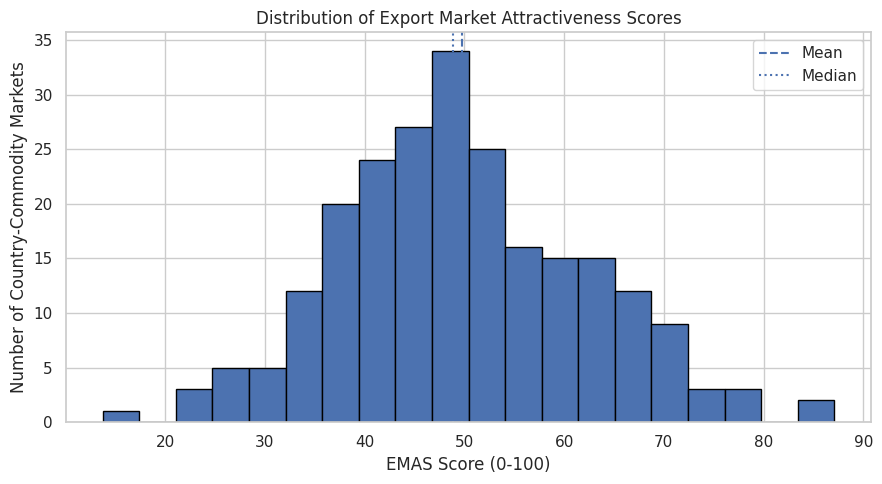

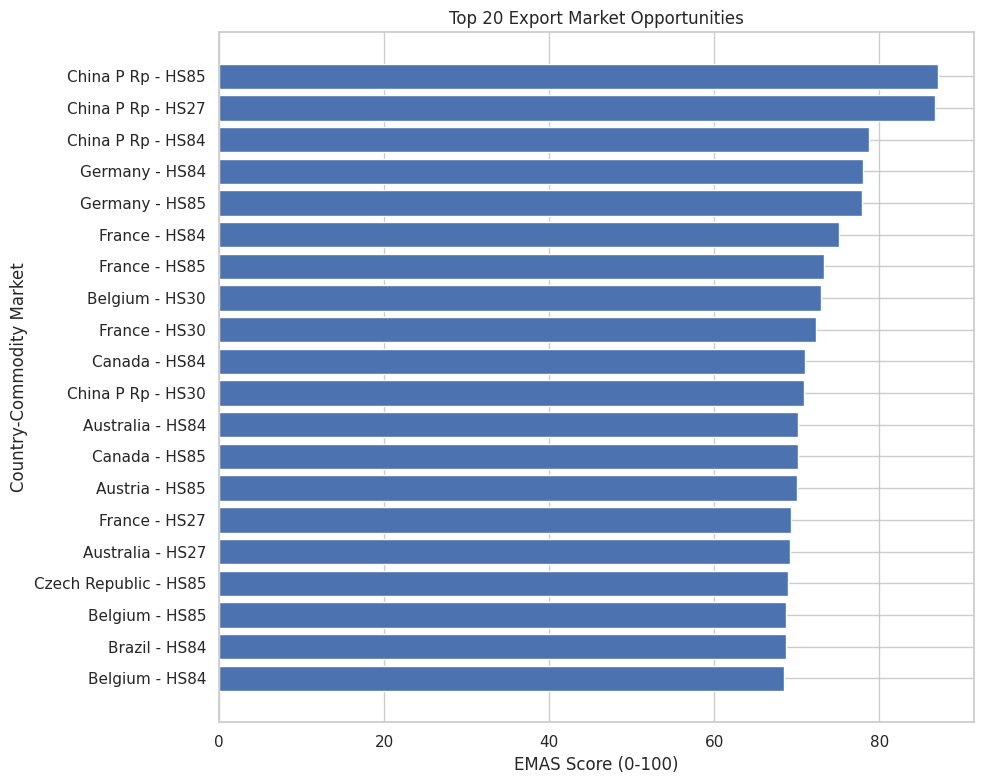


EMAS Summary by Commodity:


,Average_EMAS,Median_EMAS,Maximum_EMAS,Markets
Commodity,,,,
84,53.445,53.247,78.793,48
85,52.596,49.729,87.103,47
27,50.510,49.337,86.713,44
30,49.067,49.077,72.954,47
71,42.745,42.674,68.191,45


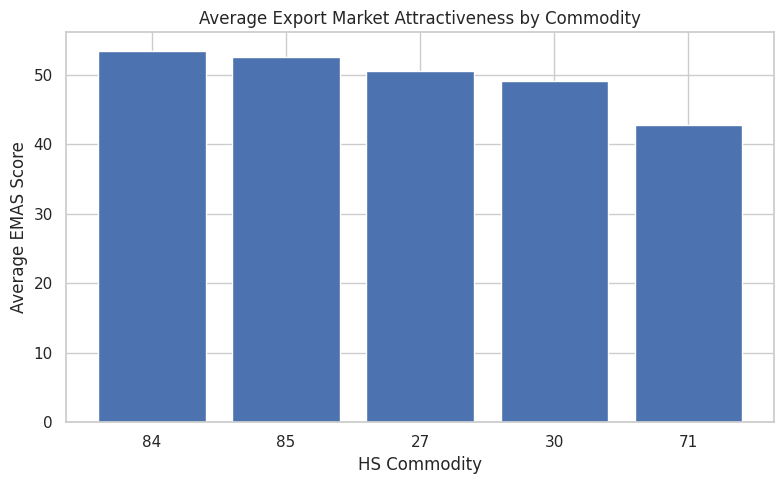


Component profile of Top 10 EMAS markets:


,Export_Demand_Score,Growth_Score,Economic_Strength_Score,Import_Demand_Score,India_Opportunity_Score,Competition_Score,Prediction_Score
Market,,,,,,,
China P Rp - HS85,1.000,0.522,0.879,1.000,0.766,0.917,0.844
China P Rp - HS27,0.968,0.244,0.879,0.978,0.857,1.000,0.913
China P Rp - HS84,0.886,0.115,0.879,0.954,0.580,0.946,0.921
Germany - HS84,0.904,0.111,0.818,0.983,0.502,0.979,0.914
Germany - HS85,0.929,0.116,0.818,0.982,0.494,0.952,0.922
France - HS84,0.831,0.127,0.787,0.943,0.528,0.964,0.837
France - HS85,0.855,0.113,0.787,0.927,0.424,0.934,0.858
Belgium - HS30,0.733,0.114,0.690,0.871,0.792,0.917,0.739
France - HS30,0.801,0.115,0.787,0.893,0.459,0.971,0.805



Weighted component contributions for Top 10 markets:


,Country,Commodity,EMAS_100,Export_Performance_Contribution,Growth_Contribution,Economic_Contribution,Import_Contribution,India_Opportunity_Contribution,Competition_Contribution
119,China P Rp,85,87.103,0.234,0.052,0.132,0.200,0.115,0.138
115,China P Rp,27,86.713,0.237,0.024,0.132,0.196,0.129,0.150
118,China P Rp,84,78.793,0.225,0.012,0.132,0.191,0.087,0.142
209,Germany,84,77.961,0.227,0.011,0.123,0.197,0.075,0.147
210,Germany,85,77.895,0.232,0.012,0.123,0.196,0.074,0.143
191,France,84,75.142,0.208,0.013,0.118,0.189,0.079,0.145
192,France,85,73.261,0.214,0.011,0.118,0.185,0.064,0.140
53,Belgium,30,72.954,0.184,0.011,0.104,0.174,0.119,0.138
189,France,30,72.318,0.201,0.011,0.118,0.179,0.069,0.146
108,Canada,84,70.982,0.185,0.014,0.115,0.187,0.094,0.116


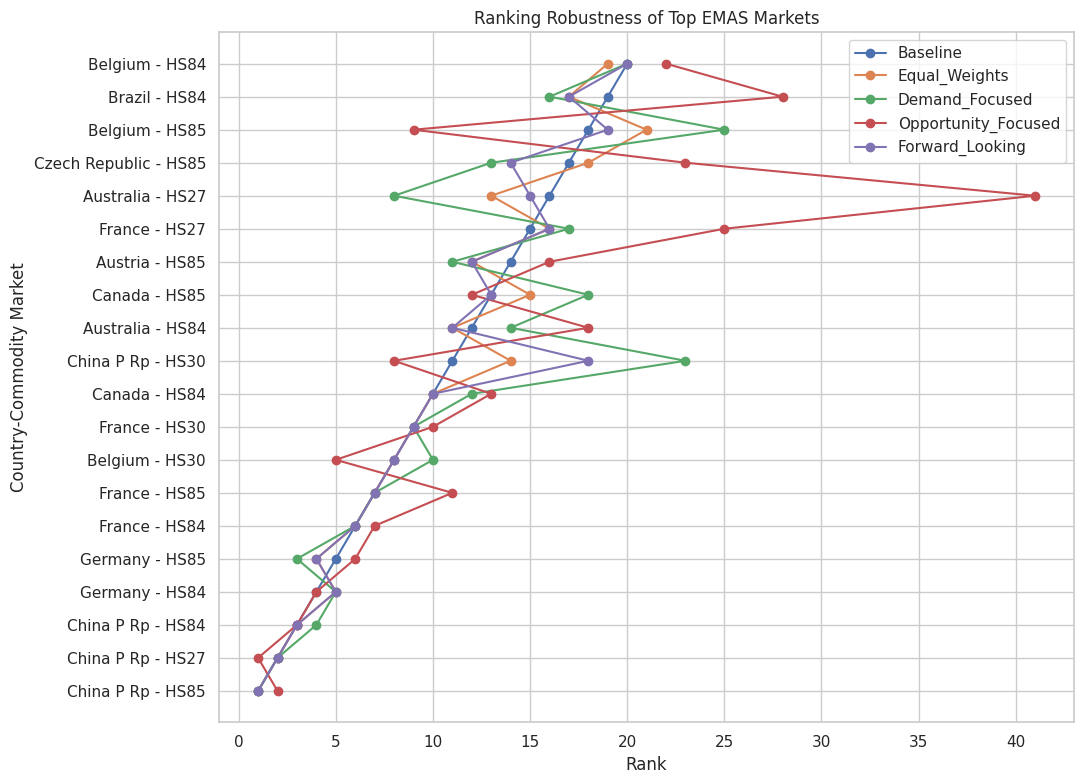


Markets ranked in the Top 20 under ALL weighting scenarios: 13


,Country,Commodity,EMAS_100,EMAS_Rank,Rank_Baseline,Rank_Equal_Weights,Rank_Demand_Focused,Rank_Opportunity_Focused,Rank_Forward_Looking
119,China P Rp,85,87.103,1,1,1,1,2,1
115,China P Rp,27,86.713,2,2,2,2,1,2
118,China P Rp,84,78.793,3,3,3,4,3,3
209,Germany,84,77.961,4,4,5,5,4,5
210,Germany,85,77.895,5,5,4,3,6,4
191,France,84,75.142,6,6,6,6,7,6
192,France,85,73.261,7,7,7,7,11,7
53,Belgium,30,72.954,8,8,8,10,5,8
189,France,30,72.318,9,9,9,9,10,9
108,Canada,84,70.982,10,10,10,12,13,10



FINAL EMAS RESULTS SUMMARY
Country-commodity markets evaluated: 231
Countries represented: 48
Commodities represented: 5
Highest EMAS score: 87.103
Highest-ranked market: China P Rp - HS 85
Highest-ranked market EMAS: 87.103

Final EMAS dimension profile of Top 10 markets:


,Export_Performance_Score,Growth_Score,Economic_Strength_Score,Import_Demand_Score,India_Opportunity_Score,Competition_Score
Market,,,,,,
China P Rp - HS85,0.938,0.522,0.879,1.000,0.766,0.917
China P Rp - HS27,0.946,0.244,0.879,0.978,0.857,1.000
China P Rp - HS84,0.900,0.115,0.879,0.954,0.580,0.946
Germany - HS84,0.908,0.111,0.818,0.983,0.502,0.979
Germany - HS85,0.926,0.116,0.818,0.982,0.494,0.952
France - HS84,0.833,0.127,0.787,0.943,0.528,0.964
France - HS85,0.856,0.113,0.787,0.927,0.424,0.934
Belgium - HS30,0.735,0.114,0.690,0.871,0.792,0.917
France - HS30,0.802,0.115,0.787,0.893,0.459,0.971


In [254]:
# ==============================================================================
# EMAS - STEP 8
# FINAL VALIDATION, INTERPRETATION AND VISUALIZATION
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==============================================================================
# 1. FINAL DATASET VALIDATION
# ==============================================================================

print("=" * 70)
print("EMAS FINAL VALIDATION")
print("=" * 70)

print("\nTotal observations:", len(emas))
print("Unique countries:", emas["Country"].nunique())
print("Unique commodities:", emas["Commodity"].nunique())

print("\nEMAS score range:")
print(
    "Minimum:",
    round(emas["EMAS_100"].min(), 3)
)
print(
    "Maximum:",
    round(emas["EMAS_100"].max(), 3)
)
print(
    "Mean:",
    round(emas["EMAS_100"].mean(), 3)
)
print(
    "Median:",
    round(emas["EMAS_100"].median(), 3)
)


# Check final score completeness

final_check_columns = [
    "EMAS",
    "EMAS_100",
    "EMAS_Rank",
    "EMAS_Category"
]

print("\nMissing values in final EMAS outputs:")

display(
    emas[
        final_check_columns
    ]
    .isna()
    .sum()
    .to_frame("Missing")
)


# Check ranking uniqueness

print(
    "\nUnique EMAS ranks:",
    emas["EMAS_Rank"].nunique()
)

print(
    "Expected observations:",
    len(emas)
)


# ==============================================================================
# 2. FINAL TOP 20 EXPORT MARKET OPPORTUNITIES
# ==============================================================================

top20_final = (
    emas
    .sort_values(
        "EMAS_Rank"
    )
    .head(20)
    [
        [
            "Country",
            "Commodity",
            "Year",
            "EMAS_100",
            "EMAS_Rank",
            "EMAS_Category",
            "Export_Current",
            "Export_Growth",
            "Total_Imports",
            "India_Market_Share",
            "HHI",
            "Predicted_Export_Demand"
        ]
    ]
)

print("\nTop 20 Final EMAS Opportunities:")

display(
    top20_final.round(3)
)


# ==============================================================================
# 3. TOP 5 MARKETS FOR EACH COMMODITY
# ==============================================================================

top5_by_commodity = (
    emas
    .sort_values(
        [
            "Commodity",
            "EMAS_100"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Commodity",
        group_keys=False
    )
    .head(5)
    [
        [
            "Commodity",
            "Country",
            "EMAS_100",
            "EMAS_Rank",
            "EMAS_Category"
        ]
    ]
)

print("\nTop 5 Markets by Commodity:")

display(
    top5_by_commodity.round(3)
)


# ==============================================================================
# 4. DISTRIBUTION OF EMAS SCORES
# ==============================================================================

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    emas["EMAS_100"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    emas["EMAS_100"].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    emas["EMAS_100"].median(),
    linestyle=":",
    label="Median"
)

plt.xlabel(
    "EMAS Score (0-100)"
)

plt.ylabel(
    "Number of Country-Commodity Markets"
)

plt.title(
    "Distribution of Export Market Attractiveness Scores"
)

plt.legend()

plt.tight_layout()

plt.show()


# ==============================================================================
# 5. TOP 20 EMAS OPPORTUNITIES - BAR CHART
# ==============================================================================

top20_plot = (
    emas
    .nsmallest(
        20,
        "EMAS_Rank"
    )
    .copy()
)

top20_plot["Market"] = (
    top20_plot["Country"].astype(str)
    + " - HS"
    + top20_plot["Commodity"].astype(str)
)

top20_plot = (
    top20_plot
    .sort_values(
        "EMAS_100",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top20_plot["Market"],
    top20_plot["EMAS_100"]
)

plt.xlabel(
    "EMAS Score (0-100)"
)

plt.ylabel(
    "Country-Commodity Market"
)

plt.title(
    "Top 20 Export Market Opportunities"
)

plt.tight_layout()

plt.show()


# ==============================================================================
# 6. AVERAGE EMAS SCORE BY COMMODITY
# ==============================================================================

commodity_summary = (
    emas
    .groupby(
        "Commodity"
    )
    .agg(
        Average_EMAS=("EMAS_100", "mean"),
        Median_EMAS=("EMAS_100", "median"),
        Maximum_EMAS=("EMAS_100", "max"),
        Markets=("Country", "count")
    )
    .sort_values(
        "Average_EMAS",
        ascending=False
    )
)

print("\nEMAS Summary by Commodity:")

display(
    commodity_summary.round(3)
)


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    commodity_summary.index.astype(str),
    commodity_summary["Average_EMAS"]
)

plt.xlabel(
    "HS Commodity"
)

plt.ylabel(
    "Average EMAS Score"
)

plt.title(
    "Average Export Market Attractiveness by Commodity"
)

plt.tight_layout()

plt.show()


# ==============================================================================
# 7. EMAS COMPONENT PROFILE OF TOP 10 MARKETS
# ==============================================================================

component_columns = [
    "Export_Demand_Score",
    "Growth_Score",
    "Economic_Strength_Score",
    "Import_Demand_Score",
    "India_Opportunity_Score",
    "Competition_Score",
    "Prediction_Score"
]

top10_components = (
    emas
    .nsmallest(
        10,
        "EMAS_Rank"
    )
    .copy()
)

top10_components["Market"] = (
    top10_components["Country"].astype(str)
    + " - HS"
    + top10_components["Commodity"].astype(str)
)

component_profile = (
    top10_components
    .set_index("Market")
    [component_columns]
)

print("\nComponent profile of Top 10 EMAS markets:")

display(
    component_profile.round(3)
)


# ------------------------------------------------------------------------------
# WEIGHTED COMPONENT CONTRIBUTIONS FOR TOP 10 MARKETS
# ------------------------------------------------------------------------------

print("\nWeighted component contributions for Top 10 markets:")

top10_contributions = (
    emas
    .sort_values(
        "EMAS",
        ascending=False
    )
    .head(10)
)

display(
    top10_contributions[
        [
            "Country",
            "Commodity",
            "EMAS_100",
            "Export_Performance_Contribution",
            "Growth_Contribution",
            "Economic_Contribution",
            "Import_Contribution",
            "India_Opportunity_Contribution",
            "Competition_Contribution"
        ]
    ]
    .round(3)
)


# ==============================================================================
# 9. ROBUSTNESS OF TOP MARKETS ACROSS WEIGHTING SCENARIOS
# ==============================================================================

rank_columns = [
    "Rank_Baseline",
    "Rank_Equal_Weights",
    "Rank_Demand_Focused",
    "Rank_Opportunity_Focused",
    "Rank_Forward_Looking"
]

robustness_top20 = (
    emas
    .nsmallest(
        20,
        "EMAS_Rank"
    )
    .copy()
)

robustness_top20["Market"] = (
    robustness_top20["Country"].astype(str)
    + " - HS"
    + robustness_top20["Commodity"].astype(str)
)

available_rank_columns = [
    col for col in rank_columns
    if col in robustness_top20.columns
]

if len(available_rank_columns) > 1:

    rank_plot = (
        robustness_top20
        .set_index("Market")
        [available_rank_columns]
    )

    plt.figure(
        figsize=(11, 8)
    )

    for col in available_rank_columns:

        plt.plot(
            rank_plot[col],
            rank_plot.index,
            marker="o",
            label=col.replace(
                "Rank_",
                ""
            )
        )

    # Rank 1 stays on the left; higher rank numbers move right.
    plt.xlabel("Rank")

    plt.ylabel(
        "Country-Commodity Market"
    )

    plt.title(
        "Ranking Robustness of Top EMAS Markets"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

else:

    print(
        "\nStep 7 scenario rank columns are not stored in emas; "
        "robustness plot skipped."
    )

# ==============================================================================
# 10. CONSENSUS TOP-20 OPPORTUNITIES
# ==============================================================================

if all(
    col in emas.columns
    for col in rank_columns
):

    consensus_top20 = emas[
        (
            emas[rank_columns]
            <= 20
        )
        .all(axis=1)
    ].copy()

    consensus_top20 = (
        consensus_top20
        .sort_values(
            "EMAS_Rank"
        )
    )

    print(
        "\nMarkets ranked in the Top 20 under ALL weighting scenarios:",
        len(consensus_top20)
    )

    display(
        consensus_top20[
            [
                "Country",
                "Commodity",
                "EMAS_100",
                "EMAS_Rank"
            ]
            + rank_columns
        ]
        .round(3)
    )

else:

    print(
        "\nConsensus calculation skipped because "
        "Step 7 rank columns are not stored in emas."
    )


# ==============================================================================
# 11. FINAL EMAS SUMMARY
# ==============================================================================

print("\n" + "=" * 70)
print("FINAL EMAS RESULTS SUMMARY")
print("=" * 70)

print(
    "Country-commodity markets evaluated:",
    len(emas)
)

print(
    "Countries represented:",
    emas["Country"].nunique()
)

print(
    "Commodities represented:",
    emas["Commodity"].nunique()
)

print(
    "Highest EMAS score:",
    round(
        emas["EMAS_100"].max(),
        3
    )
)

best_market = (
    emas
    .sort_values(
        "EMAS_Rank"
    )
    .iloc[0]
)

print(
    "Highest-ranked market:",
    best_market["Country"],
    "- HS",
    best_market["Commodity"]
)

print(
    "Highest-ranked market EMAS:",
    round(
        best_market["EMAS_100"],
        3
    )
)

print("=" * 70)
# ==============================================================================
# FINAL EMAS DIMENSION PROFILE OF TOP 10 MARKETS
# ==============================================================================

top10_components = (
    emas
    .sort_values("EMAS", ascending=False)
    .head(10)
    .copy()
)

top10_components["Market"] = (
    top10_components["Country"].astype(str)
    + " - HS"
    + top10_components["Commodity"].astype(str)
)

final_component_columns = [
    "Export_Performance_Score",
    "Growth_Score",
    "Economic_Strength_Score",
    "Import_Demand_Score",
    "India_Opportunity_Score",
    "Competition_Score"
]

print("\nFinal EMAS dimension profile of Top 10 markets:")

display(
    top10_components
    .set_index("Market")[final_component_columns]
    .round(3)
)

Overall, the EMAS results demonstrate that export-market attractiveness is multidimensional and cannot be adequately assessed using export growth or market size alone. The framework integrates six complementary dimensions—Export Performance, Growth, Economic Strength, Import Demand, India Opportunity, and Competition—to rank 231 country–commodity opportunities. China–HS85 emerges as the highest-ranked opportunity, while China, Germany, France, Belgium, Canada, and Australia feature prominently among the leading markets. At the commodity level, HS84 demonstrates the strongest average market attractiveness. Sensitivity analysis further indicates that the principal recommendations are robust to alternative weighting assumptions, with strong rank correlations across all tested scenarios and 13 opportunities consistently remaining within the Top 20. These findings support EMAS as a structured decision-support framework for prioritizing export-market opportunities while recognizing that individual market rankings may vary according to strategic weighting preferences.

In [255]:
# ==============================================================================
# EMAS - STEP 9
# FINAL RECOMMENDATION TABLES AND EXPORT
# ==============================================================================

import pandas as pd
import numpy as np


# ==============================================================================
# 1. CREATE ROBUSTNESS CLASSIFICATION
# ==============================================================================

# Count the number of sensitivity scenarios in which each market
# remains within the Top 20.

scenario_rank_columns = [
    "Rank_Baseline",
    "Rank_Equal_Weights",
    "Rank_Demand_Focused",
    "Rank_Opportunity_Focused",
    "Rank_Forward_Looking"
]

emas["Top20_Scenario_Count"] = (
    emas[scenario_rank_columns]
    .le(20)
    .sum(axis=1)
)


# Translate scenario consistency into a simple robustness classification.

def classify_robustness(count):

    if count == 5:
        return "Very Robust"

    elif count >= 4:
        return "Robust"

    elif count >= 2:
        return "Moderately Robust"

    else:
        return "Weight Sensitive"


emas["Robustness"] = (
    emas["Top20_Scenario_Count"]
    .apply(classify_robustness)
)


# ==============================================================================
# 2. CREATE FINAL STRATEGIC RECOMMENDATION
# ==============================================================================

def strategic_recommendation(row):

    # Top-20 market and stable under all weighting scenarios
    if (
        row["EMAS_Rank"] <= 20
        and row["Top20_Scenario_Count"] == 5
    ):
        return "Priority Export Opportunity"

    # Top-20 market and stable under most weighting scenarios
    elif (
        row["EMAS_Rank"] <= 20
        and row["Top20_Scenario_Count"] >= 3
    ):
        return "Strong Opportunity"

    # Top-20 in baseline, but ranking is sensitive to weights
    elif row["EMAS_Rank"] <= 20:
        return "Conditional Opportunity"

    # Outside Top 20 but still relatively attractive
    elif row["EMAS_Rank"] <= 50:
        return "Secondary Opportunity"

    # Remaining markets
    else:
        return "Monitor / Lower Priority"


emas["Strategic_Recommendation"] = (
    emas.apply(
        strategic_recommendation,
        axis=1
    )
)

# ==============================================================================
# 3. FINAL TOP 20 RECOMMENDATION TABLE
# ==============================================================================

final_top20_recommendations = (
    emas
    .sort_values("EMAS_Rank")
    .head(20)
    [
        [
            "EMAS_Rank",
            "Country",
            "Commodity",
            "EMAS_100",
            "EMAS_Category",
            "Robustness",
            "Top20_Scenario_Count",
            "Strategic_Recommendation",
            "Export_Current",
            "Export_Growth",
            "India_Market_Share",
            "Predicted_Export_Demand"
        ]
    ]
)

print("Final Top 20 Strategic Recommendations:")

display(
    final_top20_recommendations
    .round(3)
)


# ==============================================================================
# 4. CONSENSUS PRIORITY OPPORTUNITIES
# ==============================================================================

consensus_priority = (
    emas[
        (emas["EMAS_Rank"] <= 20)
        &
        (emas["Top20_Scenario_Count"] == 5)
    ]
    .sort_values("EMAS_Rank")
    [
        [
            "EMAS_Rank",
            "Country",
            "Commodity",
            "EMAS_100",
            "Robustness",
            "Strategic_Recommendation"
        ]
    ]
)

print(
    "\nConsensus Priority Opportunities:",
    len(consensus_priority)
)

display(
    consensus_priority.round(3)
)


# ==============================================================================
# 5. TOP RECOMMENDATIONS BY COMMODITY
# ==============================================================================

commodity_recommendations = (
    emas
    .sort_values(
        [
            "Commodity",
            "EMAS_Rank"
        ]
    )
    .groupby(
        "Commodity",
        group_keys=False
    )
    .head(5)
    [
        [
            "Commodity",
            "Country",
            "EMAS_100",
            "EMAS_Rank",
            "Robustness",
            "Strategic_Recommendation"
        ]
    ]
)

print("\nTop Recommendations by Commodity:")

display(
    commodity_recommendations.round(3)
)


# ==============================================================================
# 6. COUNTRY-LEVEL STRATEGIC SUMMARY
# ==============================================================================

country_summary = (
    emas
    .groupby("Country")
    .agg(
        Best_EMAS=("EMAS_100", "max"),
        Average_EMAS=("EMAS_100", "mean"),
        Best_Rank=("EMAS_Rank", "min"),
        Top20_Opportunities=(
            "EMAS_Rank",
            lambda x: (x <= 20).sum()
        ),
        Very_Robust_Opportunities=(
            "Top20_Scenario_Count",
            lambda x: (x == 5).sum()
        )
    )
    .sort_values(
        [
            "Top20_Opportunities",
            "Best_EMAS"
        ],
        ascending=[
            False,
            False
        ]
    )
)

print("\nCountry-Level Strategic Summary:")

display(
    country_summary
    .head(20)
    .round(3)
)


# ==============================================================================
# 7. FINAL RECOMMENDATION COUNTS
# ==============================================================================

print("\nStrategic Recommendation Distribution:")

display(
    emas["Strategic_Recommendation"]
    .value_counts()
    .to_frame("Count")
)

print("\nRobustness Distribution:")

display(
    emas["Robustness"]
    .value_counts()
    .to_frame("Count")
)


# ==============================================================================
# 8. SAVE FINAL OUTPUT FILES
# ==============================================================================

final_output_columns = [
    "Country",
    "Commodity",
    "Year",
    "EMAS",
    "EMAS_100",
    "EMAS_Rank",
    "EMAS_Category",
    "Robustness",
    "Top20_Scenario_Count",
    "Strategic_Recommendation",
    "Export_Current",
    "Export_Growth",
    "Total_Imports",
    "India_Market_Share",
    "HHI",
    "Predicted_Export_Demand",
    "Export_Demand_Score",
    "Growth_Score",
    "Economic_Strength_Score",
    "Import_Demand_Score",
    "India_Opportunity_Score",
    "Competition_Score",
    "Prediction_Score"
]

emas_final_output = (
    emas[final_output_columns]
    .sort_values("EMAS_Rank")
)


# Save complete ranked dataset
emas_final_output.to_csv(
    "EMAS_Final_Ranked_Results.csv",
    index=False
)


# Save final Top 20
final_top20_recommendations.to_csv(
    "EMAS_Top20_Recommendations.csv",
    index=False
)


# Save commodity-level recommendations
commodity_recommendations.to_csv(
    "EMAS_Top5_By_Commodity.csv",
    index=False
)


# Save consensus robust opportunities
consensus_priority.to_csv(
    "EMAS_Consensus_Priority_Opportunities.csv",
    index=False
)


print("\nFinal EMAS output files saved successfully.")


# ==============================================================================
# 9. FINAL PROJECT SUMMARY
# ==============================================================================

print("\n" + "=" * 70)
print("EMAS FINAL RECOMMENDATION SUMMARY")
print("=" * 70)

print(
    "Total markets evaluated:",
    len(emas)
)

print(
    "Top 20 opportunities:",
    (emas["EMAS_Rank"] <= 20).sum()
)

print(
    "Consensus Top-20 opportunities:",
    len(consensus_priority)
)

print(
    "Highest-ranked opportunity:",
    emas.loc[
        emas["EMAS_Rank"].idxmin(),
        "Country"
    ],
    "- HS",
    emas.loc[
        emas["EMAS_Rank"].idxmin(),
        "Commodity"
    ]
)

print("=" * 70)

Final Top 20 Strategic Recommendations:


,EMAS_Rank,Country,Commodity,EMAS_100,EMAS_Category,Robustness,Top20_Scenario_Count,Strategic_Recommendation,Export_Current,Export_Growth,India_Market_Share,Predicted_Export_Demand
119,1,China P Rp,85,87.103,Very High,Very Robust,5,Priority Export Opportunity,3178.29,277.19,0.190,774.205
115,2,China P Rp,27,86.713,Very High,Very Robust,5,Priority Export Opportunity,2462.26,93.99,0.059,1332.578
118,3,China P Rp,84,78.793,Very High,Very Robust,5,Priority Export Opportunity,1263.12,8.80,0.502,1412.892
209,4,Germany,84,77.961,Very High,Very Robust,5,Priority Export Opportunity,1463.83,6.24,0.625,1338.432
210,5,Germany,85,77.895,Very High,Very Robust,5,Priority Export Opportunity,1794.47,9.60,0.631,1422.548
191,6,France,84,75.142,Very High,Very Robust,5,Priority Export Opportunity,810.81,16.38,0.594,729.861
192,7,France,85,73.261,Very High,Very Robust,5,Priority Export Opportunity,989.45,7.46,0.911,858.033
53,8,Belgium,30,72.954,Very High,Very Robust,5,Priority Export Opportunity,368.05,8.29,0.142,337.463
189,9,France,30,72.318,Very High,Very Robust,5,Priority Export Opportunity,635.41,8.38,0.759,568.235
108,10,Canada,84,70.982,Very High,Very Robust,5,Priority Export Opportunity,379.44,24.77,0.389,342.825



Consensus Priority Opportunities: 13


,EMAS_Rank,Country,Commodity,EMAS_100,Robustness,Strategic_Recommendation
119,1,China P Rp,85,87.103,Very Robust,Priority Export Opportunity
115,2,China P Rp,27,86.713,Very Robust,Priority Export Opportunity
118,3,China P Rp,84,78.793,Very Robust,Priority Export Opportunity
209,4,Germany,84,77.961,Very Robust,Priority Export Opportunity
210,5,Germany,85,77.895,Very Robust,Priority Export Opportunity
191,6,France,84,75.142,Very Robust,Priority Export Opportunity
192,7,France,85,73.261,Very Robust,Priority Export Opportunity
53,8,Belgium,30,72.954,Very Robust,Priority Export Opportunity
189,9,France,30,72.318,Very Robust,Priority Export Opportunity
108,10,Canada,84,70.982,Very Robust,Priority Export Opportunity



Top Recommendations by Commodity:


...


Strategic Recommendation Distribution:


,Count
Strategic_Recommendation,
Monitor / Lower Priority,181
Secondary Opportunity,30
Priority Export Opportunity,13
Strong Opportunity,7



Robustness Distribution:


,Count
Robustness,
Weight Sensitive,210
Very Robust,13
Robust,6
Moderately Robust,2



Final EMAS output files saved successfully.

EMAS FINAL RECOMMENDATION SUMMARY
Total markets evaluated: 231
Top 20 opportunities: 20
Consensus Top-20 opportunities: 13
Highest-ranked opportunity: China P Rp - HS 85


## Step 9 Observations – Final Strategic Recommendations

The final strategic recommendation stage translates the EMAS rankings and sensitivity-analysis results into actionable export-market priorities. The results establish a clear hierarchy across the **231 country–commodity combinations** evaluated.

### 1. Consensus Priority Export Opportunities

- **13 markets are classified as Priority Export Opportunities.**
- These markets remain within the Top 20 under all five weighting scenarios and are therefore classified as **Very Robust**.
- Their attractiveness is consequently less dependent on the specific EMAS weighting assumptions.

### 2. China Represents the Strongest Overall Export Destination

China occupies the top three positions in the final ranking:

- **China – HS85:** EMAS = **87.103**, Rank 1
- **China – HS27:** EMAS = **86.713**, Rank 2
- **China – HS84:** EMAS = **78.793**, Rank 3

China therefore demonstrates strong strategic potential across multiple commodity groups.

### 3. Strong Representation of European Markets

Germany and France emerge as important diversified European export destinations.

- **Germany – HS84** and **Germany – HS85** rank fourth and fifth respectively.
- France contributes three Very Robust Priority Export Opportunities across **HS84, HS85, and HS30**.
- France also has four country–commodity combinations within the overall Top 20.

The remaining consensus priority opportunities include **Belgium – HS30, Canada – HS84, Australia – HS84, Canada – HS85, and Austria – HS85**.

The priority set is therefore geographically diversified across Asian, European, North American, and Oceanian destinations.

### 4. Strong Opportunities Form a Secondary Strategic Pipeline

- **7 markets are classified as Strong Opportunities.**
- These consist of markets classified as Robust or Moderately Robust within the final Top 20.

They include:

- China – HS30
- France – HS27
- Australia – HS27
- Czech Republic – HS85
- Belgium – HS85
- Brazil – HS84
- Belgium – HS84

These opportunities remain attractive but demonstrate greater sensitivity to alternative weighting assumptions than the 13 Very Robust markets.

### 5. Belgium – HS85 Requires Comparatively Greater Caution

**Belgium – HS85** ranks **18th with an EMAS score of 68.646** and is classified as **Moderately Robust**.

It appears within the Top 20 under three of the five weighting scenarios. Therefore, it remains strategically relevant but provides weaker robustness evidence than the Very Robust and Robust opportunities.

### 6. HS84 and HS85 Demonstrate Strong Strategic Potential

At the commodity level, **HS84 and HS85 demonstrate particularly strong strategic potential**.

The five leading HS84 destinations are:

- China
- Germany
- France
- Canada
- Australia

All five are classified as **Very Robust Priority Export Opportunities**.

Similarly, the leading HS85 destinations are:

- China
- Germany
- France
- Canada
- Austria

All five are also classified as **Very Robust Priority Export Opportunities**.

### 7. HS27 Shows Greater Variation in Robustness

HS27 displays greater variation across markets.

- **China – HS27** is a Very Robust Priority Export Opportunity.
- **France – HS27** and **Australia – HS27** are classified as Robust Strong Opportunities.
- Other leading HS27 markets, including Belgium and Brazil, are weight-sensitive Secondary Opportunities.

This indicates that market selection within HS27 is more dependent on strategic weighting assumptions.

### 8. Final Strategic Recommendation Distribution

The final recommendation framework is intentionally selective.

Of the **231 evaluated opportunities**:

- **13** are classified as **Priority Export Opportunities**
- **7** are classified as **Strong Opportunities**
- **30** are classified as **Secondary Opportunities**
- **181** are classified as **Monitor / Lower Priority**

This provides a practical hierarchy rather than treating every attractive market as an immediate strategic priority.

### 9. Strategic Interpretation

Overall, combining the **EMAS ranking with sensitivity-based robustness analysis** provides stronger decision support than relying on the composite score alone.

Markets that maintain high rankings under alternative weighting assumptions can be prioritized with greater confidence. In contrast, weight-sensitive opportunities warrant additional product-level assessment of tariffs, regulations, logistics, competitive conditions, and market-entry feasibility before investment decisions are made.

### Key Takeaway

The strongest strategic focus should be placed on the **13 consensus Priority Export Opportunities**, particularly:

- **China:** HS85, HS27, and HS84
- **Germany:** HS84 and HS85
- **France:** HS84, HS85, and HS30

The **7 Strong Opportunities** provide a secondary pipeline for further investigation, while Secondary and Monitor / Lower-Priority markets should receive progressively lower levels of immediate strategic attention.

In [256]:
# ==============================================================================
# EMAS - STEP 10
# FINAL OUTPUT CONSOLIDATION AND EXPORT
# ==============================================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------------------------
# 1. DEFINE FINAL OUTPUT COLUMNS
# ------------------------------------------------------------------------------

final_columns = [
    "Country",
    "Commodity",
    "Year",

    # Original market indicators
    "Export_Previous",
    "Export_Current",
    "Export_Growth",
    "Total_Imports",
    "India_Market_Share",
    "HHI",
    "Predicted_Export_Demand",

    # EMAS component scores
    "Export_Demand_Score",
    "Growth_Score",
    "Economic_Strength_Score",
    "Import_Demand_Score",
    "India_Opportunity_Score",
    "Competition_Score",
    "Prediction_Score",

    # Final EMAS results
    "EMAS",
    "EMAS_100",
    "EMAS_Rank",
    "EMAS_Category",

    # Sensitivity / robustness
    "Top20_Scenario_Count",
    "Robustness",

    # Final recommendation
    "Strategic_Recommendation"
]


# Keep only columns that actually exist
final_columns = [
    col for col in final_columns
    if col in emas.columns
]

emas_final = (
    emas[final_columns]
    .copy()
    .sort_values(
        "EMAS_Rank"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------------------
# 2. CREATE MARKET IDENTIFIER
# ------------------------------------------------------------------------------

emas_final["Market"] = (
    emas_final["Country"].astype(str)
    + " - HS"
    + emas_final["Commodity"].astype(str)
)


# Move Market near the beginning

cols = emas_final.columns.tolist()

cols.remove("Market")

cols.insert(
    2,
    "Market"
)

emas_final = emas_final[cols]


# ------------------------------------------------------------------------------
# 3. CREATE PRIORITY FLAG
# ------------------------------------------------------------------------------

emas_final["Priority_Flag"] = np.select(

    [
        emas_final["Strategic_Recommendation"]
        == "Priority Export Opportunity",

        emas_final["Strategic_Recommendation"]
        == "Strong Opportunity",

        emas_final["Strategic_Recommendation"]
        == "Conditional Opportunity",

        emas_final["Strategic_Recommendation"]
        == "Secondary Opportunity"
    ],

    [
        "Tier 1",
        "Tier 2",
        "Tier 3",
        "Tier 4"
    ],

    default="Monitor"
)


# ------------------------------------------------------------------------------
# 4. CREATE FINAL TOP-20 TABLE
# ------------------------------------------------------------------------------

final_top20 = (
    emas_final
    .head(20)
    [
        [
            "EMAS_Rank",
            "Country",
            "Commodity",
            "EMAS_100",
            "EMAS_Category",
            "Robustness",
            "Top20_Scenario_Count",
            "Strategic_Recommendation",
            "Priority_Flag"
        ]
    ]
)

print("Final Top 20 EMAS Decision Table:")

display(
    final_top20.round(3)
)


# ------------------------------------------------------------------------------
# 5. CREATE CONSENSUS PRIORITY TABLE
# ------------------------------------------------------------------------------

consensus_priority = (
    emas_final[
        emas_final["Strategic_Recommendation"]
        == "Priority Export Opportunity"
    ]
    .sort_values("EMAS_Rank")
)

print(
    "\nConsensus Priority Export Opportunities:",
    len(consensus_priority)
)

display(
    consensus_priority[
        [
            "EMAS_Rank",
            "Country",
            "Commodity",
            "EMAS_100",
            "Robustness",
            "Top20_Scenario_Count",
            "Priority_Flag"
        ]
    ].round(3)
)


# ------------------------------------------------------------------------------
# 6. CREATE COMMODITY-LEVEL PRIORITY SUMMARY
# ------------------------------------------------------------------------------

commodity_priority_summary = (
    emas_final
    .groupby("Commodity")
    .agg(
        Markets_Evaluated=("Country", "count"),
        Average_EMAS=("EMAS_100", "mean"),
        Maximum_EMAS=("EMAS_100", "max"),
        Best_Rank=("EMAS_Rank", "min"),
        Priority_Opportunities=(
            "Strategic_Recommendation",
            lambda x: (
                x == "Priority Export Opportunity"
            ).sum()
        ),
        Strong_Opportunities=(
            "Strategic_Recommendation",
            lambda x: (
                x == "Strong Opportunity"
            ).sum()
        )
    )
    .sort_values(
        "Average_EMAS",
        ascending=False
    )
)

print("\nFinal Commodity-Level Summary:")

display(
    commodity_priority_summary.round(3)
)


# ------------------------------------------------------------------------------
# 7. CREATE COUNTRY-LEVEL PRIORITY SUMMARY
# ------------------------------------------------------------------------------

country_priority_summary = (
    emas_final
    .groupby("Country")
    .agg(
        Markets_Evaluated=("Commodity", "count"),
        Average_EMAS=("EMAS_100", "mean"),
        Best_EMAS=("EMAS_100", "max"),
        Best_Rank=("EMAS_Rank", "min"),
        Priority_Opportunities=(
            "Strategic_Recommendation",
            lambda x: (
                x == "Priority Export Opportunity"
            ).sum()
        ),
        Strong_Opportunities=(
            "Strategic_Recommendation",
            lambda x: (
                x == "Strong Opportunity"
            ).sum()
        )
    )
    .sort_values(
        [
            "Priority_Opportunities",
            "Best_EMAS"
        ],
        ascending=[
            False,
            False
        ]
    )
)

print("\nFinal Country-Level Summary:")

display(
    country_priority_summary
    .head(20)
    .round(3)
)


# ------------------------------------------------------------------------------
# 8. FINAL QUALITY CHECK
# ------------------------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL EMAS OUTPUT CHECK")
print("=" * 70)

print(
    "Total markets:",
    len(emas_final)
)

print(
    "Unique countries:",
    emas_final["Country"].nunique()
)

print(
    "Unique commodities:",
    emas_final["Commodity"].nunique()
)

print(
    "Priority opportunities:",
    (
        emas_final["Strategic_Recommendation"]
        == "Priority Export Opportunity"
    ).sum()
)

print(
    "Strong opportunities:",
    (
        emas_final["Strategic_Recommendation"]
        == "Strong Opportunity"
    ).sum()
)

print(
    "Conditional opportunities:",
    (
        emas_final["Strategic_Recommendation"]
        == "Conditional Opportunity"
    ).sum()
)

print(
    "Secondary opportunities:",
    (
        emas_final["Strategic_Recommendation"]
        == "Secondary Opportunity"
    ).sum()
)

print(
    "Monitor / lower priority:",
    (
        emas_final["Strategic_Recommendation"]
        == "Monitor / Lower Priority"
    ).sum()
)


# ------------------------------------------------------------------------------
# 9. EXPORT FINAL RESULTS
# ------------------------------------------------------------------------------

emas_final.to_csv(
    "EMAS_Final_Market_Ranking.csv",
    index=False
)

final_top20.to_csv(
    "EMAS_Top20_Recommendations.csv",
    index=False
)

consensus_priority.to_csv(
    "EMAS_Consensus_Priority_Markets.csv",
    index=False
)

commodity_priority_summary.to_csv(
    "EMAS_Commodity_Summary.csv"
)

country_priority_summary.to_csv(
    "EMAS_Country_Summary.csv"
)


print("\nFinal EMAS datasets exported successfully.")

print("\nFiles created:")
print("- EMAS_Final_Market_Ranking.csv")
print("- EMAS_Top20_Recommendations.csv")
print("- EMAS_Consensus_Priority_Markets.csv")
print("- EMAS_Commodity_Summary.csv")
print("- EMAS_Country_Summary.csv")

Final Top 20 EMAS Decision Table:


,EMAS_Rank,Country,Commodity,EMAS_100,EMAS_Category,Robustness,Top20_Scenario_Count,Strategic_Recommendation,Priority_Flag
0,1,China P Rp,85,87.103,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
1,2,China P Rp,27,86.713,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
2,3,China P Rp,84,78.793,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
3,4,Germany,84,77.961,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
4,5,Germany,85,77.895,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
5,6,France,84,75.142,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
6,7,France,85,73.261,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
7,8,Belgium,30,72.954,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
8,9,France,30,72.318,Very High,Very Robust,5,Priority Export Opportunity,Tier 1
9,10,Canada,84,70.982,Very High,Very Robust,5,Priority Export Opportunity,Tier 1



Consensus Priority Export Opportunities: 13


,EMAS_Rank,Country,Commodity,EMAS_100,Robustness,Top20_Scenario_Count,Priority_Flag
0,1,China P Rp,85,87.103,Very Robust,5,Tier 1
1,2,China P Rp,27,86.713,Very Robust,5,Tier 1
2,3,China P Rp,84,78.793,Very Robust,5,Tier 1
3,4,Germany,84,77.961,Very Robust,5,Tier 1
4,5,Germany,85,77.895,Very Robust,5,Tier 1
5,6,France,84,75.142,Very Robust,5,Tier 1
6,7,France,85,73.261,Very Robust,5,Tier 1
7,8,Belgium,30,72.954,Very Robust,5,Tier 1
8,9,France,30,72.318,Very Robust,5,Tier 1
9,10,Canada,84,70.982,Very Robust,5,Tier 1



Final Commodity-Level Summary:


,Markets_Evaluated,Average_EMAS,Maximum_EMAS,Best_Rank,Priority_Opportunities,Strong_Opportunities
Commodity,,,,,,
84,48,53.445,78.793,3,5,2
85,47,52.596,87.103,1,5,2
27,44,50.510,86.713,2,1,2
30,47,49.067,72.954,8,2,1
71,45,42.745,68.191,21,0,0



Final Country-Level Summary:


,Markets_Evaluated,Average_EMAS,Best_EMAS,Best_Rank,Priority_Opportunities,Strong_Opportunities
Country,,,,,,
China P Rp,5,76.887,87.103,1,3,1
France,5,70.831,75.142,6,3,1
Germany,3,73.781,77.961,4,2,0
Canada,5,66.161,70.982,10,2,0
Belgium,5,68.649,72.954,8,1,2
Australia,5,66.676,70.158,12,1,1
Austria,5,60.070,69.985,14,1,0
Czech Republic,5,59.868,68.880,17,0,1
Brazil,5,63.026,68.640,19,0,1



FINAL EMAS OUTPUT CHECK
Total markets: 231
Unique countries: 48
Unique commodities: 5
Priority opportunities: 13
Strong opportunities: 7
Conditional opportunities: 0
Secondary opportunities: 30
Monitor / lower priority: 181

Final EMAS datasets exported successfully.

Files created:
- EMAS_Final_Market_Ranking.csv
- EMAS_Top20_Recommendations.csv
- EMAS_Consensus_Priority_Markets.csv
- EMAS_Commodity_Summary.csv
- EMAS_Country_Summary.csv


## Observations – Final Strategic Recommendations

The final strategic recommendation stage translates the EMAS rankings and sensitivity-analysis results into actionable export-market priorities. The results establish a clear hierarchy across the **231 country–commodity combinations** evaluated.

### 1. Consensus Priority Export Opportunities

A total of **13 markets are classified as Priority Export Opportunities**.

These opportunities remain within the Top 20 under all five weighting scenarios and are therefore classified as **Very Robust**. Their attractiveness is consequently less dependent on the specific weighting assumptions used in the EMAS framework.

This provides greater confidence that these markets represent structurally attractive export opportunities rather than rankings produced by a particular choice of weights.

### 2. China Represents the Strongest Overall Export Destination

China dominates the final EMAS ranking:

- **China – HS85:** EMAS = **87.103**, Rank 1
- **China – HS27:** EMAS = **86.713**, Rank 2
- **China – HS84:** EMAS = **78.793**, Rank 3

China has **three Priority Export Opportunities** and one additional Strong Opportunity.

Its average EMAS across the five evaluated commodity groups is **76.887**, the highest among the countries included in the final country-level summary.

These results indicate strong and diversified export-market potential in China across multiple commodity categories.

### 3. European Markets Are Strongly Represented

Germany and France emerge as particularly important European export destinations.

- **Germany – HS84** ranks 4th with an EMAS of **77.961**.
- **Germany – HS85** ranks 5th with an EMAS of **77.895**.
- France contributes three Priority Export Opportunities across **HS84, HS85, and HS30**.
- France also has one additional Strong Opportunity.

Belgium also contributes one Priority Export Opportunity and two Strong Opportunities.

The results therefore indicate substantial export potential across several established European economies.

### 4. HS84 and HS85 Demonstrate the Strongest Strategic Potential

At the commodity level, **HS84 records the highest average EMAS score of 53.445**, followed by **HS85 with 52.596**.

HS84 contains:

- **5 Priority Export Opportunities**
- **2 Strong Opportunities**

HS85 also contains:

- **5 Priority Export Opportunities**
- **2 Strong Opportunities**

Although HS84 has the highest average attractiveness across markets, **HS85 contains the single highest-ranked country–commodity opportunity: China – HS85**.

This indicates that both HS84 and HS85 represent particularly promising commodity groups for export-market development.

### 5. HS27 Shows Greater Variation Across Markets

HS27 records an average EMAS score of **50.510** and contains:

- **1 Priority Export Opportunity**
- **2 Strong Opportunities**

China – HS27 is the only Very Robust Priority Export Opportunity within this commodity group, while France – HS27 and Australia – HS27 are classified as Strong Opportunities.

This suggests that HS27 contains attractive opportunities, but market selection is more sensitive to destination-specific conditions and weighting assumptions.

### 6. HS71 Shows Relatively Lower Strategic Attractiveness

HS71 records the lowest average EMAS among the five commodity groups at **42.745**.

It contains:

- **0 Priority Export Opportunities**
- **0 Strong Opportunities**

Its best-ranked market is only Rank **21**, with a maximum EMAS of **68.191**.

Relative to HS84, HS85, HS27, and HS30, the results therefore indicate lower immediate strategic priority for HS71 within the evaluated market set.

### 7. Strong Opportunities Provide a Secondary Strategic Pipeline

A total of **7 markets are classified as Strong Opportunities**.

These include:

- China – HS30
- France – HS27
- Australia – HS27
- Czech Republic – HS85
- Belgium – HS85
- Brazil – HS84
- Belgium – HS84

Most of these markets remain within the Top 20 under four of the five weighting scenarios.

Belgium – HS85 is comparatively more weight-sensitive, appearing in the Top 20 under three scenarios and receiving a **Moderately Robust** classification.

These markets remain strategically attractive but warrant somewhat greater market-specific investigation than the 13 consensus Priority Export Opportunities.

### 8. No Conditional Opportunities Remain in the Final Framework

The final EMAS recommendation framework identifies **zero Conditional Opportunities**.

This indicates that the final classification separates the evaluated markets directly into Priority, Strong, Secondary, and Monitor / Lower-Priority groups based on their attractiveness and robustness characteristics.

### 9. Final Strategic Recommendation Distribution

The final recommendation framework is intentionally selective.

Of the **231 evaluated country–commodity opportunities**:

- **13** are classified as **Priority Export Opportunities**
- **7** are classified as **Strong Opportunities**
- **30** are classified as **Secondary Opportunities**
- **181** are classified as **Monitor / Lower Priority**
- **0** are classified as **Conditional Opportunities**

Only **20 of the 231 opportunities** therefore enter the Priority or Strong strategic groups.

This provides a focused hierarchy for allocating further market-research and export-development resources.

### 10. Strategic Interpretation

The final results demonstrate the value of combining the EMAS composite ranking with sensitivity-based robustness analysis.

The EMAS score identifies markets with attractive combinations of export performance, growth, economic strength, import demand, India opportunity, and competitive conditions, while the robustness assessment determines whether those rankings remain stable under alternative weighting assumptions.

Markets that maintain high rankings across multiple scenarios can therefore be prioritized with greater confidence, while more weight-sensitive markets should undergo additional product-level assessment of tariffs, regulations, logistics, competition, and market-entry feasibility before investment decisions are made.

### Key Takeaway

The strongest strategic focus should be placed on the **13 consensus Priority Export Opportunities**, particularly:

- **China:** HS85, HS27, and HS84
- **Germany:** HS84 and HS85
- **France:** HS84, HS85, and HS30
- **Belgium:** HS30
- **Canada:** HS84 and HS85
- **Australia:** HS84
- **Austria:** HS85

Among the commodity groups, **HS84 demonstrates the highest average market attractiveness**, while **HS85 contains the highest-ranked individual opportunity, China – HS85**.

The **7 Strong Opportunities** provide a secondary pipeline for further investigation, while Secondary and Monitor / Lower-Priority markets should receive progressively lower levels of immediate strategic attention.

# Final Findings and Business Interpretation

The Export Market Attractiveness Score (EMAS) framework evaluated **231 country–commodity market combinations**, covering **48 countries and 5 HS commodity groups**. The final framework integrates six dimensions—**Export Performance, Export Growth, Economic Strength, Import Demand, India Opportunity, and Competition**—into a unified market-attractiveness score.

## 1. Overall Market Attractiveness

The final EMAS results demonstrate substantial variation in market attractiveness across the evaluated country–commodity combinations, allowing the framework to distinguish between relatively stronger and weaker export opportunities.

The highest-ranked opportunity is:

**China – HS85**
- EMAS Score: **87.103**
- Overall Rank: **1**
- Category: **Very High**
- Robustness: **Very Robust**
- Strategic Classification: **Priority Export Opportunity**

China – HS27 follows closely with an EMAS score of **86.713** and Rank 2, while China – HS84 ranks third with an EMAS score of **78.793**.

The concentration of China in the top three positions indicates particularly strong export-market attractiveness across multiple commodity groups.

## 2. Consensus Priority Markets

Sensitivity analysis evaluated the stability of the EMAS rankings under **five weighting scenarios**.

A total of **13 markets remained within the Top 20 under all five scenarios**. These markets are classified as **Very Robust Priority Export Opportunities** and represent the strongest consensus opportunities identified by the framework.

The 13 Tier-1 opportunities are:

1. China – HS85
2. China – HS27
3. China – HS84
4. Germany – HS84
5. Germany – HS85
6. France – HS84
7. France – HS85
8. Belgium – HS30
9. France – HS30
10. Canada – HS84
11. Australia – HS84
12. Canada – HS85
13. Austria – HS85

These markets warrant the highest strategic consideration because their attractiveness remains strong under all tested weighting assumptions.

## 3. Commodity-Level Findings

The commodity-level analysis indicates that **HS84 and HS85 provide the broadest set of high-priority export opportunities**.

- **HS84** records the highest average EMAS score at **53.445**, with **5 Priority Export Opportunities** and **2 Strong Opportunities**.
- **HS85** records an average EMAS score of **52.596**, also with **5 Priority Export Opportunities** and **2 Strong Opportunities**. It contains the overall highest-ranked opportunity, China – HS85.
- **HS27** records an average EMAS score of **50.510**, with **1 Priority Export Opportunity** and **2 Strong Opportunities**.
- **HS30** records an average EMAS score of **49.067**, with **2 Priority Export Opportunities** and **1 Strong Opportunity**.
- **HS71** records the lowest average EMAS score at **42.745** and contains **no Priority or Strong Opportunities**.

Therefore, **HS84 and HS85 emerge as the strongest commodity groups for strategic export-market development** within the evaluated dataset.

## 4. Country-Level Findings

China emerges as the strongest overall destination in the final EMAS results.

China records:

- Best EMAS: **87.103**
- Average EMAS: **76.887**
- **3 Priority Export Opportunities**
- **1 Strong Opportunity**

France also demonstrates broad attractiveness, with an average EMAS of **70.831**, three Priority Export Opportunities, and one Strong Opportunity.

Germany records an average EMAS of **73.781** and contributes two Priority Export Opportunities, while Canada also contributes two Priority opportunities.

Belgium, Australia, and Austria provide additional targeted Priority opportunities.

Overall, the results indicate that the strongest export potential is concentrated within a relatively small group of destination markets rather than being evenly distributed across all 48 evaluated countries.

## 5. Robustness of the Results

Sensitivity analysis provides an additional layer of confidence in the final recommendations by examining whether market rankings remain stable when the EMAS component weights are changed.

The analysis shows strong consistency between the baseline ranking and alternative weighting scenarios. Most importantly, **13 markets remain within the Top 20 under all five weighting scenarios**.

These opportunities are classified as **Very Robust**, indicating that their strategic attractiveness is not dependent on a single weighting configuration.

The robustness analysis therefore strengthens the interpretation of EMAS by distinguishing structurally strong opportunities from markets whose rankings are more sensitive to strategic weighting preferences.

## 6. Strategic Priority Tiers

The final decision framework converts the analytical results into actionable strategic priority levels.

### Tier 1 — Priority Export Opportunities

**13 markets** are classified as Priority Export Opportunities.

All 13 are classified as **Very Robust**, remaining within the Top 20 under all five weighting scenarios.

These markets should receive the highest priority for detailed commercial and market-entry assessment.

### Tier 2 — Strong Opportunities

**7 markets** are classified as Strong Opportunities:

- China – HS30
- France – HS27
- Australia – HS27
- Czech Republic – HS85
- Belgium – HS85
- Brazil – HS84
- Belgium – HS84

These opportunities remain attractive but demonstrate somewhat greater sensitivity to changes in the EMAS weighting assumptions.

Most are classified as **Robust**, while Belgium – HS85 is classified as **Moderately Robust**.

### Tier 3 — Secondary Opportunities

A further **30 markets** are classified as Secondary Opportunities.

These markets may present potential export opportunities but do not demonstrate the same combination of high attractiveness and ranking robustness observed among the Tier-1 and Tier-2 markets.

### Monitor / Lower Priority

The remaining **181 markets** are classified as Monitor / Lower Priority.

These markets currently provide weaker evidence of strategic attractiveness within the EMAS framework and therefore warrant lower immediate priority.

The final recommendation distribution is therefore:

- **13 Priority Export Opportunities**
- **7 Strong Opportunities**
- **30 Secondary Opportunities**
- **181 Monitor / Lower Priority**
- **0 Conditional Opportunities**

## 7. Key Business Insight

The EMAS framework should be interpreted as a **market-screening and prioritization tool rather than an automatic market-entry decision rule**.

The strongest opportunities are those that combine high overall market attractiveness with robustness across alternative weighting assumptions. Based on this principle, the **13 consensus Tier-1 markets** provide the strongest candidates for further commercial evaluation.

The seven Strong Opportunities provide a secondary pipeline of attractive markets that may warrant further investigation depending on the strategic priorities of exporters.

Before actual market entry, shortlisted opportunities should be supplemented with detailed assessment of **tariffs, regulatory requirements, logistics, product-level competition, distribution channels, pricing, trade policies, and other country-specific commercial considerations**.

## Conclusion

The analysis identifies a clear and differentiated hierarchy of export-market opportunities.

**China emerges as the strongest overall destination**, with HS85, HS27, and HS84 occupying the first three positions in the final EMAS ranking. Germany and France also demonstrate strong and diversified export potential, while Canada, Belgium, Australia, and Austria contribute additional Priority opportunities.

At the commodity level, **HS84 records the highest average market attractiveness**, while **HS85 contains the highest-ranked individual opportunity**.

The sensitivity-based robustness assessment further strengthens the findings by identifying **13 Priority Export Opportunities that remain within the Top 20 under all five weighting scenarios**.

Therefore, these **13 consensus Tier-1 markets represent the most defensible strategic export opportunities identified by the EMAS framework**, while the seven Strong Opportunities provide a secondary pipeline for further market-specific investigation.

Overall, EMAS provides a structured and transparent decision-support framework for prioritizing export markets while recognizing that final market-entry decisions require additional product-level and country-specific commercial assessment.

# Limitations, Future Scope and Conclusion

## 1. Limitations

Although the Export Market Attractiveness Score (EMAS) provides a systematic and data-driven approach for identifying attractive export markets, several limitations should be considered when interpreting the results.

### 1.1 Dependence on Historical Data

Several EMAS dimensions are derived from historical trade and macroeconomic information. Historical relationships may not fully represent future market conditions, particularly when there are changes in economic growth, trade policies, geopolitical conditions, exchange rates, supply chains, or global demand.

Therefore, EMAS should be periodically updated as new trade and macroeconomic data become available.

### 1.2 Export Growth Instability for Small Trade Bases

Percentage export growth can become extremely large when the previous export value is very small. Such observations can create misleading growth signals even when the absolute increase in exports is economically insignificant.

To reduce this distortion, extreme growth values were winsorized and observations with missing or very small historical export bases were assigned a neutral Growth Score.

This treatment improves the stability of the composite score; however, a neutral Growth Score should not be interpreted as evidence of actual market growth. Instead, it indicates that reliable growth could not be inferred from the available historical export base.

### 1.3 Dependence Among EMAS Indicators

Some underlying EMAS indicators contain related information. In particular, historical export demand and predicted export demand were found to be strongly correlated.

To reduce potential double-counting, these indicators were consolidated into a single **Export Performance Score** in the final EMAS framework.

Economic Strength and Import Demand also demonstrate some relationship because larger and stronger economies may naturally support larger import markets.

The final scoring structure and weighting approach were therefore designed to prevent closely related indicators from disproportionately dominating the overall market-attractiveness score.

### 1.4 Subjectivity of Component Weights

The EMAS weights represent analytical assumptions regarding the relative strategic importance of the six final dimensions:

- Export Performance
- Export Growth
- Economic Strength
- Import Demand
- India Opportunity
- Competition

Different exporters or decision-makers may assign different levels of importance to these dimensions depending on their strategic objectives.

To address this limitation, sensitivity analysis was conducted using alternative weighting scenarios. The identification of **13 markets that remain within the Top 20 under all five weighting scenarios** indicates that the principal strategic recommendations are relatively robust to reasonable changes in component weights.

### 1.5 Availability and Timing of Macroeconomic Data

Macroeconomic indicators are not always available for the same year as the corresponding trade observation.

To preserve market coverage without applying mean or median imputation, the framework uses the **latest available complete macroeconomic observation at or before the relevant trade year** when exact-year data are unavailable.

Although this approach improves data coverage, it introduces a potential temporal mismatch for some country-year observations. Consequently, the economic conditions represented in EMAS may occasionally reflect the most recent available historical macroeconomic conditions rather than the exact trade year.

### 1.6 Predictive Model Limitations

The predicted export-demand component is generated using a machine-learning model based on historical trade, macroeconomic, country, commodity, and time-related information.

Although the selected Random Forest model demonstrated strong predictive performance relative to the linear baseline and other tested models, predictive accuracy on historical test data does not guarantee equivalent performance under future structural changes.

The predicted demand measure should therefore be interpreted as a forward-looking analytical signal rather than a guaranteed forecast of future export values.

### 1.7 Market-Level Rather Than Firm-Level Analysis

EMAS evaluates the attractiveness of **country–commodity combinations** rather than the suitability of individual exporters.

The framework does not directly incorporate firm-specific characteristics such as:

- Production capacity
- Product differentiation
- Pricing strategy
- Existing international presence
- Distribution capabilities
- Financial resources
- Risk tolerance
- Export readiness

Therefore, a high EMAS score identifies an attractive market environment but does not imply that every exporter should enter that market.

### 1.8 Commercial and Regulatory Factors

The current framework does not explicitly incorporate all market-entry considerations.

Important factors not directly included in the final EMAS score include:

- Tariffs and customs duties
- Non-tariff barriers
- Product certification requirements
- Logistics and transportation costs
- Shipping time
- Regulatory restrictions
- Distribution-channel availability
- Exchange-rate risk
- Political and country risk
- Product-level pricing conditions

These factors should therefore be evaluated during the subsequent market-entry feasibility stage before commercial investment decisions are made.

---

## 2. Future Scope

The EMAS framework can be extended in several directions to improve its strategic and predictive capabilities.

Future versions could incorporate:

- Tariff and non-tariff barrier indicators
- Bilateral and regional trade agreements
- Logistics and transportation costs
- Geographic distance
- Exchange-rate volatility
- Political and country-risk indicators
- Regulatory complexity
- Business-environment indicators
- Product-level price competitiveness
- Market-entry costs
- Distribution-channel characteristics
- Additional years of historical trade data

The predictive component could also be enhanced using longer time-series data and additional forecasting approaches. Future research could compare alternative machine-learning and time-series models and evaluate their performance as additional longitudinal trade observations become available.

Another useful extension would be the development of an **interactive EMAS decision-support dashboard**. Such a dashboard could allow decision-makers to modify component weights according to their strategic priorities and immediately observe the resulting changes in country–commodity rankings and recommendation tiers.

The framework could also be extended from broad HS commodity groups to more detailed product classifications where sufficiently reliable trade and market data are available. This would enable more granular product-level export-market recommendations.

---

## 3. Final Conclusion

The Export Market Attractiveness Score (EMAS) provides a structured framework for combining multiple dimensions of export-market opportunity into a unified decision-support measure.

The analysis evaluated **231 country–commodity combinations across 48 countries and five HS commodity groups**.

The final framework integrates six dimensions:

1. **Export Performance**
2. **Export Growth**
3. **Economic Strength**
4. **Import Demand**
5. **India Opportunity**
6. **Competition**

The highest-ranked opportunity is **China – HS85**, with an EMAS score of **87.103**, followed by **China – HS27** with **86.713** and **China – HS84** with **78.793**.

At the commodity level, **HS84 records the highest average EMAS score of 53.445**, while **HS85 contains the highest-ranked individual market opportunity**. Both commodity groups contain **five Priority Export Opportunities**, indicating particularly strong strategic potential across the evaluated destination markets.

Sensitivity analysis further strengthens the final findings. A total of **13 country–commodity combinations remain within the Top 20 under all five weighting scenarios** and are therefore classified as **Very Robust Priority Export Opportunities**.

The final strategic recommendation framework classifies the 231 evaluated opportunities into:

- **13 Priority Export Opportunities**
- **7 Strong Opportunities**
- **30 Secondary Opportunities**
- **181 Monitor / Lower-Priority opportunities**
- **0 Conditional Opportunities**

China emerges as the strongest overall destination, with three Priority Export Opportunities across HS85, HS27, and HS84. Germany and France also demonstrate strong and diversified export potential, while Canada, Belgium, Australia, and Austria contribute additional Priority opportunities.

Overall, the EMAS framework transforms trade, macroeconomic, competitive, opportunity, and predictive information into an interpretable and reproducible market-prioritization system.

The framework should not be interpreted as an automatic market-entry decision rule. Instead, it functions as a **first-stage strategic screening mechanism** that identifies the markets deserving the greatest level of further investigation.

The **13 consensus Priority Export Opportunities** represent the most defensible strategic opportunities identified by the analysis because they combine high market attractiveness with stability under alternative weighting assumptions. The seven Strong Opportunities provide a secondary pipeline for further investigation.

Before actual market entry, shortlisted opportunities should undergo more detailed assessment of tariffs, regulations, logistics, product-level competition, pricing, distribution channels, and other country-specific commercial considerations.

Therefore, the EMAS framework provides a **data-driven, transparent, and reproducible decision-support approach for identifying and prioritizing promising international export markets**, while preserving the need for detailed commercial due diligence before final market-entry decisions are made.